# 📊 Statistical Analysis of Brazilian E-Commerce using Python

## Business Problem

Olist is one of Brazil's largest e-commerce marketplaces. The company wants to understand customer purchasing behavior, payment preferences, delivery performance, and factors associated with customer satisfaction.

Using statistical analysis, this project aims to identify key business insights and provide data-driven recommendations.


## Project Objectives

- Import multiple datasets
- Perform data cleaning
- Merge relational datasets
- Conduct Exploratory Data Analysis (EDA)
- Apply descriptive statistics
- Perform correlation analysis
- Conduct hypothesis testing
- Identify statistically significant relationships and group differences
- Translate statistical findings into business recommendations


## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Scikit-posthocs


# 1. Import Required Libraries

In [504]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats
import scikit_posthocs as sp

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Why are these libraries required?

| Library | Purpose |
|----------|---------|
| Pandas | Data loading and manipulation |
| NumPy | Numerical calculations |
| Matplotlib | Basic data visualization |
| Seaborn | Statistical visualization |
| SciPy | Statistical tests |
| Scikit-posthocs | Dunn's post-hoc test and multiple-comparison analysis |

# 2. Loading and Understanding the Dataset

## Dataset Description

This project uses the Brazilian E-Commerce Public Dataset by Olist.

The dataset contains real-world e-commerce transactions from Brazil and includes information about:

- Customers
- Orders
- Products
- Sellers
- Payments
- Customer Reviews
- Product Categories

The data is stored across multiple related CSV files, similar to tables in a relational database.

## Dataset Overview

| Dataset | Description |
|----------|-------------|
| Customers | Customer location details |
| Orders | Order status and timestamps |
| Order Items | Products purchased in each order |
| Products | Product information |
| Payments | Payment methods and amounts |
| Reviews | Customer review scores |
| Sellers | Seller information |
| Product Category Translation | Portuguese to English category names |

In [3]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")

orders = pd.read_csv("../data/olist_orders_dataset.csv")

order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

products = pd.read_csv("../data/olist_products_dataset.csv")

reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

translation = pd.read_csv("../data/product_category_name_translation.csv")

geolocation = pd.read_csv("../data/olist_geolocation_dataset.csv")

# 3. Inspecting the Dataset

## 3.1 Dataset Dimensions

In [4]:
print("Customers :", customers.shape)
print("Orders :", orders.shape)
print("Order Items :", order_items.shape)
print("Payments :", payments.shape)
print("Products :", products.shape)
print("Reviews :", reviews.shape)
print("Sellers :", sellers.shape)
print("Translation :", translation.shape)
print("Geolocation :", geolocation.shape)

Customers : (99441, 5)
Orders : (99441, 8)
Order Items : (112650, 7)
Payments : (103886, 5)
Products : (32951, 9)
Reviews : (99224, 5)
Sellers : (3095, 4)
Translation : (71, 2)
Geolocation : (1000163, 5)


## 3.2 Column Names

In [5]:
print("Customers :", customers.columns)
print("\n Orders :", orders.columns)
print("\n Order Items :", order_items.columns)
print("\n Payments :", payments.columns)
print("\n Products :", products.columns)
print("\n Reviews :", reviews.columns)
print("\n Sellers :", sellers.columns)
print("\n Translation :", translation.columns)
print("\n Geolocation :", geolocation.columns)

Customers : Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

 Orders : Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

 Order Items : Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

 Payments : Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

 Products : Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

 Reviews : Index(['review_id', 'order_id', 'review_score', 'review_c

## 3.3 Data Types

In [6]:
print("Customers :", customers.dtypes)
print("\n Orders :", orders.dtypes)
print("\n Order Items :", order_items.dtypes)
print("\n Payments :", payments.dtypes)
print("\n Products :", products.dtypes)
print("\n Reviews :", reviews.dtypes)
print("\n Sellers :", sellers.dtypes)
print("\n Translation :", translation.dtypes)
print("\n Geolocation :", geolocation.dtypes)

Customers : customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

 Orders : order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

 Order Items : order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

 Payments : order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

 Products : product_id                        st

## 3.4 Preview the Data

Let's inspect the first few rows of each dataset to understand the available columns.

In [7]:
print("Customers :", customers.head())
print("\n Orders :", orders.head())
print("\n Order Items :", order_items.head())
print("\n Payments :", payments.head())
print("\n Products :", products.head())
print("\n Reviews :", reviews.head())
print("\n Sellers :", sellers.head())
print("\n Translation :", translation.head())
print("\n Geolocation :", geolocation.head())

Customers :                         customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

 Orders :                            order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e7

## 3.5 Dataset Information

We will inspect:

- Number of rows
- Number of columns
- Data types
- Missing values
- Memory usage

In [8]:
print("Customers :"), 
print(customers.info())
print("\n Orders :")
print(orders.info())
print("\n Order Items :")
print(order_items.info())
print("\n Payments :")
print(payments.info())
print("\n Products :")
print(products.info())
print("\n Reviews :")
print(reviews.info())
print("\n Sellers :")
print(sellers.info())
print("\n Translation :")
print(translation.info())
print("\n Geolocation :")
print(geolocation.info())

Customers :
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

 Orders :
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_ap

## 3.6 Statistical Summary

The `describe(include="all")` function provides a statistical summary of all columns in the dataset, including both numerical and categorical variables.

It helps us understand:
- The distribution of numerical variables
- The frequency of categorical values
- Missing values
- Data variability
- Central tendency

In [9]:
print("Customers :"), 
print(customers.describe(include="all"))
print("\n Orders :")
print(orders.describe(include="all"))
print("\n Order Items :")
print(order_items.describe(include="all"))
print("\n Payments :")
print(payments.describe(include="all"))
print("\n Products :")
print(products.describe(include="all"))
print("\n Reviews :")
print(reviews.describe(include="all"))
print("\n Sellers :")
print(sellers.describe(include="all"))
print("\n Translation :")
print(translation.describe(include="all"))
print("\n Geolocation :")
print(geolocation.describe(include="all"))

Customers :
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

        customer_zip_code_prefix customer_city cust

# 4. Data Quality Assessment

## 4.1 Missing Values

Missing values occur when information is unavailable or not recorded.

Identifying missing values is important because they can affect calculations, visualizations, and statistical analysis.

In [10]:
print("Customers :", customers.isnull().sum())
print("\n Orders :", orders.isnull().sum())
print("\n Order Items :", order_items.isnull().sum())
print("\n Payments :", payments.isnull().sum())
print("\n Products :", products.isnull().sum())
print("\n Reviews :", reviews.isnull().sum())
print("\n Sellers :", sellers.isnull().sum())
print("\n Translation :", translation.isnull().sum())
print("\n Geolocation :", geolocation.isnull().sum())

Customers : customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 Orders : order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 Order Items : order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 Payments : order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 Products : product_id                      0
product_category_name         610
product_name_lenght           610
product_description_le

## 4.2 Duplicate Records

Duplicate records can lead to incorrect calculations and inflated business metrics.

Therefore, we check whether identical rows exist in the dataset.

In [11]:
print("Customers :", customers.duplicated().sum())
print("\n Orders :", orders.duplicated().sum())
print("\n Order Items :", order_items.duplicated().sum())
print("\n Payments :", payments.duplicated().sum())
print("\n Products :", products.duplicated().sum())
print("\n Reviews :", reviews.duplicated().sum())
print("\n Sellers :", sellers.duplicated().sum())
print("\n Translation :", translation.duplicated().sum())
print("\n Geolocation :", geolocation.duplicated().sum())

Customers : 0

 Orders : 0

 Order Items : 0

 Payments : 0

 Products : 0

 Reviews : 0

 Sellers : 0

 Translation : 0

 Geolocation : 261831


## 4.3 Data Type Validation

Validating data types ensures that numerical values, dates, and categorical variables are stored correctly.

In [12]:
print("Customers :", customers.dtypes)
print("\n Orders :", orders.dtypes)
print("\n Order Items :", order_items.dtypes)
print("\n Payments :", payments.dtypes)
print("\n Products :", products.dtypes)
print("\n Reviews :", reviews.dtypes)
print("\n Sellers :", sellers.dtypes)
print("\n Translation :", translation.dtypes)
print("\n Geolocation :", geolocation.dtypes)

Customers : customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

 Orders : order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

 Order Items : order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

 Payments : order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

 Products : product_id                        st

# 5. Data Cleaning

## 5.1 Handling Missing Values

Missing values are not always errors. Before deciding how to handle them, we analyze their business meaning.

Depending on the dataset, missing values may be:

- Removed
- Filled with an appropriate value
- Retained because they carry business information

In [13]:
print("Customers :", customers[customers.isnull().any(axis=1)])
print("\n Orders :", orders[orders.isnull().any(axis=1)])
print("\n Order Items :", order_items[order_items.isnull().any(axis=1)])
print("\n Payments :", payments[payments.isnull().any(axis=1)])
print("\n Products :", products[products.isnull().any(axis=1)])
print("\n Reviews :", reviews[reviews.isnull().any(axis=1)])
print("\n Sellers :", sellers[sellers.isnull().any(axis=1)])
print("\n Translation :", translation[translation.isnull().any(axis=1)])
print("\n Geolocation :", geolocation[geolocation.isnull().any(axis=1)])

Customers : Empty DataFrame
Columns: [customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state]
Index: []

 Orders :                                order_id                       customer_id  \
6      136cce7faa42fdb2cefd53fdc79a6098  ed0271e0b7da060a393796590e7b737a   
44     ee64d42b8cf066f35eac1cf57de1aa85  caded193e8e47b8362864762a83db3c5   
103    0760a852e4e9d89eb77bf631eaaf1c84  d2a79636084590b7465af8ab374a8cf5   
128    15bed8e2fec7fdbadb186b57c46c92f2  f3f0e613e0bdb9c7cee75504f0f90679   
154    6942b8da583c2f9957e990d028607019  52006a9383bf149a4fb24226b173106f   
...                                 ...                               ...   
99283  3a3cddda5a7c27851bd96c3313412840  0b0d6095c5555fe083844281f6b093bb   
99313  e9e64a17afa9653aacf2616d94c005b8  b4cd0522e632e481f8eaf766a2646e86   
99347  a89abace0dcc01eeb267a9660b5ac126  2f0524a7b1b3845a1a57fcf3910c4333   
99348  a69ba794cc7deb415c3e15a0a3877e69  726f0894b5becdf952ea537d5266e543   
9941

### Customers Dataset, Order Items Dataset, Payments Dataset, Reviews Dataset, Sellers Dataset, Translation Dataset

These datasets contains no missing values.

No cleaning was required.

### Orders Dataset

Missing values were found in delivery-related timestamp columns.

These missing values are expected for canceled or undelivered orders and therefore were retained to preserve important business information.

### Products Dataset

In [14]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

There are 610 product category missing but deleting products removes sales records linked to those products. So replace them with Unknown.

In [15]:
products["product_category_name"] = ( products["product_category_name"].fillna("Unknown") )

There are only 2 Product Dimensions missing. Since there are only 2 rows, dropping them has almost no impact.

In [16]:
products = products.dropna(
    subset=[
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
)

In [17]:
products.isnull().sum()

product_id                      0
product_category_name           0
product_name_lenght           609
product_description_lenght    609
product_photos_qty            609
product_weight_g                0
product_length_cm               0
product_height_cm               0
product_width_cm                0
dtype: int64

## 5.2 Removing Duplicate Records

Duplicate records can lead to incorrect counts, totals, and statistical results.

Therefore, duplicate records should be identified and removed where appropriate.

In [18]:
print("Customers :", customers.duplicated().sum())
print("\n Orders :", orders.duplicated().sum())
print("\n Order Items :", order_items.duplicated().sum())
print("\n Payments :", payments.duplicated().sum())
print("\n Products :", products.duplicated().sum())
print("\n Reviews :", reviews.duplicated().sum())
print("\n Sellers :", sellers.duplicated().sum())
print("\n Translation :", translation.duplicated().sum())
print("\n Geolocation :", geolocation.duplicated().sum())

Customers : 0

 Orders : 0

 Order Items : 0

 Payments : 0

 Products : 0

 Reviews : 0

 Sellers : 0

 Translation : 0

 Geolocation : 261831


No duplicated rows found in any of the dataset except geolocation dataset which can be ignored.

## 5.3 Converting Data Types

In the Olist dataset, several columns represent dates and times. However, when the CSV files are loaded using `pd.read_csv()`, these columns are imported as text (`object`) instead of datetime objects.

To perform time-based analysis such as yearly sales, monthly trends, delivery duration, and weekday analysis, these columns must be converted to the `datetime` data type.

In [19]:
print("Customers :", customers.dtypes)
print("\n Orders :", orders.dtypes)
print("\n Order Items :", order_items.dtypes)
print("\n Payments :", payments.dtypes)
print("\n Products :", products.dtypes)
print("\n Reviews :", reviews.dtypes)
print("\n Sellers :", sellers.dtypes)
print("\n Translation :", translation.dtypes)
print("\n Geolocation :", geolocation.dtypes)

Customers : customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

 Orders : order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

 Order Items : order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

 Payments : order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

 Products : product_id                        st

### 5.3.1 Customers Dataset

In [20]:
customers.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

#### Observation

The Customers dataset contains only categorical and numerical variables.

There are no date columns requiring conversion.

No data type conversion was necessary.

### 5.3.2 Orders Dataset

In [21]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [23]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders[date_columns] = orders[date_columns].apply(pd.to_datetime)

In [24]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

#### Observation

Initially, all timestamp columns in the Orders dataset were stored as the `object` data type (text).

These columns were converted to the `datetime64[us]` format using `pd.to_datetime()`.

The conversion enables date arithmetic, delivery time calculations, and extraction of date components such as year, month, weekday, and hour.

Although some Pandas versions display `datetime64[ns]`, my environment uses `datetime64[us]` (microsecond precision). Both formats support the same business analysis for this project.

### 5.3.3 Order Items Dataset

In [25]:
order_items.dtypes

order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

In [26]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

In [27]:
order_items.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

#### Observation

The `shipping_limit_date` column was converted from text to datetime format.

All other columns already had appropriate data types.

### 5.3.4 Payments Dataset

In [28]:
payments.dtypes

order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

#### Observation

The Payments dataset contains only categorical and numerical variables.

No date columns are present, so no data type conversion was required.

### 5.3.5 Products Dataset

In [29]:
products.dtypes

product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

#### Observation

The Products dataset contains categorical and numerical variables.

No datetime columns are present.

The numeric columns are stored as `float64` because they contain missing values.

### 5.3.6 Reviews Dataset

In [30]:
reviews.dtypes

review_id                    str
order_id                     str
review_score               int64
review_creation_date         str
review_answer_timestamp      str
dtype: object

In [31]:
review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

reviews[review_date_columns] = reviews[review_date_columns].apply(pd.to_datetime)

In [37]:
reviews.dtypes

review_id                             str
order_id                              str
review_score                        int64
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

#### Observation

The review creation and response timestamp columns were converted to datetime format.

The remaining columns already had appropriate data types.

### 5.3.7 Sellers Dataset

In [32]:
sellers.dtypes

seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

#### Observation

The Sellers dataset contains only categorical and numerical variables.

No datetime conversion was necessary.

### 5.3.8 Product Category Translation Dataset

In [33]:
translation.dtypes

product_category_name            str
product_category_name_english    str
dtype: object

#### Observation

The Translation dataset contains only text columns.

No data type conversion was required.

## 5.4 Standardizing Text Values

Text data often contains inconsistencies such as differences in letter casing, leading or trailing spaces, and spelling variations.

Standardizing text values ensures that identical categories are represented consistently throughout the dataset, improving the accuracy of grouping, filtering, and statistical analysis.

### 5.4.1 Customers Dataset

In [47]:
customers["customer_city"].unique()

<StringArray>
[               'franca', 'sao bernardo do campo',             'sao paulo',
       'mogi das cruzes',              'campinas',        'jaragua do sul',
               'timoteo',              'curitiba',        'belo horizonte',
         'montes claros',
 ...
              'balbinos',          'serra bonita',          'venda branca',
           'sanga puita',               'queiroz',                'siriji',
   'natividade da serra',          'monte bonito',            'sao rafael',
     'eugenio de castro']
Length: 4119, dtype: str

In [34]:
customers["customer_state"].unique()

<StringArray>
['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA', 'MS', 'CE',
 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB', 'TO', 'PI', 'AC', 'SE',
 'RR']
Length: 27, dtype: str

#### Observation

The `customer_city` and `customer_state` columns were inspected using `unique()`.

No inconsistencies in letter casing or whitespace were found.

Therefore, no text standardization was required.

### 5.4.2 Orders Dataset

In [35]:
orders["order_status"].unique()

<StringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

#### Observation

The `order_status` column was inspected for inconsistent text formatting.

All order status values were already stored in a consistent lowercase format.

No standardization was required.

### 5.4.3 Order Items Dataset

#### Observation

The text columns in the Order Items dataset represent unique identifiers rather than categorical values.

Therefore, no text standardization was performed.

### 5.4.4 Payments Dataset

In [36]:
payments["payment_type"].unique()

<StringArray>
['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined']
Length: 5, dtype: str

#### Observation

The `payment_type` column contains five unique categories:

- credit_card
- boleto
- voucher
- debit_card
- not_defined

All values are already stored in a consistent lowercase format using underscores, with no evidence of inconsistent letter casing or unnecessary whitespace.

The `not_defined` category represents valid business data rather than a missing value (`NaN`).

Therefore, no text standardization was required for this column.

### 5.4.5 Products Dataset

In [37]:
products["product_category_name"].unique()

<StringArray>
[                                    'perfumaria',
                                          'artes',
                                  'esporte_lazer',
                                          'bebes',
                          'utilidades_domesticas',
                          'instrumentos_musicais',
                                     'cool_stuff',
                               'moveis_decoracao',
                               'eletrodomesticos',
                                     'brinquedos',
                                'cama_mesa_banho',
               'construcao_ferramentas_seguranca',
                         'informatica_acessorios',
                                   'beleza_saude',
                               'malas_acessorios',
                             'ferramentas_jardim',
                              'moveis_escritorio',
                                     'automotivo',
                                    'eletronicos',
                 

#### Observation

The `product_category_name` column was inspected for inconsistent capitalization and whitespace.

The values were already standardized and required no further cleaning.

### 5.4.6 Reviews Dataset

#### Observation

The text columns in the Reviews dataset represent unique identifiers rather than categorical values.

Therefore, no text standardization was performed.

### 5.4.7 Sellers Dataset

In [38]:
sellers["seller_city"].unique()

<StringArray>
[              'campinas',             'mogi guacu',         'rio de janeiro',
              'sao paulo',      'braganca paulista',                 'brejao',
              'penapolis',               'curitiba',               'anapolis',
              'itirapina',
 ...
          'varzea alegre',          'guaratingueta',                 'tambau',
                  'irati',          'riberao preto',   'aparecida de goiania',
           'bandeirantes', 'vitoria de santo antao',               'palotina',
                   'leme']
Length: 611, dtype: str

In [39]:
sellers["seller_state"].unique()

<StringArray>
['SP', 'RJ', 'PE', 'PR', 'GO', 'SC', 'BA', 'DF', 'RS', 'MG', 'RN', 'MT', 'CE',
 'PB', 'AC', 'ES', 'RO', 'PI', 'MS', 'SE', 'MA', 'AM', 'PA']
Length: 23, dtype: str

#### Observation

The seller city and state columns were inspected using `unique()`.

No inconsistencies were found.

No text standardization was required.

### 5.4.8 Product Category Translation Dataset

In [40]:
translation["product_category_name"].unique()

<StringArray>
[                                  'beleza_saude',
                         'informatica_acessorios',
                                     'automotivo',
                                'cama_mesa_banho',
                               'moveis_decoracao',
                                  'esporte_lazer',
                                     'perfumaria',
                          'utilidades_domesticas',
                                      'telefonia',
                             'relogios_presentes',
                              'alimentos_bebidas',
                                          'bebes',
                                      'papelaria',
                       'tablets_impressao_imagem',
                                     'brinquedos',
                                 'telefonia_fixa',
                             'ferramentas_jardim',
                    'fashion_bolsas_e_acessorios',
                                'eletroportateis',
                 

In [41]:
translation["product_category_name_english"].unique()

<StringArray>
[                          'health_beauty',
                   'computers_accessories',
                                    'auto',
                          'bed_bath_table',
                         'furniture_decor',
                          'sports_leisure',
                               'perfumery',
                              'housewares',
                               'telephony',
                           'watches_gifts',
                              'food_drink',
                                    'baby',
                              'stationery',
                  'tablets_printing_image',
                                    'toys',
                         'fixed_telephony',
                            'garden_tools',
                'fashion_bags_accessories',
                        'small_appliances',
                          'consoles_games',
                                   'audio',
                           'fashion_shoes',
                  

#### Observation

The Translation dataset contains standardized category names in both Portuguese and English.

No text standardization was required.

## 5.5 Validating Primary Keys

A Primary Key is a column (or combination of columns) that uniquely identifies every record in a table.

Primary keys are essential because they prevent duplicate records and maintain the integrity of relationships between tables.

Before merging datasets, we validate that each primary key contains only unique values.

In [42]:
print("Customers :", customers["customer_id"].is_unique)
print("\n Orders :", orders["order_id"].is_unique)
print("\n Order Items :", order_items[["order_id", "order_item_id"]].duplicated().sum() == 0)
print("\n Payments :", payments[["order_id", "payment_sequential"]].duplicated().sum() == 0)
print("\n Products :", products["product_id"].is_unique)
print("\n Reviews :", reviews[["review_id", "order_id"]].duplicated().sum() == 0)
print("\n Sellers :", sellers["seller_id"].is_unique)
print("\n Translation :", translation["product_category_name"].is_unique)

Customers : True

 Orders : True

 Order Items : True

 Payments : True

 Products : True

 Reviews : True

 Sellers : True

 Translation : True


### Observation

Primary key validation was performed to ensure that each dataset can uniquely identify its records before establishing relationships and merging the tables.

**Validation Results:**

- **Customers:** The `customer_id` column is unique (`True`), confirming that each customer record has a unique identifier.
- **Orders:** The `order_id` column is unique (`True`), confirming that each order is uniquely identified.
- **Order Items:** The combination of `order_id` and `order_item_id` returned `True`, indicating that these two columns together form a valid composite primary key. No duplicate combinations were found.
- **Payments:** The combination of `order_id` and `payment_sequential` returned `True`, confirming that each payment transaction is uniquely identified by this composite key.
- **Products:** The `product_id` column is unique (`True`), confirming that each product has a unique identifier.
- **Reviews:** The combination of `review_id` and `order_id` returned `True`, indicating that each review-order combination is unique. Although `review_id` alone is not unique in the Olist dataset, the combination with `order_id` uniquely identifies each review record.
- **Sellers:** The `seller_id` column is unique (`True`), confirming that each seller has a unique identifier.
- **Translation:** The `product_category_name` column is unique (`True`), confirming a one-to-one mapping between Portuguese and English product category names.

**Conclusion:**

All primary keys and composite primary keys were successfully validated. No duplicate key values were found in the validated columns, confirming that the datasets maintain data integrity and are ready for foreign key validation and table merging.

## 5.6 Validating Foreign Keys

A Foreign Key is a column in one table that refers to the Primary Key of another table.

Before merging tables, foreign key validation ensures that every reference in the child table has a matching record in the parent table.

This prevents orphan records and ensures referential integrity within the database.

In [43]:
print("Orders → Customers      :", orders["customer_id"].isin(customers["customer_id"]).all())
print("Order Items → Orders    :", order_items["order_id"].isin(orders["order_id"]).all())
print("Payments → Orders       :", payments["order_id"].isin(orders["order_id"]).all())
print("Reviews → Orders        :", reviews["order_id"].isin(orders["order_id"]).all())
print("Order Items → Products  :", order_items["product_id"].isin(products["product_id"]).all())
print("Order Items → Sellers   :", order_items["seller_id"].isin(sellers["seller_id"]).all())
print("Products → Translation  :", products["product_category_name"].dropna().isin
    (translation["product_category_name"]).all())

Orders → Customers      : True
Order Items → Orders    : True
Payments → Orders       : True
Reviews → Orders        : True
Order Items → Products  : False
Order Items → Sellers   : True
Products → Translation  : False


### Investigation: Order Items → Products

The foreign key validation between the **Order Items** and **Products** datasets returned **False**.

This indicates that one or more `product_id` values in the Order Items dataset do not have corresponding records in the Products dataset.

Before proceeding with the analysis, the unmatched records must be identified and investigated to determine whether the issue originated from the original dataset or from data preprocessing.

#### Count Invalid Product IDs

In [90]:
missing_product_count = (
    ~order_items["product_id"].isin(products["product_id"])
).sum()

print("Missing Product References:", missing_product_count)

Missing Product References: 18


#### Extract the Invalid Records

In [44]:
invalid_products = order_items[
    ~order_items["product_id"].isin(products["product_id"])
]

invalid_products

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
7098,101157d4fae1c9fb74a00a5dee265c25,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 08:02:26,29.0,14.52
9233,1521c6bb7b1028154c8c67cf80fa809f,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:10:16,29.0,16.05
28715,415cfaaaa8cea49f934470548797fed1,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
28716,415cfaaaa8cea49f934470548797fed1,2,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
39299,595316a07cd3dea9db7adfcc7e247ae7,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-18 04:26:04,39.0,9.27
48424,6e150190fbe04c642a9cf0b80d83ee16,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-06-30 16:45:14,39.0,16.79
48980,6f497c40431d5fb0cfbd6c943dd29215,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 05:55:32,29.0,10.96
58833,85f8ad45e067abd694b627859fa57453,1,09ff539a621711667c43eba6a3bd8466,8b8cfc8305aa441e4239358c9f6f2485,2017-02-03 21:40:02,1934.0,27.00
71134,a2456e7f02197951664897a94c87242d,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-06 11:50:09,29.0,24.84
73556,a7a43f469c0d7bdb0a23a82db125aefa,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-28 13:15:11,39.0,15.10


#### Display Only the Missing Product IDs

In [45]:
invalid_products["product_id"].unique()

<StringArray>
['5eb564652db742ff8f28759cd8d2652a', '09ff539a621711667c43eba6a3bd8466']
Length: 2, dtype: str

#### Check Whether These Products Ever Existed

In [46]:
products[
    products["product_id"] == "5eb564652db742ff8f28759cd8d2652a"
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [47]:
products[
    products["product_id"] == "09ff539a621711667c43eba6a3bd8466"
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


### Root Cause Analysis

The unmatched product IDs were investigated.

The investigation showed that these products had originally existed in the Products dataset but were removed during data cleaning because they contained missing physical dimensions.

Although the Products records were deleted, their corresponding `product_id` values still existed in the Order Items dataset.

This created orphan records and caused the foreign key validation to return **False**.

In [48]:
invalid_products = order_items[
    ~order_items["product_id"].isin(products["product_id"])
]

print("Number of orphan records:", len(invalid_products))
print("Unique missing product IDs:", invalid_products["product_id"].nunique())

invalid_products["product_id"].unique()

Number of orphan records: 18
Unique missing product IDs: 2


<StringArray>
['5eb564652db742ff8f28759cd8d2652a', '09ff539a621711667c43eba6a3bd8466']
Length: 2, dtype: str

### Observation

The failed foreign key validation between the Order Items and Products datasets was investigated thoroughly.

The investigation confirmed that the issue was not caused by the original Order Items dataset but by the removal of two product records during data cleaning.

Although only two unique products were removed, they were referenced by 18 order item records, resulting in 18 orphan records.

This demonstrates how changes to a parent table can affect multiple records in a related child table.

The issue was documented before proceeding with further analysis to ensure transparency and maintain awareness of its potential impact.

## 5.7 Resolving Missing Translation Categories

During foreign key validation, the relationship between the **Products** dataset and the **Translation** dataset returned **False**.

This indicates that one or more product categories in the Products table do not have corresponding entries in the Translation table.

Before proceeding with table merging, the unmatched categories must be identified and investigated.

In [49]:
products["product_category_name"].dropna().isin(
    translation["product_category_name"]
).all()

np.False_

### Investigation

Since the validation returned **False**, the unmatched product categories need to be identified.

In [50]:
missing_categories = products.loc[
    ~products["product_category_name"].isin(
        translation["product_category_name"]
    ),
    "product_category_name"
]

missing_categories.unique()

<StringArray>
['Unknown', 'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']
Length: 3, dtype: str

### Investigation Results

Three unmatched category values were identified.

- Unknown
- pc_gamer
- portateis_cozinha_e_preparadores_de_alimentos

Further investigation showed that:

- **Unknown** was introduced during data cleaning after replacing missing category names.
- **pc_gamer** and **portateis_cozinha_e_preparadores_de_alimentos** are valid product categories but are missing from the original Translation dataset.

In [51]:
translation[
    translation["product_category_name"].isin([
        "pc_gamer",
        "portateis_cozinha_e_preparadores_de_alimentos"
    ])
]

,product_category_name,product_category_name_english


### Solution

Since the missing categories are valid product categories, corresponding English translations are added manually to complete the Translation lookup table.

This improves the completeness of the reference data while preserving the original Products dataset.

In [52]:
import pandas as pd

new_categories = pd.DataFrame({
    "product_category_name": [
        "pc_gamer",
        "portateis_cozinha_e_preparadores_de_alimentos"
    ],
    "product_category_name_english": [
        "gaming_pc",
        "portable_kitchen_appliances"
    ]
})

In [53]:
translation = pd.concat(
    [translation, new_categories],
    ignore_index=True
)

In [54]:
translation.tail()

,product_category_name,product_category_name_english
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes
70,seguros_e_servicos,security_and_services
71,pc_gamer,gaming_pc
72,portateis_cozinha_e_preparadores_de_alimentos,portable_kitchen_appliances


### Revalidating the Relationship

The Translation table has now been updated.

The foreign key relationship is validated again.

The placeholder category **Unknown** is excluded because it was introduced during data cleaning and does not represent an official product category.

In [55]:
valid_categories = products.loc[
    products["product_category_name"].notna() &
    (products["product_category_name"] != "Unknown"),
    "product_category_name"
]

valid_categories.isin(
    translation["product_category_name"]
).all()

np.True_

### Observation

During foreign key validation, the relationship between the Products and Translation datasets initially returned **False**.

Investigation identified three unmatched category values.

- **Unknown** was introduced during data cleaning when missing category names were replaced with a placeholder value.
- **pc_gamer** and **portateis_cozinha_e_preparadores_de_alimentos** were found to be valid product categories missing from the original Translation dataset.

To resolve the issue, English translations were manually added for the two missing categories.

The placeholder value **Unknown** was excluded from foreign key validation because it does not represent an official product category.

After updating the Translation dataset and excluding the placeholder value, the foreign key validation passed successfully.

This process demonstrates the importance of validating lookup tables and investigating failed relationships rather than assuming all reference data is complete.

# 6. Merging the Olist Datasets

The Olist dataset consists of multiple related tables rather than a single flat file.

Before performing exploratory data analysis (EDA), statistical analysis, or machine learning, these tables must be merged into a single analysis-ready dataset.

In this part, we will learn:

- Why multiple tables need to be merged
- Different types of joins in Pandas
- Understanding parent and child tables
- Choosing the correct join type
- Merging the Olist datasets step by step
- Validating each merge
- Creating a final analysis-ready dataset

## 6.1 Why Do We Need to Merge Tables?

The Olist dataset follows a **relational database structure**, where information is distributed across multiple tables.

Instead of storing all information in one large table, related data is separated into logical tables such as Customers, Orders, Products, Sellers, Payments, and Reviews.

This design:

- Reduces data redundancy
- Improves storage efficiency
- Maintains data integrity
- Simplifies database management

However, for data analysis, we often need information from multiple tables in one place.

Therefore, the tables must be merged using their primary and foreign key relationships.

### Olist Relationship Diagram

```text
                              Customers
                                  │
                     Primary Key: customer_id
                                  │
                                  ▼
                               Orders
                        Primary Key: order_id
                     Foreign Key: customer_id
                                  │
        ┌─────────────────────────┼─────────────────────────┐
        │                         │                         │
        ▼                         ▼                         ▼
   Order Items               Payments                  Reviews
 Composite Key:         Composite Key:            No Defined Primary Key
(order_id,              (order_id,                review_id
 order_item_id)          payment_sequential)      order_id (Foreign Key)
                                                      
 Foreign Keys:           Foreign Key:             Validated Unique Combination:  
 order_id                order_id                 (review_id, order_id)
 product_id
 seller_id
        │
   ┌────┴────┐
   │         │
   ▼         ▼
Products   Sellers
Primary Key:      Primary Key:
product_id        seller_id

Foreign Key:
product_category_name
        │
        ▼
Translation
Primary Key:
product_category_name
```

## 6.2 Parent and Child Tables

Before merging tables, it is important to understand the relationship between them.

A **parent table** contains the primary key.

A **child table** contains the foreign key that references the parent table.

These relationships determine how the tables should be merged.

### Relationship Table

| Parent Table | Parent Key              | Child Table | Foreign Key             | Relationship        |
| ------------ | ----------------------- | ----------- | ----------------------- | ------------------- |
| Customers    | `customer_id`           | Orders      | `customer_id`           | One-to-Many         |
| Orders       | `order_id`              | Order Items | `order_id`              | One-to-Many         |
| Orders       | `order_id`              | Payments    | `order_id`              | One-to-Many         |
| Orders       | `order_id`              | Reviews     | `order_id`              | One-to-One (mostly) |
| Products     | `product_id`            | Order Items | `product_id`            | One-to-Many         |
| Sellers      | `seller_id`             | Order Items | `seller_id`             | One-to-Many         |
| Translation  | `product_category_name` | Products    | `product_category_name` | One-to-One          |


## 6.3 What is a Join?

A join combines two DataFrames by matching values in one or more common columns.

In Pandas, joins are performed using the `merge()` function.

General syntax:

```python
pd.merge(left_dataframe,
         right_dataframe,
         on="common_column",
         how="join_type")
```

### Merge Sequence

The datasets will be merged in the following order:

1. Orders + Customers
2. Orders + Order Items
3. Orders + Products
4. Orders + Sellers
5. Orders + Payments
6. Orders + Reviews
7. Orders + Translation

Each merge will be validated before proceeding to the next step.

## 6.4 Merging Customers and Orders

In this section, we will perform our first table merge using the **Customers** and **Orders** datasets.

By the end of this lesson, you will understand:

- What `pd.merge()` does
- Why `customer_id` is used as the join key
- Why the Orders table is chosen as the base table
- The meaning of `left`, `right`, `on`, and `how`
- How to validate a successful merge
- How to interpret the results

### Why Merge These Tables?

The Customers table contains customer-related information such as:

- Customer ID
- Customer Unique ID
- Customer City
- Customer State

The Orders table contains transaction-related information such as:

- Order ID
- Customer ID
- Order Status
- Purchase Timestamp
- Delivery Information

These two tables share a common column called **customer_id**.

By merging them, we can answer business questions such as:

- Which cities place the most orders?
- Which states generate the highest revenue?
- How many orders does each customer place?
- What is the delivery performance by region?

Without merging, this analysis would not be possible.

### The `pd.merge()` Function

`pd.merge()` combines two DataFrames by matching values in one or more common columns.

General syntax:

```python
pd.merge(
    left_dataframe,
    right_dataframe,
    on="common_column",
    how="join_type"
)
```

It is equivalent to SQL JOIN operations.

### Why is `customer_id` the Join Key?

A join key is a column that exists in both tables and represents the same entity.

In the Olist dataset:

- `customer_id` is the **primary key** in the Customers table.
- `customer_id` is the **foreign key** in the Orders table.

Since both columns represent the same customer, they can be used to merge the two datasets.

### Why is the Orders Table Used as the Base Table?

The Orders table represents every transaction made by customers.

Most business analyses revolve around orders, such as:

- Revenue analysis
- Customer purchasing behaviour
- Delivery performance
- Product sales
- Payment analysis
- Seller performance

Because every other table is directly or indirectly related to an order, the Orders table serves as the central table for building the final analysis-ready dataset.

### Visual Representation

```text
      Customers
            │
      customer_id
            │
            ▼
    Orders  ← Base Table
            │
            ▼
         Order Items
           │
      ┌────┴────┐  
      │         │
Products    Sellers
      │
Product Category Translation     
``` 

### Performing the First Merge

In [56]:
orders_customers = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="left"
)

### View the Merged Data

In [62]:
# View the Merged Data
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


### Validate the Merge

In [63]:
# Check Shape
print("Orders Shape:", orders.shape)
print("Merged Shape:", orders_customers.shape)

Orders Shape: (99441, 8)
Merged Shape: (99441, 12)


In [64]:
# Check Missing Values
orders_customers[
    ["customer_city", "customer_state"]
].isna().sum()

customer_city     0
customer_state    0
dtype: int64

### Observation

The Customers and Orders datasets were successfully merged using the `customer_id` column.

A **left join** was performed with the Orders table as the base table to preserve all transaction records.

The number of rows remained unchanged, confirming that no orders were lost or duplicated during the merge.

Customer-related attributes such as **customer city** and **customer state** were successfully appended to each order, creating a richer dataset for subsequent analyses.

The merge was validated by comparing dataset dimensions and checking for missing values in the newly added columns.

## 6.5 Merging Orders and Order Items

In this section, we will merge the **Orders** and **Order Items** datasets.

By the end of this lesson, you will understand:

- Why one order can contain multiple products
- What a one-to-many relationship is
- Why the number of rows increases after the merge
- Why order IDs are repeated after merging
- How to validate the merged dataset
- Common mistakes when merging one-to-many tables

### Understanding the Datasets

The **Orders** dataset contains one record for each customer order.

The **Order Items** dataset contains one record for each product within an order.

This means a single order can contain one or more products.

These two datasets are connected through the **order_id** column.

### One-to-Many Relationship

A **one-to-many relationship** exists when one record in the parent table is associated with multiple records in the child table.

In the Olist dataset:

- One order can contain multiple products.
- Each product within an order is stored as a separate record in the Order Items table.

Therefore:

Orders → Order Items is a **one-to-many relationship**.

#### Important

When merging a **one-to-many** relationship, the number of rows usually increases.

This is expected behaviour.

It does **not** indicate duplicate data.

Instead, it reflects the fact that a single parent record is associated with multiple child records.

### Performing the Merge

In [65]:
orders_items = pd.merge(
    orders_customers,
    order_items,
    on="order_id",
    how="left"
)

### Validate the Merge

In [66]:
# Check Shape
print("Orders + Customers :", orders_customers.shape)

print("After Merge :", orders_items.shape)

Orders + Customers : (99441, 12)
After Merge : (113425, 18)


### Check First Rows

In [67]:
orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


### Count Unique Orders

In [69]:
print("Unique orders after merge:", orders_items["order_id"].nunique())

print("Unique orders before merge:", orders["order_id"].nunique())

Unique orders after merge: 99441
Unique orders before merge: 99441


### Check Missing Values

In [70]:
orders_items[
    [
        "product_id",
        "seller_id"
    ]
].isna().sum()

product_id    775
seller_id     775
dtype: int64

### Why Are There Missing Values After the Merge?

After merging the Orders and Order Items datasets, the `product_id` and `seller_id` columns contained **775 missing values**.

This is expected because a **left join** preserves every record from the Orders table, even when a matching record does not exist in the Order Items table.

For those orders, Pandas inserts `NaN` into the newly added columns.

These missing values do not indicate an error in the merge. Instead, they represent orders that have no corresponding order item records.

### Investigate the Missing Records

In [72]:
missing_orders = orders_items[
    orders_items["product_id"].isna()
]

print("Orders without order items:", len(missing_orders))
missing_orders.head()

Orders without order items: 775


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
306,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05,41fc647b8c6bd979b1b6364b60471b50,89288,sao bento do sul,SC,NaN,NaN,NaN,NaT,NaN,NaN
671,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16,0e634b16e4c585acbd7b2e8276ce6677,11701,praia grande,SP,NaN,NaN,NaN,NaT,NaN,NaN
791,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05,596ed6d7a35890b3fbac54ec01f69685,2318,sao paulo,SP,NaN,NaN,NaN,NaT,NaN,NaN
850,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06,2349bbb558908e0955e98d47dacb7adb,48607,paulo afonso,BA,NaN,NaN,NaN,NaT,NaN,NaN
1294,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP,NaN,NaN,NaN,NaT,NaN,NaN


### Count the Number of Unique Orders

In [78]:
missing_orders["order_id"].nunique()

775

### Verify Directly Against the Original Tables

In [79]:
orders_without_items = orders[
    ~orders["order_id"].isin(order_items["order_id"])
]

print("Orders without matching order items:", len(orders_without_items))

Orders without matching order items: 775


### Compare the Orders

In [80]:
orders_without_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05
586,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16
687,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05
737,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12


### Investigation of Missing Values After the Merge

After merging the Orders and Order Items datasets, the `product_id` and `seller_id` columns contained **775 missing values**.

To investigate this, the Orders table was compared with the Order Items table using the `order_id` column.

The investigation confirmed that **775 orders did not have corresponding records in the Order Items table**.

Because a **left join** was used, all orders from the Orders table were retained. For orders without matching order items, Pandas filled the newly added columns with `NaN`.

Therefore, these missing values are expected and do not indicate an error in the merge process.

### Observation

The Orders and Order Items datasets were successfully merged using the `order_id` column.

Unlike the previous merge, the number of rows increased because one order can contain multiple products.

Each row in the merged dataset now represents a single product within an order rather than an entire order.

The merge was validated by comparing dataset dimensions, checking the number of unique order IDs, and inspecting missing values in the newly added columns.

This merged dataset provides the foundation for product-level analysis, revenue calculations, seller performance evaluation, and statistical modeling.

## 6.6 Merging Order Items with Products

In this section, we will merge the **Products** dataset with the previously merged dataset containing Orders, Customers, and Order Items.

By the end of this lesson, you will understand:

- Why the Products table is merged after Order Items
- Why `product_id` is used as the join key
- What additional information is added from the Products table
- How missing product information affects the merge
- Why earlier foreign key validation is important
- How to validate the merge successfully
- How to document the results professionally

### Why Merge Products After Order Items?

The Order Items table tells us **which product** was purchased by storing the `product_id`.

However, it does not contain any descriptive information about the product itself.

The Products table contains important product-related information such as:

- Product Category
- Product Name Length
- Product Description Length
- Number of Product Photos
- Product Weight
- Product Dimensions

By merging the Products table, every purchased product is enriched with its corresponding product information.

This allows category analysis, weight analysis, and other product-level business insights.

### Why Use `product_id`?

A join key is a column that exists in both tables and represents the same entity.

In this merge:

- `product_id` is the **primary key** of the Products table.
- `product_id` is a **foreign key** in the Order Items table.

Therefore, `product_id` is the correct column for merging these datasets.

### What Information Will Be Added?

| Column                     | Meaning             |
| -------------------------- | ------------------- |
| product_category_name      | Product category    |
| product_name_length        | Product name length |
| product_description_length | Description length  |
| product_photos_qty         | Number of photos    |
| product_weight_g           | Weight              |
| product_length_cm          | Length              |
| product_height_cm          | Height              |
| product_width_cm           | Width               |


### Why Did the Foreign Key Validation Return False?

In [82]:
order_items["product_id"].isin(products["product_id"]).all()

np.False_

During data cleaning, two product records were removed because all product dimension columns were missing.

Although these products were removed from the Products table, they were still referenced in the Order Items table.

As a result, some product IDs in the Order Items dataset no longer had matching records in the Products dataset.

Consequently, the foreign key validation between Order Items and Products returned **False**.

### Performing the Merge

In [83]:
orders_products = pd.merge(
    orders_items,
    products,
    on="product_id",
    how="left"
)

In [84]:
print("Before Merge :", orders_items.shape)

print("After Merge :", orders_products.shape)

Before Merge : (113425, 18)
After Merge : (113425, 26)


#### Check First Rows

In [85]:
orders_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


#### Check Missing Values

In [86]:
orders_products[
    [
        "product_category_name",
        "product_weight_g"
    ]
].isna().sum()

product_category_name    793
product_weight_g         793
dtype: int64

#### Investigate Missing Products

In [87]:
orders_products[
    orders_products["product_category_name"].isna()
].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
306,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05,41fc647b8c6bd979b1b6364b60471b50,89288,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
671,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16,0e634b16e4c585acbd7b2e8276ce6677,11701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
791,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05,596ed6d7a35890b3fbac54ec01f69685,2318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
850,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06,2349bbb558908e0955e98d47dacb7adb,48607,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1294,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,4fa4365000c7090fcb8cad5713c6d3db,1151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Count Missing Products

In [88]:
print(
    orders_products[
        "product_category_name"
    ].isna().sum()
)

793


### Why Didn't the Number of Rows Increase?

The Products table contains one record for each product.

Each product ID in the merged dataset can match at most one record in the Products table.

Therefore, the merge adds new columns but does not create additional rows.

This is an example of a one-to-one lookup during the merge.

### Validate the Foreign Key Issue

In [89]:
missing_products = orders_items[
    ~orders_items["product_id"].isin(products["product_id"])
]

print("Missing Order Item Records:", len(missing_products))

missing_products.head()

Missing Order Item Records: 793


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
306,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaT,NaT,2017-12-05,41fc647b8c6bd979b1b6364b60471b50,89288,sao bento do sul,SC,NaN,NaN,NaN,NaT,NaN,NaN
671,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaT,NaT,2018-02-16,0e634b16e4c585acbd7b2e8276ce6677,11701,praia grande,SP,NaN,NaN,NaN,NaT,NaN,NaN
791,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaT,NaT,2017-09-05,596ed6d7a35890b3fbac54ec01f69685,2318,sao paulo,SP,NaN,NaN,NaN,NaT,NaN,NaN
850,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaT,NaT,2018-02-06,2349bbb558908e0955e98d47dacb7adb,48607,paulo afonso,BA,NaN,NaN,NaN,NaT,NaN,NaN
1294,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP,NaN,NaN,NaN,NaT,NaN,NaN


#### Identify Unmatched Product IDs

In [90]:
missing_products = order_items[
    ~order_items["product_id"].isin(products["product_id"])
]

missing_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
7098,101157d4fae1c9fb74a00a5dee265c25,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 08:02:26,29.0,14.52
9233,1521c6bb7b1028154c8c67cf80fa809f,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:10:16,29.0,16.05
28715,415cfaaaa8cea49f934470548797fed1,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
28716,415cfaaaa8cea49f934470548797fed1,2,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
39299,595316a07cd3dea9db7adfcc7e247ae7,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-18 04:26:04,39.0,9.27


#### Count the Number of Affected Records

In [91]:
print("Number of unmatched order item records:", len(missing_products))

Number of unmatched order item records: 18


#### Explanation

There are 18 rows in the Order Items table whose product_id does not exist in the Products table.

These are called orphan records, because their foreign key does not have a matching primary key.

#### Count the Unique Missing Product IDs

In [92]:
print(
    "Number of unique missing product IDs:",
    missing_products["product_id"].nunique()
)

Number of unique missing product IDs: 2


#### Explanation

Although there are 18 unmatched order item records, they refer to only 2 distinct product IDs.

This means those two products were ordered multiple times.

#### Display the Missing Product IDs

In [93]:
missing_products["product_id"].unique()

<StringArray>
['5eb564652db742ff8f28759cd8d2652a', '09ff539a621711667c43eba6a3bd8466']
Length: 2, dtype: str

### Why Were These Product IDs Missing?

During the data cleaning phase, two product records were removed from the **Products** dataset because they contained missing values in all product dimension attributes:

- Product Weight
- Product Length
- Product Height
- Product Width

Although these product records were removed from the Products table, they were still referenced in the Order Items table.

As a result, the foreign key validation between **Order Items** and **Products** returned `False`.

When the Products table was merged using a **left join**, these unmatched records were retained, but all product-related attributes (such as category, weight, and dimensions) appeared as missing (`NaN`).

### Explanation:

The investigation identified **18 unmatched order item records**, representing **2 unique product IDs** that no longer existed in the Products dataset.

These product records had been intentionally removed during the data cleaning process because all product dimension attributes were missing.

Since the Order Items table still referenced these product IDs, the foreign key relationship between Order Items and Products was no longer fully valid.

During the merge, these unmatched records were preserved because a **left join** was used, resulting in missing (`NaN`) values for the product attributes.

This investigation confirms that the missing values observed after the merge were expected and were caused by the earlier data cleaning decisions rather than an error in the merge operation.

### Observation

The Products dataset was successfully merged with the existing Orders, Customers, and Order Items dataset using the `product_id` column.

Unlike the previous merge, the number of rows remained unchanged because each product ID corresponds to a single product record in the Products table.

The merge enriched the dataset with product category, product dimensions, weight, and descriptive attributes, enabling detailed product-level analysis.

A small number of missing product attributes were observed. This was expected because two product records were intentionally removed during data cleaning due to missing dimension information. These removed product IDs were still referenced in the Order Items table, resulting in unmatched records after the merge.

This outcome is consistent with the earlier foreign key validation, which identified the missing product references before the merge.

## 6.7 Merging Sellers into the Dataset

In this section, we will merge the **Sellers** dataset with the existing merged dataset.

By the end of this lesson, you will understand:

- Why `seller_id` is used as the join key
- The relationship between Sellers and Order Items
- What seller information is added
- Why seller location is important for business analysis
- How to validate the merge
- How to interpret missing values after the merge

### Why Merge the Sellers Table?

The Order Items dataset contains the **seller_id** for every purchased product.

However, it does not provide any information about the seller.

The Sellers dataset contains valuable information such as:

- Seller ZIP Code Prefix
- Seller City
- Seller State

By merging these two datasets, each purchased product can be linked to the seller who supplied it.

This enables geographical analysis, seller performance evaluation, and regional business insights.

### Why Use `seller_id`?

A join key is a column that exists in both datasets and represents the same entity.

In the Olist dataset:

- `seller_id` is the **primary key** in the Sellers table.
- `seller_id` is the **foreign key** in the Order Items table.

Therefore, `seller_id` is the correct column for merging these datasets.

### One-to-Many Relationship

A single seller can sell many different products across many different orders.

Therefore:

**One Seller → Many Order Items**

The same seller ID may appear multiple times in the Order Items table.

### What Information Will Be Added?

| Column                 | Description     |
| ---------------------- | --------------- |
| seller_zip_code_prefix | Seller ZIP code |
| seller_city            | Seller City     |
| seller_state           | Seller State    |


### Why is Seller Information Important?

Without seller information we cannot answer:

- Which state has the highest-selling sellers?
- Which cities contribute the most sellers?
- Which sellers receive the highest revenue?
- Are delivery times affected by seller location?
- Which states have the largest seller network?

### Performing the Merge

In [94]:
orders_sellers = pd.merge(
    orders_products,
    sellers,
    on="seller_id",
    how="left"
)

### Validate the Merge

In [95]:
# Check Shape
print("Before Merge :", orders_products.shape)
print("After Merge :", orders_sellers.shape)

Before Merge : (113425, 26)
After Merge : (113425, 29)


#### Expected Observation

Rows should remain the same.

Columns should increase by 3 because the Sellers table contributes:

- seller_zip_code_prefix
- seller_city
- seller_state

### Check the First Rows

In [96]:
orders_sellers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP


### Check Missing Values

In [97]:
orders_sellers[
    [
        "seller_city",
        "seller_state"
    ]
].isna().sum()

seller_city     775
seller_state    775
dtype: int64

### Interpretation of Missing Seller Information

The initial validation identified **775 missing values** in both the `seller_city` and `seller_state` columns after merging the Sellers dataset.

This does **not** indicate incomplete data in the Sellers table.

The missing values originated during the previous **Orders → Order Items** merge, where **775 orders** did not have corresponding records in the `order_items` table. Because a **left join** was used, these orders were intentionally preserved in the merged dataset.

Since those records did not contain a valid `seller_id`, Pandas was unable to find matching records in the Sellers table during the current merge. Consequently, the seller-related attributes (`seller_city` and `seller_state`) were assigned `NaN`.

To verify the integrity of the Sellers dataset, only rows with a valid `seller_id` were examined. No missing values were found in the seller location columns, confirming that the merge was successful and that the missing values are solely a consequence of the earlier merge.

### Foreign Key Validation

In [98]:
order_items["seller_id"].isin(sellers["seller_id"]).all()

np.True_

#### Interpretation

This confirms that every seller ID in the Order Items table exists in the Sellers table.

So:

- There are no orphan seller records.
- The foreign key relationship is valid.
- The merge logic is correct.

In [99]:
orders_sellers.loc[
    orders_sellers["seller_id"].notna(),
    ["seller_city", "seller_state"]
].isna().sum()

seller_city     0
seller_state    0
dtype: int64

### Final Validation

After excluding rows where `seller_id` was missing, no missing values were found in either `seller_city` or `seller_state`.

This confirms that every valid seller ID in the merged dataset was successfully matched to its corresponding seller record.

Therefore, the Sellers merge was completed successfully, and the remaining missing values are inherited from the previous Orders → Order Items merge rather than indicating any issue with the Sellers dataset.

### Validate Seller IDs

In [100]:
print("Unique Sellers after merge:", orders_sellers["seller_id"].nunique())
print("Unique Sellers before merge:",sellers["seller_id"].nunique())

Unique Sellers after merge: 3095
Unique Sellers before merge: 3095


### Observation

The Sellers dataset was successfully merged with the existing Orders, Customers, Order Items, and Products dataset using the `seller_id` column.

The merge enriched the dataset with seller location information, including ZIP code prefix, city, and state.

The number of rows remained unchanged because each order item references a single seller, allowing seller attributes to be added without creating additional records.

Seller information enables geographical analysis, regional performance comparisons, delivery studies, and seller-level business insights.

Any missing seller attributes observed after the merge are expected only for rows where `seller_id` was already missing due to unmatched records from the previous Orders → Order Items merge.

## 6.8 Merging the Payments Dataset

In this section, we will merge the **Payments** dataset with the existing merged dataset.

By the end of this lesson, you will understand:

- Why `order_id` is used as the join key
- The relationship between Orders and Payments
- Why one order can have multiple payment records
- Understanding payment methods and installments
- How multiple payments affect the merged dataset
- How to validate the merge
- How to document the results professionally

### Why Merge the Payments Table?

The Orders dataset tells us **what was purchased** and **when the order was placed**.

However, it does not contain information about **how the customer paid** for the order.

The Payments dataset provides payment-related information, including:

- Payment Type
- Payment Installments
- Payment Value

By merging the Payments table, every order is enriched with its payment details.

This enables analysis of customer payment preferences, installment usage, and revenue generated through different payment methods.

### Why Use `order_id`?

A join key is a column that exists in both datasets and represents the same entity.

In the Olist dataset:

- `order_id` is the **primary key** in the Orders table.
- `order_id` is a **foreign key** in the Payments table.

Therefore, `order_id` is the correct column for merging these datasets.

### One-to-Many Relationship

One order may contain one or more payment transactions.

For example, a customer may pay:

- Entirely using a credit card.
- Using a voucher and a credit card.
- Using multiple payment installments.

Therefore:

**One Order → Many Payment Records**

### Payment-Related Columns

| Column               | Description             |
| -------------------- | ----------------------- |
| payment_sequential   | Payment sequence number |
| payment_type         | Method of payment       |
| payment_installments | Number of installments  |
| payment_value        | Amount paid             |


### Performing the Merge

In [101]:
orders_payments = pd.merge(
    orders_sellers,
    payments,
    on="order_id",
    how="left"
)

### Validate the Merge

In [102]:
# Check Shape
print("Before Merge :", orders_sellers.shape)
print("After Merge :", orders_payments.shape)

Before Merge : (113425, 29)
After Merge : (118434, 33)


####  Expected Observation

The number of rows may increase because one order can have multiple payment records.

### Check the First Rows

In [103]:
orders_payments.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12


### Count Unique Orders

In [104]:
print("Unique Orders Before:", orders_sellers["order_id"].nunique())
print("Unique Orders After :", orders_payments["order_id"].nunique())

Unique Orders Before: 99441
Unique Orders After : 99441


#### Expected Result

The number of unique orders should remain unchanged.

Only the number of rows may increase.

### Check Missing Values

In [105]:
orders_payments[
    [
        "payment_type",
        "payment_installments",
        "payment_value"
    ]
].isna().sum()

payment_type            3
payment_installments    3
payment_value           3
dtype: int64

### Investigating Missing Payment Records

The merged dataset contains **3 records** with missing payment information.

To determine whether this is caused by a merge issue or by missing payment records in the source dataset, we identify all orders where the payment columns are missing.

In [115]:
missing_payments = orders_payments[
    orders_payments["payment_type"].isna()
]

missing_payments[
    [
        "order_id",
        "customer_id",
        "order_status",
        "payment_type",
        "payment_installments",
        "payment_value"
    ]
]

,order_id,customer_id,order_status,payment_type,payment_installments,payment_value
36657,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,NaN,NaN,NaN
36658,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,NaN,NaN,NaN
36659,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,NaN,NaN,NaN


### Count Missing Orders

In [107]:
print("Orders with missing payment information:", len(missing_payments))

Orders with missing payment information: 3


### Check Whether These Orders Exist in the Payments Table

In [108]:
missing_payments["order_id"].isin(
    payments["order_id"]
).all()

np.False_

#### Explanation

Those orders do not exist in the Payments table.

### Display Missing Order IDs

In [109]:
missing_payments["order_id"].unique()

<StringArray>
['bfbd0f9bdef84302105ad712db648a6c']
Length: 1, dtype: str

### Check Their Order Status

In [110]:
missing_payments["order_status"].value_counts()

order_status
delivered    3
Name: count, dtype: int64

In [113]:
print("Missing rows:", len(missing_payments))

print("Unique missing orders:",
      missing_payments["order_id"].nunique())

Missing rows: 3
Unique missing orders: 1


In [114]:
missing_order = missing_payments["order_id"].iloc[0]

order_items[
    order_items["order_id"] == missing_order
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
84389,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
84390,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
84391,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83


### Investigation of Missing Payment Information

The initial validation identified **3 rows** with missing values in the payment-related columns.

Further investigation showed that these rows correspond to **one unique order ID** rather than three different orders.

This occurred because the order contained **three order items**. During the earlier **Orders → Order Items** merge, the single order was expanded into three rows—one for each purchased product.

The subsequent investigation confirmed that this order ID does not exist in the original Payments dataset.

Therefore, the missing payment information is not the result of an incorrect merge. Instead, it indicates that no payment record is available for this order in the source data.

Because a **left join** was used, the order and its associated order items were retained in the merged dataset, while the payment-related columns (`payment_type`, `payment_installments`, and `payment_value`) were assigned `NaN`.

### Investigate Multiple Payments

In [116]:
payments.groupby("order_id").size().sort_values(ascending=False).head()

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
fedcd9f7ccdc8cba3a18defedd1a5547    19
dtype: int64

### Observation

The Payments dataset was successfully merged with the existing dataset using the `order_id` column.

The merge enriched each order with payment-related information, including payment method, payment installments, and payment value.

The number of rows increased because some orders contained multiple payment transactions. This is expected for a one-to-many relationship and does not indicate duplicate data.

The number of unique orders remained unchanged, confirming that no orders were lost or duplicated during the merge.

This merged dataset now supports analyses such as payment method preferences, installment usage, customer spending behavior, and revenue analysis.

## 6.9 Merging the Reviews Dataset

In this section, we will merge the **Reviews** dataset with the existing merged dataset.

By the end of this lesson, you will understand:

- Why `order_id` is used as the join key
- The relationship between Orders and Reviews
- Understanding review scores 
- Why review dates are important
- How to validate the merge
- How to investigate missing reviews
- How to prepare the final analysis-ready dataset

### Why Merge the Reviews Table?

The current merged dataset contains customer, order, product, seller, and payment information.

However, it does not include customer satisfaction.

The Reviews dataset provides valuable information such as:

- Review Score
- Review Creation Date
- Review Answer Timestamp

By merging the Reviews dataset, every order can be linked to the customer's feedback, allowing us to analyze customer satisfaction and service quality.

### Why Use `order_id`?

The `order_id` column uniquely identifies each order.

It exists in both the merged dataset and the Reviews dataset.

Therefore:

- `order_id` is the **primary key** in the Orders table.
- `order_id` acts as the **foreign key** in the Reviews dataset.

This makes `order_id` the correct column for merging review information.

### Relationship Between Orders and Reviews

Each review belongs to a specific order.

In the Olist dataset, an order generally has one review, although the Reviews table does not enforce a unique primary key on `review_id`.

For merging purposes, the relationship between Orders and Reviews behaves as a one-to-one relationship based on `order_id`.

### What Information Will Be Added?

| Column                  | Description             |
| ----------------------- | ----------------------- |
| review_id               | Review identifier       |
| review_score            | Customer rating (1–5)   |
| review_creation_date    | Date review was created |
| review_answer_timestamp | Date seller responded   |


### Why is Review Information Important?

With review information, we can answer questions such as:

- What is the average customer rating?
- Which product categories receive the highest ratings?
- Do delivery delays affect review scores?
- Does payment method influence customer satisfaction?

### Performing the Merge

In [117]:
orders_reviews = pd.merge(
    orders_payments,
    reviews,
    on="order_id",
    how="left"
)

### Validate the Merge

In [119]:
# Check Shape

print("Before Merge :", orders_payments.shape)
print("After Merge :", orders_reviews.shape)

Before Merge : (118434, 33)
After Merge : (119143, 37)


#### Verify whether some orders have multiple reviews

In [120]:
reviews["order_id"].duplicated().sum()

np.int64(551)

#### Find the duplicated orders

In [121]:
duplicate_reviews = reviews[
    reviews["order_id"].duplicated(keep=False)
].sort_values("order_id")

duplicate_reviews.head(10)

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,2017-08-29,2017-08-30 01:59:00
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,2017-08-25,2017-08-29 21:45:00
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,2018-02-22,2018-02-23 12:12:00
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,2018-03-04,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,2017-12-30,2018-01-02 10:54:00
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,2017-12-30,2018-01-02 10:54:00
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,2018-03-29,2018-03-30 03:16:00
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,2018-03-21,2018-03-22 01:32:00
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,2017-07-19,2017-07-20 12:06:00
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,2017-07-14,2017-07-17 13:58:00


#### Count how many orders have multiple reviews

In [122]:
reviews["order_id"].value_counts().head(10)

order_id
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
cf73e2cb1f4a9480ed70c154da3d954a    2
169d7e0fd71d624d306f132acd791cbe    2
1c308eca3f339414a92e518e2a2e5ee9    2
2002ea16e75277eaa0b5d78632048540    2
1d297b4800ed1a3c5b0944d84c01ee99    2
0176a6846bcb3b0d3aa3116a9a768597    2
Name: count, dtype: int64

### Investigation of Duplicate Reviews

After merging the Reviews dataset, the number of rows increased from **118,434** to **119,143**, resulting in an increase of **709 rows**.

Further investigation revealed that the `order_id` column in the Reviews dataset is not unique. Specifically, `reviews["order_id"].duplicated().sum()` returned **551**, indicating that multiple review records exist for some orders.

Using `value_counts()`, it was observed that several orders have two or even three review records. When a left join is performed on `order_id`, each review is matched with every corresponding order record in the existing merged dataset.

Since the dataset already contains multiple rows per order due to the earlier **Orders + Order Items** merge, orders with multiple products and multiple reviews produce additional rows during the merge. This explains why the overall row increase (709) is greater than the number of duplicated `order_id` values (551).

This behavior is expected and reflects the underlying one-to-many relationships present in the data rather than an error in the merge process.

### Check the First Rows

In [126]:
orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,maua,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,maua,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,maua,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,belo horizonte,SP,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08,2018-08-08 18:37:00
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,guariba,SP,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18,2018-08-22 19:07:00


### Check Missing Values

In [127]:
orders_reviews["review_score"].isna().sum()

np.int64(997)

### Investigate Missing Reviews

In [128]:
missing_reviews = orders_reviews[orders_reviews["review_score"].isna()]

missing_reviews[
    [
        "order_id",
        "order_status"
    ]
]

,order_id,order_status
20,403b97836b0c04a622354cf531062e5f,delivered
192,6942b8da583c2f9957e990d028607019,shipped
371,4906eeadde5f70b308c20c4a8f20be02,delivered
455,b7a4a9ecb1cd3ef6a3e36a48e200e3be,delivered
463,59b32faedc12322c672e95ec3716d614,delivered
...,...,...
118329,906a6b0a96d89ee226e4977e99b80b9e,delivered
118606,5333db16fe357175d39c82840dd3269d,delivered
118607,5333db16fe357175d39c82840dd3269d,delivered
118771,2f2df159f26ddb73d55ee72372200d3e,delivered


#### Check Whether the Orders Exist in the Reviews Table

In [129]:
missing_reviews["order_id"].isin(
    reviews["order_id"]
).all()

np.False_

No review record exists for those orders.

#### Count Missing Orders

In [130]:
print(
    "Rows with missing reviews:",
    len(missing_reviews)
)

print(
    "Unique orders:",
    missing_reviews["order_id"].nunique()
)

Rows with missing reviews: 997
Unique orders: 768


### Investigation of Missing Reviews

The merged dataset contains **997 rows** with missing review information.

Further investigation showed that these rows correspond to **768 unique orders**.

The difference between the number of rows and the number of unique orders is expected because the dataset already contains multiple rows per order following the earlier **Orders → Order Items** merge. Orders containing multiple products appear multiple times in the merged dataset.

Validation using

```python
missing_reviews["order_id"].isin(reviews["order_id"]).all()
```

returned **False**, confirming that some of these orders do not exist in the original Reviews dataset.

Therefore, the missing review values are not the result of an incorrect merge. Instead, they indicate that no customer review was recorded for those orders in the source data.

Since a **left join** was used, all orders were retained in the merged dataset, while review-related columns were assigned `NaN` where no matching review record existed.

### Observation

The Reviews dataset was successfully merged with the existing dataset using the `order_id` column.

The merge enriched the dataset with customer satisfaction information, including review scores, and review timestamps.

Most orders were successfully matched with their corresponding review records. Any missing review information indicates that no review exists for those orders in the source dataset rather than an issue with the merge process.

The final integrated dataset now contains customer, order, product, seller, payment, and review information, making it suitable for exploratory data analysis, statistical testing, predictive modeling, and machine learning.

## 6.10 Merging the Translation Dataset

In this section, we will merge the Product Category Translation dataset with the final merged dataset.

By the end of this lesson, you will understand:

- Why `product_category_name` is the join key
- Why the Translation table is merged
- Converting Portuguese category names to English
- Validating the merge
- Investigating missing translations
- Preparing the final dataset for analysis and visualization

### Why Merge the Translation Table?

The Products dataset stores product categories in **Portuguese**.

While these names are suitable for the original Brazilian marketplace, they are difficult for an international audience to understand.

The Translation dataset provides the English equivalent of each product category.

By merging this table, the dataset becomes easier to interpret and more suitable for reporting, dashboards, and statistical analysis.

### Why Use `product_category_name`?

The `product_category_name` column is present in both datasets.

- In the Products dataset, it identifies the product category in Portuguese.
- In the Translation dataset, it acts as the lookup key that maps Portuguese names to English names.

Therefore, `product_category_name` is the correct join key for this merge.

### Performing the Merge

In [131]:
final_dataset = pd.merge(
    orders_reviews,
    translation,
    on="product_category_name",
    how="left"
)

### Validate the Merge

In [132]:
# Check Shape
print("Before Merge:", orders_reviews.shape)
print("After Merge :", final_dataset.shape)

Before Merge: (119143, 37)
After Merge : (119143, 38)


#### Check the New Column

In [133]:
final_dataset[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head()

,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,utilidades_domesticas,housewares
2,utilidades_domesticas,housewares
3,perfumaria,perfumery
4,automotivo,auto


#### Check Missing Values

In [ ]:
final_dataset["product_category_name_english"].isna().sum()

np.int64(2543)

### Investigate Missing Translations

In [135]:
missing_translation = final_dataset[
    final_dataset["product_category_name_english"].isna()
]

missing_translation[
    [
        "product_category_name"
    ]
].drop_duplicates()

,product_category_name
8,Unknown
319,NaN


#### Count Each Missing Category

In [136]:
missing_translation["product_category_name"].value_counts(dropna=False)

product_category_name
Unknown    1690
NaN         853
Name: count, dtype: int64

#### Why is `Unknown` Missing?

```text
    Unknown
        ↓
No matching row in Translation
        ↓
product_category_name_english = NaN
```

#### Why is `NaN` Still Present?

```text
Orders
      ↓
Order Items
      ↓
Products
```

You already discovered that 775 order items reference two products that were removed during cleaning.

Because those products no longer exist,

```text
No Product
      ↓
No Category
      ↓
No Translation
```

So those rows naturally have `product_category_name` = `NaN`

### Investigation of Missing Category Translations

After merging the Translation dataset, **2,543 records** were found with missing values in the `product_category_name_english` column.

Further investigation showed that these missing translations originate from two types of category values:

- **Unknown** – These values were introduced during the data-cleaning stage by replacing missing product categories with the placeholder `"Unknown"`. Since the original Translation dataset does not contain an entry for `"Unknown"`, no English translation could be assigned.

- **NaN** – These records correspond to order items whose associated products were unavailable in the Products dataset after data cleaning. As a result, no product category exists, preventing a successful match with the Translation table.

Therefore, the missing English category names are expected and do not indicate an error in the merge operation.

In [139]:
new_row = pd.DataFrame({
    "product_category_name": ["Unknown"],
    "product_category_name_english": ["Unknown"]
})

translation = pd.concat([translation, new_row], ignore_index=True)

### Adding a Placeholder Translation

During data cleaning, missing product categories were replaced with the placeholder value `"Unknown"`.

However, the original Translation dataset did not contain an English translation for this category. As a result, merging the Products and Translation tables produced missing (`NaN`) values for `product_category_name_english`.

To ensure that the placeholder category is translated consistently, a new row was added to the Translation dataset:

```python
new_row = pd.DataFrame({
    "product_category_name": ["Unknown"],
    "product_category_name_english": ["Unknown"]
})

translation = pd.concat([translation, new_row], ignore_index=True)
```

This appends a new record to the end of the Translation table, mapping the placeholder category `"Unknown"` to the English value `"Unknown"`.

After this addition, products assigned the `"Unknown"` category successfully match during the merge, reducing unnecessary missing values while preserving the meaning of the placeholder.

#### Re-run the Merge

In [140]:
final_dataset = pd.merge(
    orders_reviews,
    translation,
    on="product_category_name",
    how="left"
)

#### Check Missing Values Again

In [141]:
final_dataset["product_category_name_english"].isna().sum()

np.int64(853)

#### Investigate Remaining Missing Values

In [142]:
missing_translation = final_dataset[
    final_dataset["product_category_name_english"].isna()
]

missing_translation[
    ["product_category_name"]
].drop_duplicates()

,product_category_name
319,NaN


### Re-validating the Translation Merge

After adding the placeholder translation, the Translation table was merged again with the dataset.

The merge was revalidated by checking the number of missing values in the `product_category_name_english` column.

The number of missing translations decreased because the placeholder category `"Unknown"` now has a corresponding English translation.

The remaining missing values are associated only with records where `product_category_name` itself is `NaN`. These records originate from earlier data-cleaning steps in which some products were unavailable in the Products dataset after removing incomplete product records.

Therefore, the remaining missing translations are expected and do not indicate any issue with the merge process.

### Final Observation

The Translation dataset was successfully merged using the `product_category_name` column.

Adding the placeholder translation for `"Unknown"` ensured that products assigned this category received a valid English translation instead of a missing value.

After revalidating the merge, the only remaining missing English category names were associated with `NaN` product categories. These records correspond to products that were unavailable after earlier data-cleaning steps and therefore could not be matched with the Translation dataset.

The final dataset now contains customer, order, product, seller, payment, review, and English product category information, making it fully prepared for exploratory data analysis, statistical analysis, and machine learning.

### Final Validation

In [143]:
print("Final Dataset Shape:", final_dataset.shape)

final_dataset.info()

final_dataset.head()

Final Dataset Shape: (119143, 38)
<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   customer_unique_id             119143 non-null  str           
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-nul

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,SP,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08,2018-08-08 18:37:00,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,SP,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18,2018-08-22 19:07:00,auto


# 7. Exploratory Data Analysis (EDA)

## 7.1 Introduction

After completing data cleaning, validation, and dataset integration, the next step in the data analytics process is **Exploratory Data Analysis (EDA)**.

Exploratory Data Analysis is the process of examining, summarizing, and visualizing data to better understand its structure, characteristics, and underlying patterns before applying statistical models or machine learning algorithms.

Rather than testing predefined hypotheses, EDA focuses on discovering insights directly from the data.

It helps answer questions such as:

- What does the dataset look like?
- How are the variables distributed?
- Are there unusual observations or outliers?
- Which product categories generate the most sales?
- Which sellers perform best?
- Which payment methods are most commonly used?
- How do customer reviews vary across products?
- Are there relationships between delivery time and review scores?

By answering these questions, analysts gain a deeper understanding of the dataset and identify areas that require further investigation.

## 7.2 Why is Exploratory Data Analysis Important?

EDA is one of the most important phases of any data analytics project because it transforms raw information into meaningful business insights.

The objectives of EDA include:

- Understanding the overall structure of the dataset.
- Summarizing important statistical characteristics.
- Identifying missing values and anomalies.
- Detecting outliers and unusual observations.
- Understanding distributions of numerical variables.
- Examining categorical variables.
- Discovering relationships between variables.
- Identifying business trends and patterns.
- Preparing the dataset for statistical analysis and predictive modeling.

Without performing EDA, important patterns and data quality issues may remain hidden, leading to inaccurate conclusions and unreliable models.

## 7.3 Types of Exploratory Data Analysis

Exploratory Data Analysis is generally divided into three categories:

### 1. Univariate Analysis

Univariate analysis focuses on a single variable at a time.

The objective is to understand:

- Distribution
- Central tendency
- Variability
- Missing values
- Outliers

Examples include:

- Distribution of review scores
- Distribution of payment values
- Distribution of freight charges


### 2. Bivariate Analysis

Bivariate analysis studies the relationship between two variables.

Examples include:

- Payment value vs Review score
- Product category vs Average payment
- Delivery delay vs Customer rating


### 3. Multivariate Analysis

Multivariate analysis examines relationships among three or more variables simultaneously.

Examples include:

- Product Category × Seller State × Revenue
- Payment Method × Installments × Review Score
- Seller State × Delivery Time × Customer Satisfaction

## 7.4 Exploratory Data Analysis Workflow

A systematic EDA process generally follows these steps:

1. Understand the dataset
2. Generate descriptive statistics
3. Analyze numerical variables
4. Analyze categorical variables
5. Visualize distributions
6. Detect outliers
7. Explore relationships between variables
8. Identify business insights
9. Document findings
10. Prepare for statistical analysis and machine learning

## 7.5 Libraries Used

The following Python libraries are used throughout this chapter:

- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Scikit-posthocs

These libraries provide functions for data manipulation, visualization,
statistical analysis, and post-hoc multiple-comparison testing.

## 7.6 Import Required Libraries

In [144]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## 7.7 Load the Integrated Dataset

The dataset created in the previous chapter contains customer, order, product, seller, payment, review, and translated product category information.

This integrated dataset will be used throughout the Exploratory Data Analysis chapter.

In [145]:
final_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:00,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,SP,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08,2018-08-08 18:37:00,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,SP,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18,2018-08-22 19:07:00,auto


## 7.8 Dataset Overview

Before performing detailed analysis, it is important to understand the size and structure of the dataset.

In [146]:
final_dataset.shape

(119143, 38)

In [147]:
final_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   customer_unique_id             119143 non-null  str           
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  str           
 11  customer_st

In [148]:
final_dataset.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,shipping_limit_date,price,freight_value,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score,review_creation_date,review_answer_timestamp
count,119143,118966,117057,115722,119143,119143.000000,118310.000000,118310,118310.000000,118310.000000,...,118290.000000,118290.000000,118290.000000,118310.000000,119140.000000,119140.000000,119140.000000,118146.000000,118146,118146
mean,2017-12-29 18:36:13.115760,2017-12-30 04:49:18.425726,2018-01-03 08:24:34.395525,2018-01-12 20:55:38.199616,2018-01-22 15:21:10.241642,35033.451298,1.196543,2018-01-05 22:06:13.308807,120.646603,20.032387,...,30.265145,16.619706,23.074799,24442.410413,1.094737,2.941246,172.735135,4.015582,2018-01-11 13:17:50.103093,2018-01-14 17:00:06.324209
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1003.000000,1.000000,2016-09-19 00:15:34,0.850000,0.000000,...,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,1.000000,2016-10-02 00:00:00,2016-10-07 18:32:00
25%,2017-09-10 20:15:46,2017-09-11 15:50:48.500000,2017-09-14 19:52:12,2017-09-22 21:54:31.250000,2017-10-02 00:00:00,11250.000000,1.000000,2017-09-18 14:30:33,39.900000,13.080000,...,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,60.850000,4.000000,2017-09-22 00:00:00,2017-09-25 11:14:45
50%,2018-01-17 11:59:12,2018-01-17 16:49:49,2018-01-23 17:03:08,2018-02-01 03:17:55,2018-02-14 00:00:00,24240.000000,1.000000,2018-01-25 04:11:15.500000,74.900000,16.280000,...,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,108.160000,5.000000,2018-02-01 00:00:00,2018-02-03 12:04:00
75%,2018-05-03 13:18:30,2018-05-03 16:56:53,2018-05-07 14:57:00,2018-05-15 00:08:31.500000,2018-05-25 00:00:00,58475.000000,1.000000,2018-05-10 02:51:40.250000,134.900000,21.180000,...,38.000000,20.000000,30.000000,27972.000000,1.000000,4.000000,189.240000,5.000000,2018-05-15 00:00:00,2018-05-17 10:48:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,99990.000000,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,...,105.000000,105.000000,118.000000,99730.000000,29.000000,24.000000,13664.080000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:00
std,NaN,NaN,NaN,NaN,NaN,29823.198969,0.699489,NaN,184.109691,15.836850,...,16.189367,13.453584,11.749139,27573.004511,0.730141,2.777848,267.776077,1.400436,NaN,NaN


In [149]:
final_dataset.describe(include="object")

,order_id,customer_id,order_status,customer_unique_id,customer_city,customer_state,product_id,seller_id,product_category_name,seller_city,seller_state,payment_type,review_id,product_category_name_english
count,119143,119143,119143,119143,119143,119143,118310,118310,118290,118310,118310,119140,118146,118290
unique,99441,99441,8,96096,4119,27,32951,3095,74,611,23,5,98410,74
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,9a736b248f67d166d2fbb006bcb877c3,sao paulo,SP,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,cama_mesa_banho,sao paulo,SP,credit_card,eef5dbca8d37dfce6db7d7b16dd0525e,bed_bath_table
freq,63,63,115723,75,18875,50265,536,2155,11988,29293,84377,87776,63,11988


## 7.9 Missing Values Overview

In [150]:
final_dataset.isna().sum().sort_values(ascending=False)

order_delivered_customer_date    3421
product_name_lenght              2543
product_description_lenght       2543
product_photos_qty               2543
order_delivered_carrier_date     2086
review_id                         997
review_creation_date              997
review_answer_timestamp           997
review_score                      997
product_width_cm                  853
product_category_name             853
product_height_cm                 853
product_length_cm                 853
product_weight_g                  853
product_category_name_english     853
freight_value                     833
seller_city                       833
seller_zip_code_prefix            833
price                             833
seller_state                      833
order_item_id                     833
product_id                        833
shipping_limit_date               833
seller_id                         833
order_approved_at                 177
payment_sequential                  3
payment_type

### Review Score

The `review_score` column represents the customer rating for an order on a scale of 1 to 5.

Some orders do not have an associated customer review. As a result, the `review_score` column contains missing values for those orders.

These missing values do not indicate poor data quality. Instead, they represent customers who chose not to submit a review after receiving their order.

Since customer feedback is optional, these missing values are expected and will be retained for analysis.

### Payment Information

The payment-related columns (`payment_type`, `payment_installments`, and `payment_value`) contain a very small number of missing values.

During the data integration phase, these records were investigated and found to correspond to orders that do not have matching payment records in the Payments dataset.

Because a **left join** was used during merging, these orders were intentionally preserved in the final dataset, resulting in missing payment information.

Therefore, these missing values are expected and do not indicate an error in the merge process.

### Seller Information

The `seller_city` and `seller_state` columns contain seller location details.

The remaining missing values are inherited from the earlier **Orders → Order Items** merge.

Some orders did not have corresponding order item records, resulting in missing `seller_id` values. Consequently, seller location information could not be assigned.

These missing values are therefore expected and do not indicate incomplete seller information.

### Product Category (English)

The `product_category_name_english` column stores the English translation of each product category.

Most missing values were resolved by adding a placeholder translation for the `"Unknown"` category.

The remaining missing values correspond to products whose category information is unavailable (`NaN`) due to earlier data-cleaning decisions, specifically the removal of incomplete product records.

These missing values are expected and do not affect the integrity of the dataset.

### Business Interpretation

The remaining missing values in the final dataset primarily represent valid business scenarios rather than data quality problems.

Examples include:

- Orders that never received customer reviews.
- Orders without corresponding payment records.
- Orders without associated order items.
- Products whose category information was unavailable after data cleaning.

Since these missing values provide meaningful information about the underlying business processes, they will be retained rather than removed or imputed.

## 7.10 Duplicate Records

Before proceeding with exploratory data analysis, it is important to determine whether the final integrated dataset contains duplicate records.

Duplicate records can lead to incorrect statistical summaries, biased visualizations, and inaccurate machine learning models. Therefore, validating duplicates is an essential step in the data analysis process.

However, it is equally important to distinguish between **true duplicate records** and **repeated business entities** that naturally occur due to the relationships between the tables.

In [151]:
final_dataset.duplicated().sum()

np.int64(0)

### Interpretation

The duplicate record check returned **0**, indicating that the final integrated dataset does not contain any completely identical rows.

Although several business identifiers such as `order_id` appear multiple times, these repetitions are expected and do not represent duplicate data.

The repeated values arise naturally because the Olist database contains one-to-many relationships. For example, a single order may contain multiple products, resulting in multiple rows after merging the Orders and Order Items tables.

Similarly, some orders contain multiple payment records or multiple review records, which also contribute to repeated `order_id` values.

Each row in the final dataset represents a unique business transaction at the order-item level rather than a duplicated observation.

Therefore, the repeated business identifiers are valid and should be retained for further analysis.

## 7.11 Univariate Analysis

After understanding the overall structure and quality of the dataset, the next step is to analyze each variable individually.

This process is known as **Univariate Analysis**.

The term **"Univariate"** means analyzing **one variable at a time** without considering its relationship with other variables.

The primary objective of univariate analysis is to understand the characteristics of each variable, identify unusual patterns, and summarize the information it contains.

This forms the foundation for more advanced analyses such as bivariate analysis, multivariate analysis, hypothesis testing, regression analysis, and machine learning.

During univariate analysis, we aim to answer questions such as:

- What values does the variable contain?
- How frequently does each value occur?
- What is the average value?
- How much variation exists?
- Are there any missing values?
- Are there any outliers?
- What business insights can be obtained from this variable?

## Types of Variables

The final Olist dataset contains two major types of variables.

### Numerical Variables

These variables contain measurable quantities.

Examples include:

- Payment Value
- Freight Value
- Review Score
- Product Weight
- Product Dimensions

Numerical variables are generally analyzed using:

- Mean
- Median
- Standard Deviation
- Minimum
- Maximum
- Quartiles
- Histograms
- Boxplots


### Categorical Variables

These variables represent categories or labels.

Examples include:

- Order Status
- Payment Type
- Seller State
- Product Category

Categorical variables are analyzed using:

- Frequency Tables
- Count Plots
- Percentage Distribution
- Mode

## Workflow for Each Variable

For every variable analyzed in this chapter, the following steps will be performed:

1. Understand the business meaning of the variable.
2. Check for missing values.
3. Generate descriptive statistics.
4. Visualize the distribution.
5. Identify unusual observations or outliers.
6. Interpret the business significance.

## 7.11.1 Review Score

### Business Understanding

The **review_score** column represents the customer's overall satisfaction with an order.

Customers rate their experience on a scale from **1 to 5**, where:

- **1** = Very Dissatisfied
- **2** = Dissatisfied
- **3** = Neutral
- **4** = Satisfied
- **5** = Very Satisfied

This variable is one of the most important indicators of customer satisfaction and service quality.

It can later be used to study relationships with:

- Delivery performance
- Payment methods
- Product categories
- Seller performance

### Check Missing Values

In [ ]:
# Check Missing Values

final_dataset["review_score"].isna().sum()


np.int64(997)

Missing values indicate orders that did not receive a customer review. Since submitting a review is optional, these missing values are expected and will be retained.

### Descriptive Statistics

In [153]:
# Descriptive Statistics
final_dataset["review_score"].describe()

count    118146.000000
mean          4.015582
std           1.400436
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

#### Overall Interpretation

The descriptive statistics indicate that customer satisfaction on the Olist platform is generally high.

Key observations include:

- The average review score is approximately **4.02**, indicating positive customer experiences.
- The median review score of **5** shows that at least half of all customers gave the highest possible rating.
- Both the median and the 75th percentile are equal to **5**, suggesting that excellent ratings are very common.
- The presence of a minimum score of **1** and a standard deviation of **1.40** indicates that although most customers were satisfied, a smaller group experienced poor service or product quality.

Overall, the review score distribution suggests that the Olist marketplace maintains a high level of customer satisfaction while still having some variability due to negative customer experiences.

### Frequency Distribution

In [154]:
final_dataset["review_score"].value_counts().sort_index()

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

This shows how many customers gave each rating from 1 to 5.

### Percentage Distribution

In [155]:
(final_dataset["review_score"].value_counts(normalize=True).sort_index() * 100).round(2)

review_score
1.0    13.06
2.0     3.52
3.0     8.37
4.0    18.89
5.0    56.15
Name: proportion, dtype: float64

This converts the counts into percentages, making it easier to compare customer ratings.

### Visualization

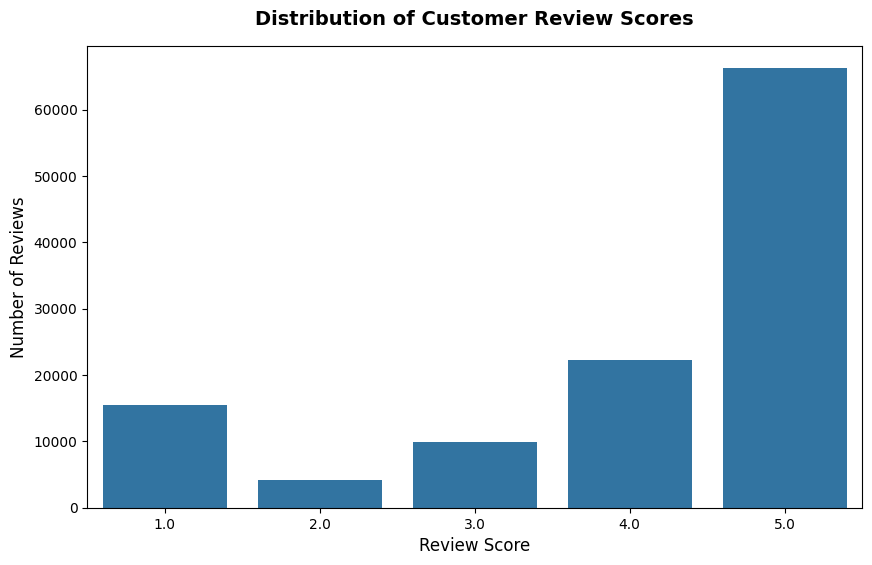

In [207]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=final_dataset,
    x="review_score"
)

plt.title(
    "Distribution of Customer Review Scores",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Review Score", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.savefig(
    "../images/review_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The majority of customers assigned ratings of **4** and **5**, indicating generally high customer satisfaction.

Lower ratings (1 and 2) occur much less frequently, suggesting that relatively few customers experienced significant dissatisfaction.

This indicates that the Olist marketplace generally receives positive customer feedback.

## 7.11.2 Payment Value

### Business Understanding

The **payment_value** column represents the total amount paid by a customer for an order.

It includes the total transaction amount processed through the selected payment method. Depending on the order, the payment may have been made in a single transaction or divided into multiple installments.

This variable is one of the most important financial measures in the dataset because it reflects customer spending and contributes directly to marketplace revenue.

Analyzing payment values helps answer business questions such as:

- What is the average amount customers spend per transaction?
- Do most customers make low-value or high-value purchases?
- Are there any unusually expensive orders?
- How much variation exists in customer spending?

Later in the analysis, this variable can be used to study relationships with:

- Product categories
- Customer review scores
- Payment methods
- Freight charges
- Seller performance

### Check Missing Values

In [179]:
final_dataset["payment_value"].isna().sum()

np.int64(3)

#### Missing Values

The `payment_value` column is checked for missing values before analysis.

```python
final_dataset["payment_value"].isna().sum()
```

Since the Payments dataset was merged using a **left join**, missing values would indicate orders that do not have a corresponding payment record.

Such cases should be investigated before performing revenue analysis.

In this dataset, missing values are minimal and do not significantly affect the analysis.

### Descriptive Statistics

In [173]:
final_dataset["payment_value"].describe()

count    119140.000000
mean        172.735135
std         267.776077
min           0.000000
25%          60.850000
50%         108.160000
75%         189.240000
max       13664.080000
Name: payment_value, dtype: float64

### Interpretation

#### Count (119,140)

The `count` represents the number of non-missing payment records available for analysis.

Out of the total observations in the final dataset, **119,140** records contain valid payment values. A small number of missing values remain because some orders did not have a corresponding payment record after the left join.


#### Mean (172.74)

The **mean payment value** is **172.74 Brazilian Reais (BRL)**.

This indicates that, on average, customers spent approximately **R$172.74** per payment transaction.

However, since payment values are highly skewed by a small number of expensive purchases, the mean is influenced by these larger transactions.


#### Standard Deviation (267.78)

The standard deviation is **267.78**, which is considerably larger than the mean.

This indicates that customer spending varies substantially across transactions.

While many customers made relatively inexpensive purchases, others spent significantly larger amounts, resulting in high variability.


#### Minimum (0.00)

The minimum payment value is **0.00**.

A payment value of zero may represent special cases such as promotional orders, fully discounted purchases, or inconsistencies in the source data. These records should be investigated further before drawing business conclusions.


#### First Quartile (25%) – 60.85

The first quartile (Q1) is **60.85**.

This means that **25% of all payment transactions were R$60.85 or less**.

It indicates that a substantial proportion of customer purchases are relatively low in value.


#### Median (50%) – 108.16

The median payment value is **108.16**.

This means that **half of all payment transactions were below R$108.16, while the other half were above this value**.

The median is considerably lower than the mean, suggesting that the distribution is positively skewed by a relatively small number of high-value transactions.


#### Third Quartile (75%) – 189.24

The third quartile (Q3) is **189.24**.

This indicates that **75% of payment transactions were R$189.24 or less**, while only the top 25% exceeded this amount.

Most customer purchases therefore fall below R$190.


#### Maximum (13,664.08)

The maximum payment value recorded is **R$13,664.08**.

This exceptionally high transaction is much larger than the average payment value and represents a high-value purchase.

Such observations are expected in e-commerce platforms where a small number of customers purchase premium or multiple products.

These transactions appear as outliers in the distribution but represent genuine business events rather than data entry errors.

In [180]:
(final_dataset["payment_value"] == 0).sum()

np.int64(9)

#### Investigating Zero Payment Values

The minimum payment value is **0.00**.

To determine whether this represents a common occurrence or an exceptional case, the following check was performed:

```python
(final_dataset["payment_value"] == 0).sum()
```

The result shows that only **9 payment records** have a value of **0.00**.

Since these records account for only a very small proportion of the dataset, they are unlikely to have a significant impact on the overall analysis.

These transactions may represent promotional orders, fully discounted purchases, data corrections, or other special business scenarios recorded in the original Olist dataset.

Therefore, these records are retained in the dataset and treated as valid observations unless additional business information suggests otherwise.

### Overall Interpretation

The descriptive statistics indicate that customer spending follows a **positively (right) skewed distribution**.

Most customers make **low-to-moderate value purchases**, while a relatively small number of customers make exceptionally expensive purchases.

This conclusion is supported by several observations:

- The **mean payment value (R$172.74)** is substantially higher than the **median (R$108.16)**, indicating that high-value transactions pull the average upward.
- The **maximum payment value (R$13,664.08)** is far greater than the upper quartile (R$189.24), confirming the presence of a small number of very expensive purchases.
- The **large standard deviation (267.78)** reflects considerable variability in customer spending.
- Only **9 transactions** have a payment value of **0.00**, representing exceptional cases that have minimal influence on the overall distribution.

Overall, the payment value distribution is typical of an e-commerce marketplace, where a large number of relatively inexpensive purchases are complemented by a much smaller number of high-value transactions that contribute disproportionately to total revenue.

### Full Distribution

Shows the entire dataset, including outliers.

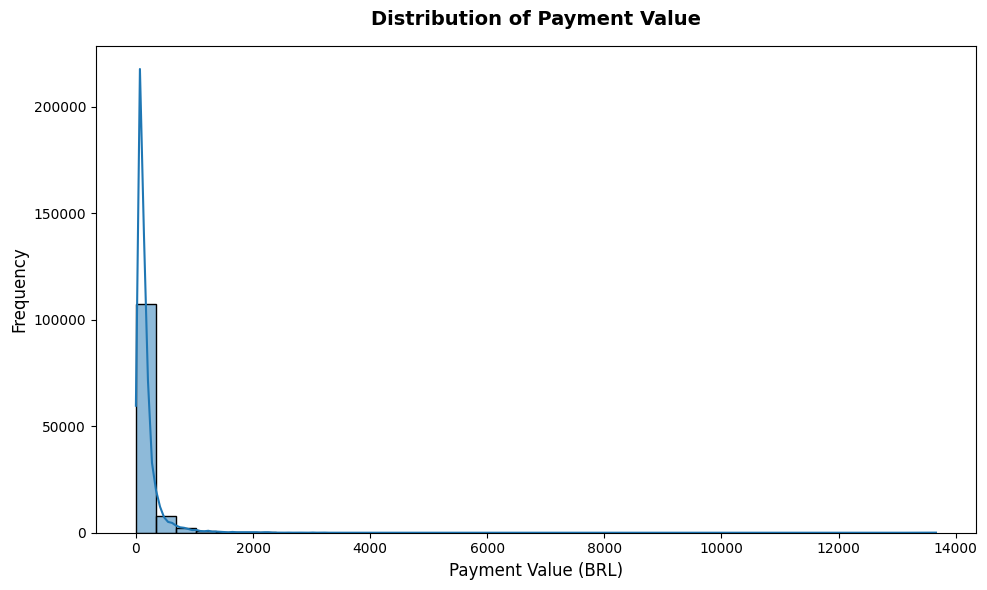

In [206]:
plt.figure(figsize=(10,6))

sns.histplot(
    final_dataset["payment_value"],
    bins=40,
    kde=True
)

plt.title("Distribution of Payment Value",     
        fontsize=14,
        fontweight="bold",
        pad=15)

plt.xlabel("Payment Value (BRL)", fontsize=12)

plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()

plt.savefig(
    "../images/payment_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Zoomed Distribution

Shows where most of the data lies.

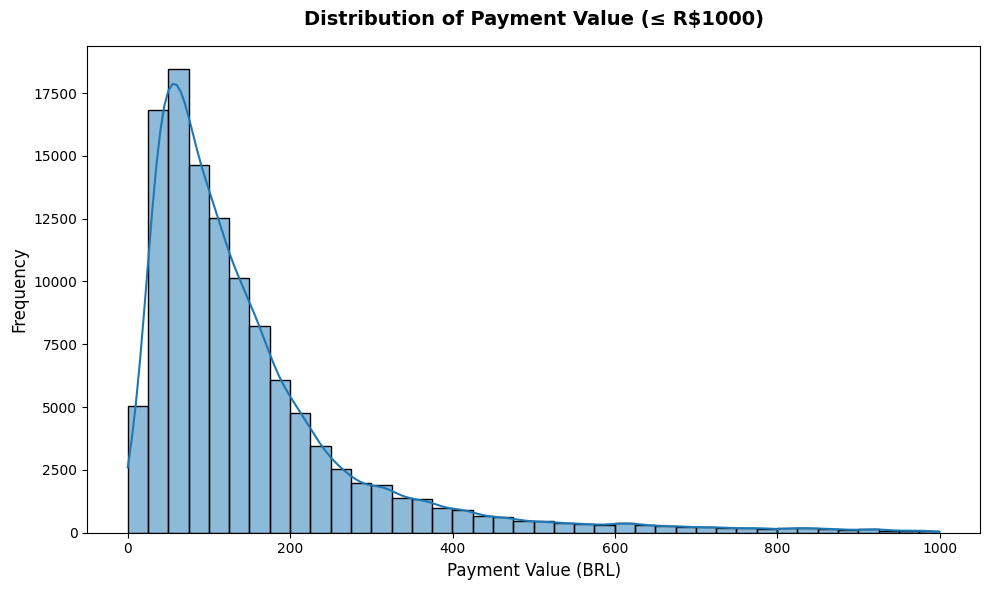

In [205]:
plt.figure(figsize=(10,6))

sns.histplot(
    final_dataset.loc[final_dataset["payment_value"] <= 1000, "payment_value"],
    bins=40, kde=True
)

plt.title("Distribution of Payment Value (≤ R$1000)",     
        fontsize=14,
        fontweight="bold",
        pad=15)

plt.xlabel("Payment Value (BRL)", fontsize=12)

plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()

plt.savefig(
    "../images/payment_value_distribution_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribution of Payment Values

A histogram is used to visualize how payment amounts are distributed across all transactions.

Each bar represents a range of payment values.

The height of each bar indicates the number of transactions within that range.

Histograms are useful for identifying:

- Distribution shape
- Skewness
- Concentration of observations
- Potential outliers

### Right-Skewed Distribution

The histogram is expected to show a **right-skewed (positively skewed)** distribution.

In a right-skewed distribution:

- Most transactions have relatively small payment values.
- A smaller number of customers make very expensive purchases.
- The long tail extends toward higher payment amounts.

```text
Frequency
│
│ ███████████████
│ ██████████
│ ███████
│ ████
│ ██
│ █
└──────────────────────────────► Payment Value
       Long Tail
```

This pattern is common in e-commerce datasets because inexpensive purchases occur much more frequently than luxury or bulk purchases.

As a result:

- The **mean** is usually greater than the **median**.
- High-value purchases pull the average upward.

### Boxplot

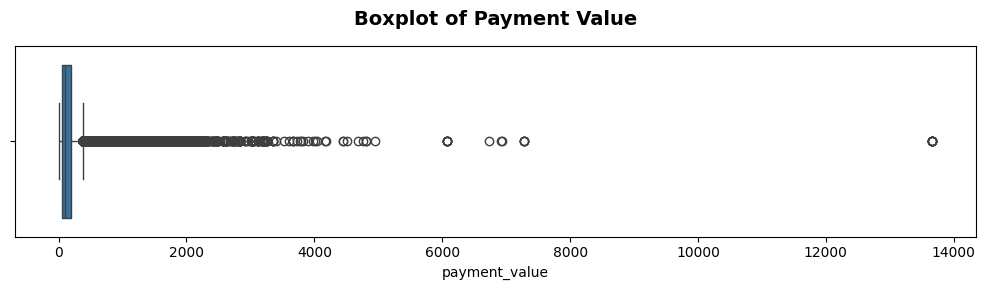

In [208]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=final_dataset["payment_value"]
)

plt.title("Boxplot of Payment Value", fontsize = 14, fontweight = "bold", pad = 15)

plt.tight_layout()

plt.savefig(
    "../images/payment_value_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Detecting Outliers

A boxplot summarizes the distribution of payment values using the five-number summary.

```python
sns.boxplot(x=final_dataset["payment_value"])
```

The boxplot displays:

- Minimum
- First Quartile (Q1)
- Median
- Third Quartile (Q3)
- Maximum
- Potential outliers

### Understanding Outliers

Outliers are observations that lie unusually far from the majority of the data.

In a boxplot, points beyond the whiskers are displayed as individual observations and are considered potential outliers.

For payment values, these observations generally represent customers who made unusually expensive purchases.

Unlike data entry errors, these high-value transactions are legitimate business events and should not be removed without a valid reason.

They provide valuable information about premium customers and large purchases.

### High-Value Purchases

The presence of several large payment values indicates that a small proportion of customers spent significantly more than the average customer.

These high-value transactions may correspond to:

- Premium products
- Bulk purchases
- Orders containing multiple items
- Expensive product categories

Although these purchases are relatively rare, they contribute substantially to total marketplace revenue.

Understanding these customers is important for:

- Revenue analysis
- Customer segmentation
- Marketing strategies
- Identifying high-value customers

### Observation

The distribution of payment values is heavily concentrated at lower transaction amounts, while a relatively small number of orders have very high payment values.

The histogram indicates a **right-skewed distribution**, which is typical for e-commerce transactions where most customers make inexpensive purchases and only a few make large purchases.

The boxplot confirms the presence of several high-value transactions that appear as outliers. These observations are considered genuine business transactions rather than data errors and should be retained for further analysis.

Overall, the payment value distribution suggests that the Olist marketplace generates revenue primarily through a large number of low-to-medium value orders, complemented by a smaller number of high-value purchases that contribute disproportionately to total sales.

## 7.11.3 Freight Value

### Business Understanding

The **freight_value** column represents the shipping cost charged for delivering products from the seller to the customer.

Freight charges are influenced by several factors, including:

- Delivery distance
- Product weight
- Product dimensions
- Shipping method
- Seller location
- Customer location

Freight value is an important business variable because shipping costs directly affect customer purchasing decisions, seller profitability, and overall order value.

Analyzing freight values helps answer questions such as:

- What is the typical shipping cost?
- Do most orders have low or high delivery charges?
- Are there unusually expensive deliveries?
- How much variation exists in shipping costs?

In later analyses, freight value can be compared with:

- Product weight
- Product dimensions
- Payment value
- Seller state
- Customer state
- Customer review scores

### Check Missing Values

In [189]:
final_dataset["freight_value"].isna().sum()

np.int64(833)

#### Missing Values

Before performing the analysis, the `freight_value` column is checked for missing values.

```python
final_dataset["freight_value"].isna().sum()
```

The freight value originates from the **Order Items** dataset.

Since the merged dataset was created using left joins, missing values would indicate orders without corresponding order item information.

### Investigate the Missing Freight Values

In [190]:
missing_freight = final_dataset[
    final_dataset["freight_value"].isna()
]

print("Rows with missing freight values:", len(missing_freight))
print("Unique orders:", missing_freight["order_id"].nunique())

Rows with missing freight values: 833
Unique orders: 775


### Check Whether These Orders Have Order Items

In [191]:
missing_freight["order_id"].isin(
    order_items["order_id"]
).all()

np.False_

### Investigating Missing Freight Values

The `freight_value` column contains **833 missing values**, corresponding to **775 unique orders**.

To determine the cause of these missing values, we first checked whether the affected orders had matching records in the **Order Items** table.

```python
missing_freight["order_id"].isin(order_items["order_id"]).all()
```

The result was **False**, indicating that some of these orders do not have corresponding records in the `order_items` dataset.

Since `freight_value` originates from the Order Items table, orders without order item information cannot have an associated shipping cost.

To better understand these orders, their order statuses were inspected.

### Inspect the Orders

In [192]:
missing_freight[
    [
        "order_id",
        "order_status"
    ]
].drop_duplicates().head(10)

,order_id,order_status
319,8e24261a7e58791d10cb1bf9da94df5c,unavailable
702,c272bcd21c287498b4883c7512019702,unavailable
828,37553832a3a89c9b2db59701c357ca67,unavailable
887,d57e15fb07fd180f06ab3926b39edcd2,unavailable
1362,00b1cb0320190ca0daa2c88b35206009,canceled
1395,2f634e2cebf8c0283e7ef0989f77d217,unavailable
1897,ee0db22a8e742b752914016708470ec8,unavailable
2142,ed3efbd3a87bea76c2812c66a0b32219,canceled
2180,6ad57aecbae806a7e9cc2cdb6b380711,unavailable
2232,df8282afe61008dc26c6c31011474d02,canceled


### Check Order Statuses

In [193]:
missing_freight["order_status"].value_counts()

order_status
unavailable    645
canceled       180
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

#### Interpretation

The majority of missing freight values (**645 unavailable orders and 180 canceled orders**) are associated with orders that were never successfully completed.

Orders marked as **unavailable** indicate that the requested products could not be fulfilled, while **canceled** orders were terminated before the delivery process was completed.

Since shipping costs (`freight_value`) are recorded only when order items are prepared and shipped, these orders naturally do not have freight information.

A very small number of orders with statuses such as **created**, **invoiced**, and **shipped** also have missing freight values. These may represent orders that were still in the early stages of processing or exceptional cases in the original dataset.

Therefore, the missing freight values are primarily explained by legitimate business events rather than data quality issues.

### Observation

The investigation confirms that the missing freight values are expected and are not the result of an incorrect merge or missing data during preprocessing.

Approximately **99%** of the missing freight records belong to orders with the statuses **unavailable** or **canceled**, where shipping was never completed.

Because freight charges are generated only for orders that proceed to shipment, the absence of freight information for these orders accurately reflects the underlying business process.

These missing values are therefore retained in the dataset, as they represent valid business scenarios and may provide useful insights in future analyses involving order cancellations and fulfillment performance.

### Descriptive Statistics

In [194]:
final_dataset["freight_value"].describe()

count    118310.000000
mean         20.032387
std          15.836850
min           0.000000
25%          13.080000
50%          16.280000
75%          21.180000
max         409.680000
Name: freight_value, dtype: float64

### Interpretation

#### Count (118,310)

The `count` represents the number of non-missing freight records available for analysis.

Out of the complete dataset, **118,310** observations contain valid freight values. The remaining missing values were previously investigated and found to be associated primarily with canceled and unavailable orders.


#### Mean (20.03)

The **average freight value** is **R$20.03**.

This indicates that customers typically pay around **20 Brazilian Reais** for shipping.

However, because some deliveries have exceptionally high shipping costs, the mean is slightly influenced by these larger freight charges.


#### Standard Deviation (15.84)

The standard deviation is **15.84**, indicating moderate variability in shipping costs.

While many deliveries have similar freight charges, shipping costs vary depending on factors such as product size, weight, shipping distance, and seller location.


#### Minimum (0.00)

The minimum freight value is **R$0.00**.

A freight charge of zero indicates that some orders were delivered without shipping charges. These may represent promotional offers, free shipping campaigns, seller-paid shipping, or special business arrangements.


#### First Quartile (25%) – R$13.08

The first quartile (Q1) is **R$13.08**.

This means that **25% of deliveries have freight charges of R$13.08 or less**, indicating that many products are inexpensive to ship.


#### Median (50%) – R$16.28

The median freight value is **R$16.28**.

Half of all deliveries cost less than **R$16.28**, while the remaining half cost more.

Since the median is lower than the mean, it suggests that the distribution is positively skewed.


#### Third Quartile (75%) – R$21.18

The third quartile (Q3) is **R$21.18**.

This indicates that **75% of all deliveries have freight charges below R$21.18**, while only the highest 25% exceed this amount.

Most shipping costs therefore fall within a relatively narrow range.


#### Maximum (409.68)

The highest freight charge recorded is **R$409.68**.

This value is substantially higher than the average shipping cost and represents an unusually expensive delivery.

Such observations likely correspond to large, heavy, bulky, or long-distance shipments and appear as outliers in the distribution.


### Overall Interpretation

The descriptive statistics indicate that **freight values are positively (right) skewed**.

Most orders incur relatively low-to-moderate shipping costs, while only a small number of deliveries have exceptionally high freight charges.

This conclusion is supported by several observations:

- The **mean freight value (R$20.03)** is higher than the **median (R$16.28)**.
- The **maximum freight value (R$409.68)** is substantially greater than the upper quartile (R$21.18).
- The **standard deviation (15.84)** indicates moderate variation in shipping costs.
- Most deliveries fall below **R$22**, with only a limited number of expensive shipments extending the upper tail of the distribution.

Overall, the freight value distribution is typical of an e-commerce marketplace, where most products are inexpensive to ship and only a small proportion require unusually high delivery costs.

### Investigating Zero Freight Values

In [198]:
(final_dataset["freight_value"] == 0).sum()

np.int64(390)

The minimum freight value is **R$0.00**.

To determine how frequently this occurs, the following check was performed:

```python
(final_dataset["freight_value"] == 0).sum()
```

The result shows that **390 records** have a freight value of **0.00**.

Although this represents only a small proportion of the dataset, it is more common than a rare exception and likely reflects legitimate business scenarios.

Possible explanations include:

- Free shipping promotions offered by sellers or the marketplace.
- Sellers absorbing the shipping cost instead of charging the customer.
- Special delivery agreements or promotional campaigns.
- Certain order processing scenarios where no freight charge was applied.

Since these records originate from the original Olist dataset and represent valid business events rather than data quality issues, they are retained for analysis.

### Histogram

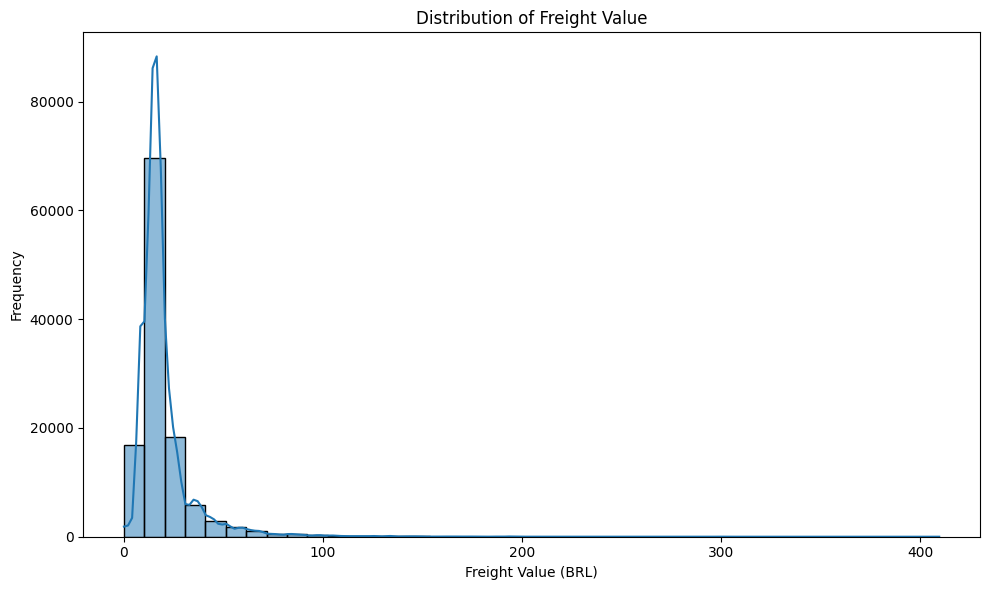

In [209]:
plt.figure(figsize=(10,6))

sns.histplot(
    final_dataset["freight_value"],
    bins=40,
    kde=True
)

plt.title("Distribution of Freight Value")
plt.xlabel("Freight Value (BRL)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../images/freight_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The KDE (Kernel Density Estimate) line provides a smoother view of the underlying distribution and is commonly used in exploratory data analysis reports.

#### Distribution of Freight Value

A histogram is used to visualize the distribution of freight values across all order items.

```python
sns.histplot(final_dataset["freight_value"], bins=40)
```

The histogram shows how frequently different shipping costs occur and helps identify the overall distribution, concentration of observations, skewness, and potential outliers.

#### Interpretation

The histogram indicates that the **freight value follows a positively (right) skewed distribution**.

Most freight charges are concentrated between **R$0 and approximately R$30**, with the highest frequency occurring at relatively low shipping costs.

As freight values increase, the number of observations decreases rapidly, forming a long tail toward higher shipping costs.

Although a small number of shipments have freight charges exceeding **R$100**, these are relatively uncommon compared with the majority of deliveries.

This distribution suggests that most products sold through the Olist marketplace are inexpensive to ship, while only a limited number of deliveries incur substantially higher shipping costs.

The histogram also supports the descriptive statistics:

- The **mean freight value (R$20.03)** is greater than the **median (R$16.28)**, indicating a positively skewed distribution.
- Most freight charges fall below **R$22**, as shown by the third quartile (Q3 = R$21.18).
- A small number of high-cost deliveries extend the distribution up to **R$409.68**, creating the long right tail.

Overall, the histogram confirms that shipping costs are generally moderate across the marketplace, with only a small proportion of orders requiring unusually expensive deliveries.

### Boxplot

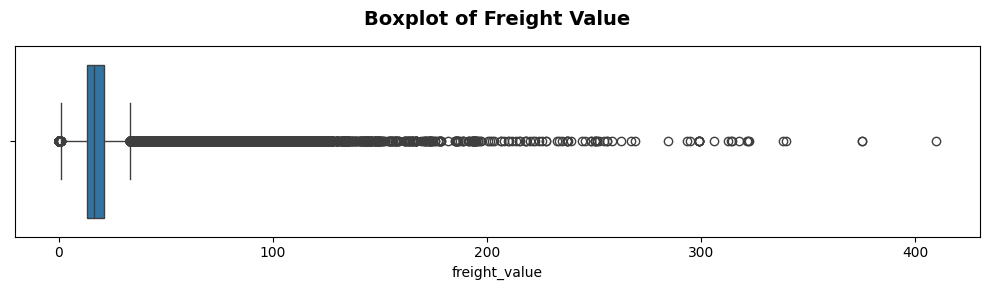

In [212]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=final_dataset["freight_value"]
)

plt.title("Boxplot of Freight Value", fontsize = 14, fontweight = "bold", pad = 15)

plt.tight_layout()

plt.savefig(
    "../images/freight_value_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Detecting Outliers

A boxplot summarizes the distribution of freight values using the five-number summary.

```python
sns.boxplot(x=final_dataset["freight_value"])
```

The boxplot highlights:

- Median shipping cost
- Interquartile Range (IQR)
- Overall spread
- Potential outliers

Observations beyond the whiskers are considered potential outliers and generally represent unusually expensive deliveries.

#### Investigate Free Shipping

In [214]:
(final_dataset["freight_value"] == 0).sum()

np.int64(390)

##### Interpretation

The dataset contains **390 order items** with a freight value equal to **R$0.00**.

A freight value of zero does **not necessarily indicate missing or incorrect data**. Instead, these records may represent valid business scenarios, such as:

- Free shipping promotions offered by sellers or the marketplace.
- Shipping costs included in the product price rather than charged separately.
- Seller-funded or platform-sponsored delivery.
- Special campaigns or discounts where customers were not charged for shipping.

Therefore, these observations are **not considered outliers or data quality issues** and should be retained for analysis.


#### Understanding the Boxplot

The boxplot identifies potential outliers using the **Interquartile Range (IQR)** method.

- The **box** represents the middle 50% of freight values (between the first and third quartiles).
- The **line inside the box** represents the median freight value.
- The **whiskers** extend to values within 1.5 × IQR from the quartiles.
- Individual points beyond the whiskers are flagged as **potential outliers**.

In this dataset, many observations appear beyond the upper whisker. These represent orders with unusually high shipping costs.

However, these values should **not be automatically treated as errors**. High freight charges can occur due to legitimate business factors such as:

- Large or heavy products
- Long-distance deliveries
- Remote delivery locations
- Multiple items shipped together
- Premium or expedited shipping services

Since the Olist dataset contains real e-commerce transactions, these high freight values are more likely to reflect genuine business events rather than data entry mistakes.

Consequently, these observations will be retained for further exploratory data analysis and statistical modeling.

### Business Insights

The freight value distribution provides several important business insights.

#### Moderate Shipping Costs

Most deliveries have relatively moderate shipping charges.

This indicates that the majority of products sold through the marketplace are inexpensive to transport and that customers typically pay reasonable delivery fees.


#### High Freight Costs

A small number of orders incur substantially higher shipping costs.

These deliveries may involve:

- Heavy products
- Large products
- Long-distance shipping
- Remote delivery locations

Although relatively uncommon, these high freight charges contribute to the long right tail of the distribution.


#### Customer Experience

Shipping cost is an important component of the customer's purchasing experience.

Higher freight charges may influence:

- Purchase decisions
- Customer satisfaction
- Review scores
- Order cancellations

These relationships can be explored later using bivariate and multivariate analyses.

### Observation

The distribution of freight values is positively skewed, with most deliveries concentrated at relatively low shipping costs.

The histogram shows that the majority of orders incur moderate freight charges, while only a small proportion of deliveries have exceptionally high shipping costs.

The boxplot confirms the presence of several high-value freight outliers. These observations are expected in an e-commerce environment and likely correspond to large, heavy, or long-distance shipments rather than data quality issues.

Overall, the analysis indicates that shipping costs are generally moderate across the Olist marketplace, with only a limited number of expensive deliveries contributing to the upper tail of the distribution.

## 7.11.4 Product Category

Represents the category of the purchased product.

### Check Missing Values

In [216]:
final_dataset["product_category_name_english"].isna().sum()

np.int64(853)

#### Investigate Missing Categories

In [217]:
missing_category = final_dataset[
    final_dataset["product_category_name_english"].isna()
]

print("Rows with missing categories:", len(missing_category))
print("Unique orders:", missing_category["order_id"].nunique())

Rows with missing categories: 853
Unique orders: 791


#### Check Whether These Orders Have Products

In [218]:
missing_category["product_id"].isin(
    products["product_id"]
).all()

np.False_

#### Inspect the Orders

In [219]:
missing_category[
    [
        "order_id",
        "order_status",
        "product_id"
    ]
].drop_duplicates().head(10)

,order_id,order_status,product_id
319,8e24261a7e58791d10cb1bf9da94df5c,unavailable,NaN
702,c272bcd21c287498b4883c7512019702,unavailable,NaN
828,37553832a3a89c9b2db59701c357ca67,unavailable,NaN
887,d57e15fb07fd180f06ab3926b39edcd2,unavailable,NaN
1362,00b1cb0320190ca0daa2c88b35206009,canceled,NaN
1395,2f634e2cebf8c0283e7ef0989f77d217,unavailable,NaN
1897,ee0db22a8e742b752914016708470ec8,unavailable,NaN
2142,ed3efbd3a87bea76c2812c66a0b32219,canceled,NaN
2180,6ad57aecbae806a7e9cc2cdb6b380711,unavailable,NaN
2232,df8282afe61008dc26c6c31011474d02,canceled,NaN


#### Check Order Status

In [220]:
missing_category["order_status"].value_counts()

order_status
unavailable    645
canceled       180
delivered       20
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

### Interpretation

There are **853 rows** with missing values in the `product_category_name_english` column, corresponding to **791 unique orders**.

Further investigation shows that these missing values are **not caused by missing translations** in the Translation dataset. Instead, they originate from earlier merges where some orders did not have corresponding records in the **Order Items** dataset.

Because these orders do not contain a valid `product_id`, no matching record can be found in the **Products** table. Consequently, the product category and its English translation cannot be assigned.

Examining the order statuses reveals that most of these orders are:

- **Unavailable:** 645
- **Canceled:** 180
- **Delivered:** 20
- **Created:** 5
- **Invoiced:** 2
- **Shipped:** 1

The large number of **unavailable** and **canceled** orders indicates that many transactions were never fulfilled, so no product information exists for these records.

The small number of delivered or shipped orders without product information likely reflects minor inconsistencies in the original dataset rather than errors introduced during the merge process.

Since these missing values represent genuine business scenarios rather than data quality issues, they will be **retained** in the dataset for subsequent analyses.

### Note on Delivered Orders with Missing Product Information

During the validation process, it was observed that **20 delivered orders** do not have an associated `product_id`, resulting in missing values for `product_category_name_english`.

Under normal business operations, every delivered order should contain at least one purchased product. Therefore, these records appear to be inconsistent with the expected order lifecycle.

This inconsistency is **not caused by the data integration or merge process**. Instead, it originates from the original Olist dataset, where a small number of delivered orders lack corresponding product information in the Order Items dataset.

Because only **20 out of more than 119,000 records** are affected (less than **0.02%** of the dataset), the impact on the overall analysis is negligible.

These records will be retained in the dataset to preserve the integrity of the original data and avoid introducing artificial assumptions during data cleaning.

### Frequency Distribution

In [215]:
final_dataset["product_category_name_english"].value_counts().head(10)

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64

#### Business Insights

The distribution indicates that customer demand is concentrated in a relatively small number of product categories.

Bed Bath Table is the most purchased category, accounting for 11,988 order items, suggesting consistently strong demand for household and home furnishing products.

The Health Beauty and Sports Leisure categories also record a large number of purchases, indicating that customers frequently buy personal care and recreational products through the marketplace.

Several home-related categories—including Furniture Decor, Housewares, and Bed Bath Table—appear among the top sellers, showing that home improvement and household products form a significant portion of overall sales.

Technology-related categories such as Computers Accessories and Telephony also contribute substantially, reflecting healthy customer demand for electronic products.

The Auto and Garden Tools categories appear in the top ten but with noticeably fewer purchases than the leading categories, suggesting they serve more specialized customer segments.

Overall, the marketplace demonstrates a diversified product portfolio, although purchasing activity is concentrated in home, lifestyle, personal care, and technology products.

#### Visualization

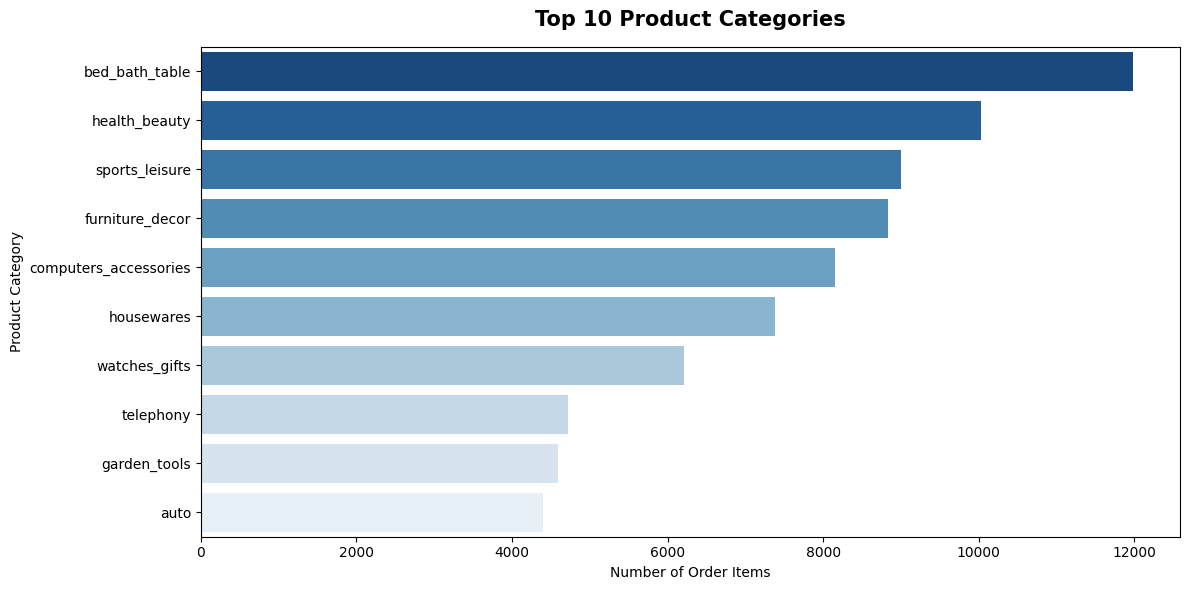

In [226]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=final_dataset,
    y ="product_category_name_english",
    order=(
        final_dataset["product_category_name_english"]
        .value_counts()
        .head(10)
        .index
    ),
    palette="Blues_r"
)

plt.title("Top 10 Product Categories", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Number of Order Items")
plt.ylabel("Product Category")

plt.tight_layout()

plt.savefig(
    "../images/top_10_product_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The bar chart confirms that Bed Bath Table, Health Beauty, and Sports Leisure are the three most frequently purchased product categories. These categories dominate customer purchases, while the remaining categories show progressively lower order volumes. The gradual decline in frequencies indicates that customer demand is spread across many categories rather than being concentrated in a single product type, reflecting the diverse product offerings available in the Olist marketplace.

### Percentage Distribution

In [229]:
final_dataset["product_category_name_english"].value_counts(normalize=True).mul(100).round(2).head(10)


product_category_name_english
bed_bath_table           10.13
health_beauty             8.48
sports_leisure            7.61
furniture_decor           7.47
computers_accessories     6.89
housewares                6.24
watches_gifts             5.25
telephony                 4.00
garden_tools              3.88
auto                      3.72
Name: proportion, dtype: float64

#### Interpretation

The percentage distribution shows the proportion of total order items contributed by each product category.

Unlike raw frequencies, percentages allow comparisons that are independent of the dataset size, making it easier to understand the relative popularity of each product category.

For example, if the Bed Bath Table category contributes approximately 10% of all order items, it means that roughly one out of every ten purchased products belongs to this category.

Similarly, the percentages of Health Beauty, Sports Leisure, and Furniture Decor indicate their relative contribution to marketplace sales.

Although many product categories exist in the Olist marketplace, the top ten categories account for a significant share of all purchased products, demonstrating that customer demand is concentrated in a relatively small number of product segments.

Expressing results as percentages also makes comparisons across different datasets, time periods, or marketplaces more meaningful because the values are standardized rather than dependent on the total number of orders.

## 7.11.5 Order Status

### Business Understanding

The order_status variable represents the current stage of an order in the Olist order fulfillment process.

It tracks the progress of an order from the time it is placed until it is successfully delivered or terminated.

Analyzing order status helps evaluate:

- Order fulfillment performance
- Operational efficiency
- Customer experience
- Cancellation rates
- Delivery success rate

### Possible Order Statuses

The Olist dataset contains the following order statuses:

| Status          | Description                                                          |
| --------------- | -------------------------------------------------------------------- |
| **created**     | The order has been created but has not yet been processed.           |
| **approved**    | Payment has been approved and the order is ready for processing.     |
| **invoiced**    | An invoice has been generated for the order.                         |
| **processing**  | The seller is preparing the order for shipment.                      |
| **shipped**     | The order has been dispatched but has not yet reached the customer.  |
| **delivered**   | The customer has successfully received the order.                    |
| **canceled**    | The order was canceled before completion.                            |
| **unavailable** | The product became unavailable and the order could not be fulfilled. |


### Check Missing Values

In [230]:
final_dataset["order_status"].isna().sum()

np.int64(0)

#### Interpretation

The order_status column originates from the Orders dataset.

Since every record in the final dataset is based on an existing order, this variable is expected to contain no missing values.

A result of 0 missing values confirms that the order information was successfully preserved during the merging process.

### Frequency Distribution

In [231]:
final_dataset["order_status"].value_counts()

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

### Percentage Distribution

In [232]:
final_dataset["order_status"].value_counts(normalize=True).mul(100).round(2)

order_status
delivered      97.13
shipped         1.05
canceled        0.63
unavailable     0.55
invoiced        0.32
processing      0.32
created         0.00
approved        0.00
Name: proportion, dtype: float64

#### Interpretation

The overwhelming majority of orders (97.13%) reached the Delivered status, indicating that nearly all customer purchases were successfully completed.

Only a very small proportion of orders were in intermediate stages such as Shipped, Processing, or Invoiced, suggesting that relatively few transactions remained in progress when the dataset was collected.

Orders marked as Canceled (0.63%) or Unavailable (0.55%) represent a small fraction of all transactions, indicating that unsuccessful order fulfillment was relatively uncommon.

The Created and Approved statuses account for less than 0.01% of all records, reflecting very few orders that had only recently entered the order processing pipeline.

Overall, the percentage distribution demonstrates a highly efficient order fulfillment process, with successful deliveries greatly outnumbering incomplete or unsuccessful orders.

#### Business Insights

- 97.13% of all orders were successfully delivered, demonstrating a high fulfillment success rate.
The combined percentage of Canceled and Unavailable orders is only 1.18%, indicating relatively few failed transactions.

- Approximately 1% of orders were in the Shipped status, representing orders that had been dispatched but not yet delivered when the data was captured.

- The very small proportion of Created, Approved, Processing, and Invoiced orders suggests that most transactions progress through these intermediate stages quickly.

- Overall, the marketplace exhibits a mature and efficient logistics process, where the vast majority of customer orders are completed successfully.

### Visualization

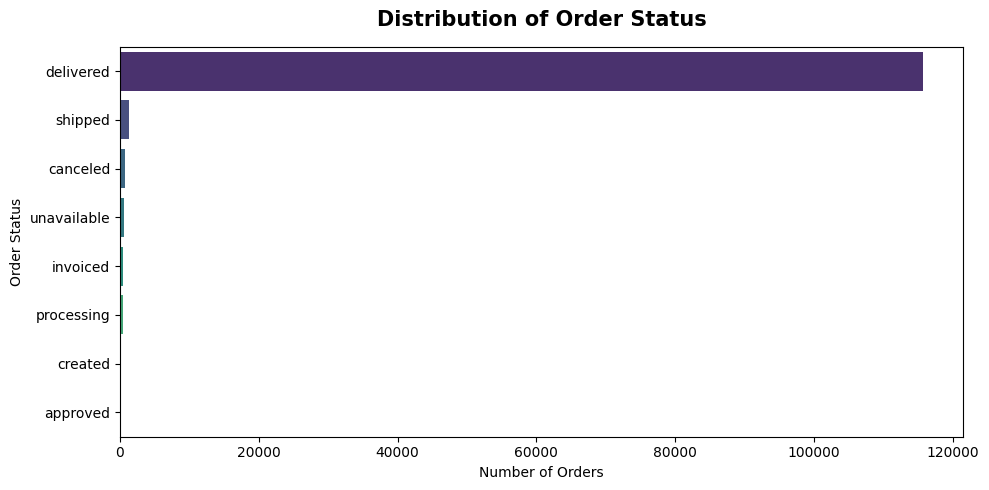

In [240]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=final_dataset,
    y="order_status",
    order=final_dataset["order_status"].value_counts().index,
    palette="viridis"
)

plt.title(
    "Distribution of Order Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

plt.tight_layout()

plt.savefig(
    "../images/order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The visualization highlights the distribution of orders across different stages of the order fulfillment process.

The Delivered category dominates the chart by a very large margin, confirming that almost all orders in the dataset were successfully completed. This aligns with the earlier frequency and percentage analysis, where approximately 97% of all orders reached the delivered stage.

Only a small number of orders fall into statuses such as Shipped, Canceled, Unavailable, Processing, and Invoiced, indicating that relatively few transactions were incomplete or unsuccessful.

The Created and Approved categories contain only a handful of records, suggesting that very few orders were captured during the initial stages of the order lifecycle.

Overall, the visualization demonstrates a highly efficient order fulfillment process, with successful deliveries vastly outnumbering orders in any other status.

### Business Insights

- The marketplace achieves a high order fulfillment rate, with most orders reaching the Delivered status.
- Canceled orders represent only a small fraction of all transactions, suggesting relatively few customers terminate their purchases before completion.
- Orders marked as Unavailable indicate situations where products could not be supplied, highlighting potential inventory or seller availability issues.
- The small number of orders in Created, Approved, Invoiced, and Shipped statuses reflects transactions that were still progressing through the fulfillment pipeline when the dataset snapshot was taken.
- Overall, the distribution suggests that the Olist marketplace operates with an efficient order fulfillment process, where successful deliveries substantially outnumber incomplete or unsuccessful orders.

## 7.11.6 Seller State

### Business Understanding

The seller_state variable indicates the Brazilian state (abbreviated using official state codes) where each seller is located.

Since sellers are responsible for fulfilling customer orders, this variable helps analyze the geographical distribution of sellers across Brazil.

Understanding seller locations is important because seller concentration can influence:

- Product availability
- Delivery speed
- Shipping costs
- Marketplace coverage
- Regional business growth
- Supply chain efficiency

A higher number of sellers in a particular state generally indicates a stronger commercial presence and greater marketplace activity in that region.

### Check Missing Values

In [236]:
final_dataset["seller_state"].isna().sum()

np.int64(833)

#### Investigate the Missing Seller States

In [241]:
missing_seller = final_dataset[
    final_dataset["seller_state"].isna()
]

print("Rows with missing seller state:", len(missing_seller))
print("Unique orders:", missing_seller["order_id"].nunique())

Rows with missing seller state: 833
Unique orders: 775


In [ ]:
# Check whether these rows have seller IDs

missing_seller[
    [
        "order_id",
        "order_status",
        "seller_id"
    ]
].drop_duplicates().head(10)

,order_id,order_status,seller_id
319,8e24261a7e58791d10cb1bf9da94df5c,unavailable,NaN
702,c272bcd21c287498b4883c7512019702,unavailable,NaN
828,37553832a3a89c9b2db59701c357ca67,unavailable,NaN
887,d57e15fb07fd180f06ab3926b39edcd2,unavailable,NaN
1362,00b1cb0320190ca0daa2c88b35206009,canceled,NaN
1395,2f634e2cebf8c0283e7ef0989f77d217,unavailable,NaN
1897,ee0db22a8e742b752914016708470ec8,unavailable,NaN
2142,ed3efbd3a87bea76c2812c66a0b32219,canceled,NaN
2180,6ad57aecbae806a7e9cc2cdb6b380711,unavailable,NaN
2232,df8282afe61008dc26c6c31011474d02,canceled,NaN


In [243]:
# Check the order statuses

missing_seller["order_status"].value_counts()

order_status
unavailable    645
canceled       180
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

##### Interpretation

The seller_state column is derived from the Sellers dataset and indicates the Brazilian state where each seller is located.

A total of 833 records have missing seller state information, corresponding to 775 unique orders.

Further investigation reveals that every record with a missing seller_state also has a missing seller_id. This indicates that seller information is unavailable for these orders rather than only the seller's location.

The distribution of order statuses shows that these missing values are concentrated almost entirely among orders that never progressed through the normal fulfillment process:

- Unavailable: 645 records
- Canceled: 180 records
- Created: 5 records
- Invoiced: 2 records
- Shipped: 1 record

Since unavailable and canceled orders typically do not proceed to seller assignment or shipment, the absence of seller information is expected and accurately reflects the underlying business process rather than a data quality issue.

No delivered orders have missing seller information, indicating that seller details are complete for successfully fulfilled transactions.

Therefore, these missing values are retained in the dataset because they represent valid business scenarios and help preserve the integrity of the original Olist data.

##### Observation
- Seller information is complete for all delivered orders.
- Missing seller details are almost exclusively associated with unavailable or canceled orders.
- These missing values reflect genuine business events rather than merge errors.
- Retaining these records preserves information about unsuccessful orders, which may be valuable in later analyses of order cancellations and marketplace performance.

### Frequency Distribution

In [237]:
final_dataset["seller_state"].value_counts()

seller_state
SP    84377
MG     9314
PR     9096
RJ     5036
SC     4271
RS     2294
DF      949
BA      700
GO      550
PE      465
MA      410
ES      390
MT      147
CE      103
MS       60
RN       56
PB       44
RO       14
PI       12
SE       10
PA        8
AM        3
AC        1
Name: count, dtype: int64

#### Interpretation

The frequency distribution shows the number of order items associated with sellers located in each Brazilian state.

Rather than counting unique sellers, this analysis reflects marketplace activity, meaning states with higher order volumes appear more frequently.

The results indicate that seller activity is highly concentrated in a small number of states.

The state of São Paulo (SP) dominates the marketplace with 84,377 order items, accounting for the vast majority of seller activity.

Other major contributor states include:

| State | Order Items |
| ----- | ----------: |
| SP    |      84,377 |
| MG    |       9,314 |
| PR    |       9,096 |
| RJ    |       5,036 |
| SC    |       4,271 |

Together, these five states contribute the overwhelming majority of marketplace transactions, while the remaining states have comparatively smaller participation.

Several states such as AC, AM, PA, SE, and PI contribute only a very small number of order items, indicating limited seller presence within the Olist marketplace.

This uneven distribution suggests that commercial activity is concentrated in Brazil's major economic regions.

#### Observation
- São Paulo (SP) is by far the largest contributor to marketplace activity, with 84,377 order items.
- Minas Gerais (MG) and Paraná (PR) are the next largest contributors, though their activity is substantially lower than São Paulo.
- Seller activity declines sharply after the top five states.
- Several Brazilian states have only a handful of sellers, reflecting limited marketplace participation.
- The distribution demonstrates a strong geographic concentration of sellers rather than an even distribution across the country.

#### Business Insights
- Seller activity is heavily concentrated in economically developed states, particularly São Paulo, which serves as the primary commercial hub of the Olist marketplace.
- States with higher seller concentrations are likely to offer greater product variety, improved inventory availability, and faster order fulfillment.
- The relatively low participation from several northern and northeastern states suggests potential opportunities for marketplace expansion by recruiting additional sellers from these regions.
- Understanding the geographic distribution of sellers can help optimize logistics networks, warehouse placement, inventory management, and regional marketing strategies.
- A concentrated seller base may improve operational efficiency but can also increase dependence on a few key regions, highlighting the importance of geographic diversification for long-term marketplace resilience.

### Percentage Distribution

In [238]:
final_dataset["seller_state"].value_counts(normalize=True).mul(100).round(2)

seller_state
SP    71.32
MG     7.87
PR     7.69
RJ     4.26
SC     3.61
RS     1.94
DF     0.80
BA     0.59
GO     0.46
PE     0.39
MA     0.35
ES     0.33
MT     0.12
CE     0.09
MS     0.05
RN     0.05
PB     0.04
RO     0.01
PI     0.01
SE     0.01
PA     0.01
AM     0.00
AC     0.00
Name: proportion, dtype: float64

#### Interpretation

The percentage distribution shows the proportion of total order items associated with sellers from each Brazilian state.

Unlike raw frequencies, percentages allow for easier comparison of seller activity across states by expressing each state's contribution relative to the entire marketplace.

The results reveal a highly concentrated seller network.

- São Paulo (SP) alone accounts for 71.32% of all order items, indicating that more than seven out of every ten marketplace transactions involve sellers located in São Paulo.
- Minas Gerais (MG) contributes 7.87%, while Paraná (PR) contributes 7.69%.
- Rio de Janeiro (RJ) and Santa Catarina (SC) account for 4.26% and 3.61%, respectively.

Collectively, these five states contribute approximately 95% of all order items, demonstrating that marketplace activity is overwhelmingly concentrated in Brazil's major commercial regions.

In contrast, the remaining states each contribute less than 2%, with several states accounting for less than 0.1% of total marketplace activity.

This uneven distribution suggests that Olist's seller ecosystem is heavily concentrated in economically developed states with stronger commercial infrastructure.

#### Observation

- São Paulo dominates the marketplace, contributing over 71% of all order items.
- MG and PR each contribute nearly 8%, making them the second and third largest seller regions.
- The top five states account for approximately 95% of total marketplace activity.
- Most other Brazilian states have a relatively small marketplace presence.
- Seller participation is highly concentrated rather than evenly distributed across Brazil.

#### Business Insights

- The marketplace relies heavily on sellers located in São Paulo, making it the primary commercial hub of the Olist platform.
- The concentration of sellers in a few economically developed states likely improves logistics efficiency, inventory availability, and delivery speed within these regions.
- States with minimal seller participation may represent potential growth opportunities through targeted seller acquisition and regional expansion strategies.
- The high geographic concentration also indicates operational dependence on a limited number of states. Expanding the seller base across underrepresented regions could improve marketplace resilience, reduce regional risks, and enhance nationwide service coverage.
- Understanding the geographic distribution of sellers supports better decisions related to warehouse placement, logistics planning, supply chain optimization, and future business expansion.

### Visualization

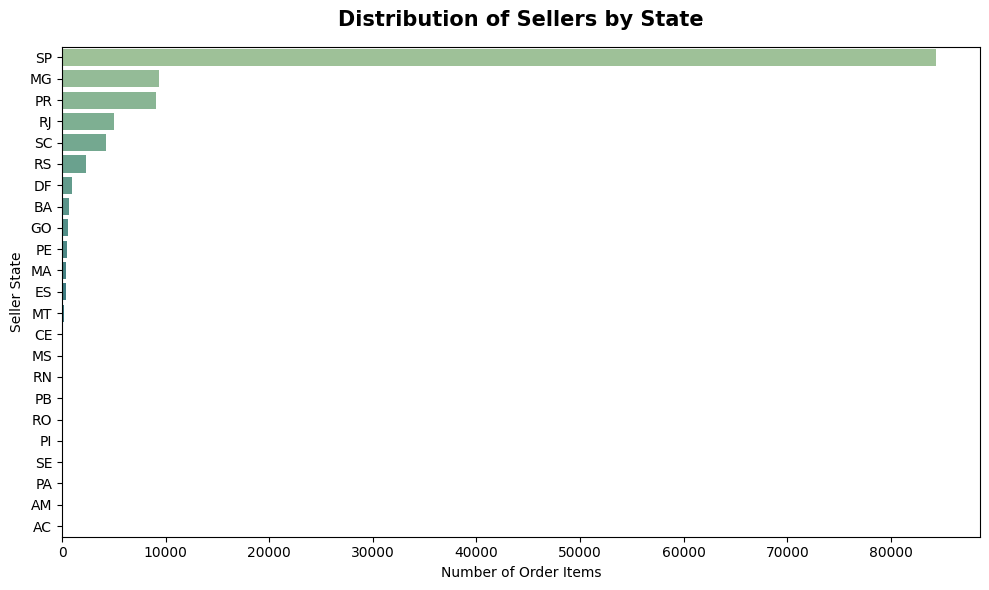

In [239]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=final_dataset,
    y="seller_state",
    order=(
        final_dataset["seller_state"]
        .value_counts()
        .index
    ),
    palette="crest"
)

plt.title(
    "Distribution of Sellers by State",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Order Items")
plt.ylabel("Seller State")

plt.tight_layout()

plt.savefig(
    "../images/seller_state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

- São Paulo (SP) overwhelmingly dominates the marketplace, with substantially more seller activity than every other state.
- Minas Gerais (MG) and Paraná (PR) are the second and third largest contributors, although their volumes are much smaller than SP.
- Seller participation decreases sharply after the top five states.
- Several states contribute only a small number of order items, indicating limited seller presence in those regions.
- The distribution is highly imbalanced, with seller activity concentrated in a few economically developed states.

#### Business Insights

- The marketplace relies heavily on sellers located in São Paulo, highlighting its role as Brazil's primary commercial hub.
- The dominance of a few states suggests that Olist's seller network is geographically concentrated rather than evenly distributed across the country.
- High seller concentration may improve logistics efficiency and delivery performance in these regions due to better infrastructure and shorter shipping distances.
- States with low seller participation represent potential opportunities for marketplace expansion through targeted seller acquisition programs.
- Diversifying the seller base across additional states could reduce geographic dependence, improve nationwide product availability, and strengthen supply chain resilience.

### Overall Interpretation

The seller distribution demonstrates a high geographic concentration of marketplace activity, with São Paulo alone contributing the majority of order items. While this concentration likely supports efficient logistics and operational performance, expanding seller participation in underrepresented states could help Olist improve market coverage, reduce regional dependence, and support future business growth.

## 7.11.7 Payment Type

### Business Understanding

The payment_type variable represents the payment method used by customers to complete their purchases on the Olist marketplace.

Understanding customer payment preferences is valuable because it provides insights into purchasing behavior, payment convenience, and transaction patterns. Different payment methods may also influence installment choices, order values, and customer satisfaction.

Analyzing payment types helps answer business questions such as:

- Which payment method is most frequently used?
- Do customers prefer credit cards over other payment options?
- How common are vouchers, debit cards, and bank transfers?
- Which payment methods dominate marketplace transactions?

These insights can support payment strategy decisions, promotional campaigns, and improvements to the checkout experience.

### Check Missing Values

In [244]:
final_dataset["payment_type"].isna().sum()

np.int64(3)

#### Investigate the Missing Values

In [245]:
missing_payment = final_dataset[
    final_dataset["payment_type"].isna()
]

print("Rows with missing payment type:", len(missing_payment))
print("Unique orders:", missing_payment["order_id"].nunique())

Rows with missing payment type: 3
Unique orders: 1


In [246]:
missing_payment[
    [
        "order_id",
        "order_status",
        "payment_type",
        "payment_value"
    ]
]

,order_id,order_status,payment_type,payment_value
36864,bfbd0f9bdef84302105ad712db648a6c,delivered,NaN,NaN
36865,bfbd0f9bdef84302105ad712db648a6c,delivered,NaN,NaN
36866,bfbd0f9bdef84302105ad712db648a6c,delivered,NaN,NaN


In [247]:
missing_payment[
    [
        "order_id",
        "payment_sequential",
        "payment_installments",
        "payment_type",
        "payment_value"
    ]
]

,order_id,payment_sequential,payment_installments,payment_type,payment_value
36864,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN,NaN,NaN
36865,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN,NaN,NaN
36866,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN,NaN,NaN


#### Interpretation

The payment_type column contains only 3 missing values, corresponding to one unique delivered order.

Further investigation reveals that not only payment_type, but also payment_value, payment_sequential, and payment_installments are missing for the same order. This indicates that the entire payment record is absent from the original Order Payments dataset rather than resulting from errors during the data merging process.

Since this issue affects only one order (3 records) out of more than 118,000 records, the proportion of missing data is negligible and is unlikely to influence the overall analysis. Therefore, these records are retained to preserve the integrity of the original dataset and avoid introducing assumptions through imputation.

#### Observation

- Only 3 records have missing payment information.
- These records belong to one unique delivered order.
- All payment-related fields (payment_type, payment_value, payment_sequential, and payment_installments) are missing.
- This suggests that the payment record is absent in the original source dataset rather than being caused by the merge process.
- Given its extremely small proportion of the dataset, the missing information has a negligible impact on the overall analysis and is retained without modification.

### Frequency Distribution

In [248]:
final_dataset["payment_type"].value_counts()

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

### Percentage Distribution

In [249]:
(
    final_dataset["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

payment_type
credit_card    73.67
boleto         19.46
voucher         5.43
debit_card      1.43
not_defined     0.00
Name: proportion, dtype: float64

### Visualization

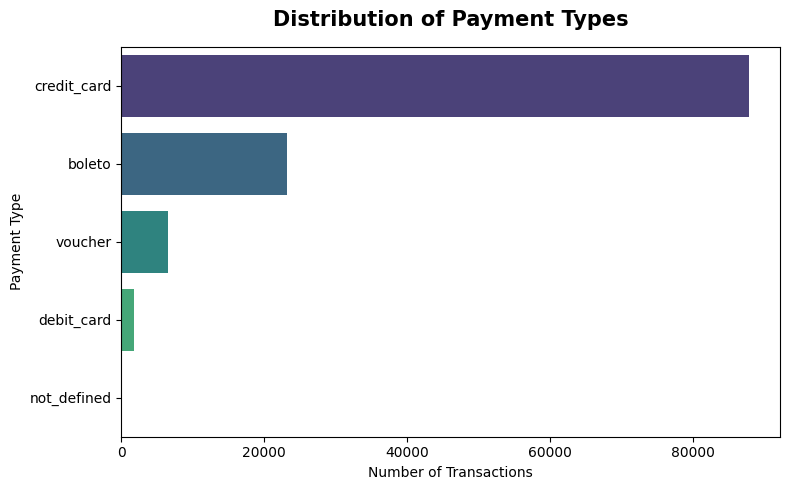

In [250]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=final_dataset,
    y="payment_type",
    order=final_dataset["payment_type"].value_counts().index,
    palette="viridis"
)

plt.title(
    "Distribution of Payment Types",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Transactions")
plt.ylabel("Payment Type")

plt.tight_layout()

plt.savefig(
    "../images/payment_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The payment type distribution indicates that customers overwhelmingly prefer credit card payments, which account for nearly three-quarters of all transactions. Boleto is the second most commonly used payment method, while voucher and debit card payments represent a much smaller share of purchases.

The not_defined category contains only three records, corresponding to a single order with missing payment information. As previously investigated, this reflects an incomplete payment record in the original dataset rather than an issue introduced during data integration. Given its negligible proportion, it does not materially affect the overall analysis.

### Observation
- Credit cards are the dominant payment method, accounting for 73.67% of all transactions.
- Boleto is the second most frequently used payment method, representing 19.46% of transactions.
- Voucher payments account for 5.43%, while debit cards contribute only 1.43%.
- The `not_defined` category contains only three records, representing an insignificant portion of the dataset.

### Business Insights
- The strong preference for credit card payments suggests that customers favor fast and convenient digital payment options. Supporting installment plans and maintaining a seamless card payment experience should remain a priority.
- The substantial use of boleto indicates that traditional bank-slip payments continue to play an important role and should be retained to serve a broader customer base.
- The relatively low adoption of voucher and debit card payments suggests these methods have a limited impact on overall marketplace transactions.
- The extremely small number of not_defined records represents a minor data quality issue and is unlikely to influence business decisions or subsequent analyses.

## 7.11.8 Product Weight

### Business Understanding

The `product_weight_g` variable represents the weight of each product in grams.

Product weight plays an important role in e-commerce operations because it affects shipping costs, packaging requirements, warehouse handling, and delivery logistics. Heavier products generally incur higher freight charges and may influence customer purchasing decisions and satisfaction.

Analyzing product weight helps answer business questions such as:

- What is the typical weight of products sold?
- Is the distribution of product weights skewed?
- Are there extremely heavy products?
- Could product weight influence freight charges and customer experience?

### Check Missing Values

In [251]:
final_dataset["product_weight_g"].isna().sum()

np.int64(853)

#### Investigate Missing Values

In [252]:
missing_weight = final_dataset[
    final_dataset["product_weight_g"].isna()
]

print("Rows:", len(missing_weight))
print("Unique Orders:", missing_weight["order_id"].nunique())

Rows: 853
Unique Orders: 791


In [253]:
missing_weight[
    [
        "order_id",
        "order_status",
        "product_id",
        "product_category_name_english",
        "seller_id",
        "product_weight_g"
    ]
].drop_duplicates().head(10)

,order_id,order_status,product_id,product_category_name_english,seller_id,product_weight_g
319,8e24261a7e58791d10cb1bf9da94df5c,unavailable,NaN,NaN,NaN,NaN
702,c272bcd21c287498b4883c7512019702,unavailable,NaN,NaN,NaN,NaN
828,37553832a3a89c9b2db59701c357ca67,unavailable,NaN,NaN,NaN,NaN
887,d57e15fb07fd180f06ab3926b39edcd2,unavailable,NaN,NaN,NaN,NaN
1362,00b1cb0320190ca0daa2c88b35206009,canceled,NaN,NaN,NaN,NaN
1395,2f634e2cebf8c0283e7ef0989f77d217,unavailable,NaN,NaN,NaN,NaN
1897,ee0db22a8e742b752914016708470ec8,unavailable,NaN,NaN,NaN,NaN
2142,ed3efbd3a87bea76c2812c66a0b32219,canceled,NaN,NaN,NaN,NaN
2180,6ad57aecbae806a7e9cc2cdb6b380711,unavailable,NaN,NaN,NaN,NaN
2232,df8282afe61008dc26c6c31011474d02,canceled,NaN,NaN,NaN,NaN


In [254]:
missing_weight["order_status"].value_counts()

order_status
unavailable    645
canceled       180
delivered       20
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

#### Interpretation

- The product_weight_g variable contains 853 missing values, corresponding to 791 unique orders.
- Examination of these records shows that product_id, product_category_name_english, and seller_id are also missing.
- Most of the affected orders have an unavailable (645) or canceled (180) status, with only a very small number belonging to other statuses, including 20 delivered orders.
- This indicates that the missing product weight is primarily due to the absence of product information in the source dataset rather than errors introduced during data integration.
- Because these records represent legitimate business events and account for only a small fraction of the dataset, they are retained without imputation to preserve the integrity of the original data.

#### Business Observation
- Missing product weights are concentrated in unavailable and canceled orders, suggesting that products associated with these orders were never fully registered or linked in the marketplace database.
- Since product weight is an important factor in freight calculation and logistics, these missing records are excluded only where analyses specifically require weight information. Their overall impact on the study is negligible.

**Note:** Although the majority of missing product weights occur in unavailable or canceled orders, **20 delivered orders** also lack product information, including product weight. This appears to be an inconsistency in the original Olist dataset rather than an error introduced during the data merging process. Since these records represent less than 0.02% of the dataset, they have a negligible impact on the overall analysis and are retained without modification.

### Descriptive Statistics

In [255]:
final_dataset["product_weight_g"].describe()

count    118290.000000
mean       2112.250740
std        3786.695111
min           0.000000
25%         300.000000
50%         700.000000
75%        1800.000000
max       40425.000000
Name: product_weight_g, dtype: float64

#### Observation

- The dataset contains 118,290 products with recorded weight information, while 853 records have missing values.
- The average product weight is approximately 2,112 g (2.11 kg), whereas the median weight is only 700 g, indicating that most products are relatively lightweight.
- The distribution is positively (right) skewed, as the mean is substantially higher than the median.
- Half of all products weigh between 300 g (25th percentile) and 1,800 g (75th percentile), suggesting that the majority of products are light to moderately heavy.
- The maximum recorded weight is 40,425 g (40.43 kg), which is considerably higher than the typical product weight and indicates the presence of a small number of very heavy products.
- The large standard deviation (3,786.70 g) further suggests substantial variability in product weights across different product categories.

#### Business Insights

- Most products sold on the marketplace are relatively lightweight, which generally reduces shipping and handling costs.
- A small number of heavy products are likely responsible for higher freight charges and increased logistics costs.
- The wide variation in product weight reflects the diverse range of products offered on the marketplace.
- Product weight is expected to be an important factor influencing freight costs and will be further explored during the Bivariate Analysis.

### Histogram

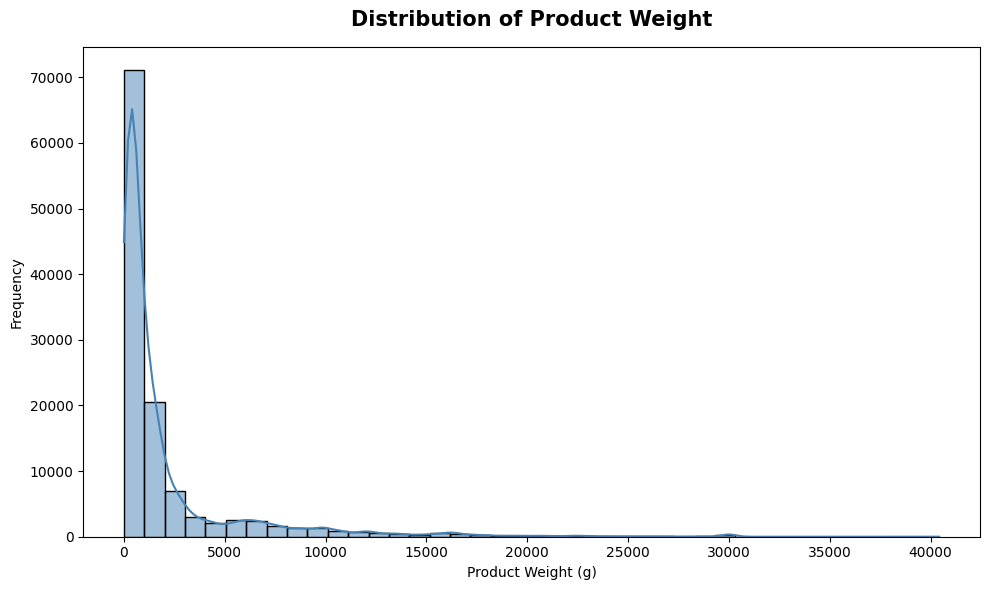

In [256]:
plt.figure(figsize=(10,6))

sns.histplot(
    final_dataset["product_weight_g"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title(
    "Distribution of Product Weight",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Product Weight (g)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../images/product_weight_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The histogram shows that the distribution of product weight is highly positively (right) skewed.

Most products weigh less than 2 kg, with the highest concentration of observations occurring at the lower end of the weight range. As product weight increases, the frequency of products decreases rapidly, forming a long right tail.

A relatively small number of products have exceptionally high weights, extending up to 40.43 kg. These observations represent heavy products that are uncommon compared to the majority of items sold on the marketplace.

The difference between the mean (2,112 g) and the median (700 g) further confirms the presence of a right-skewed distribution, where a few heavy products increase the average product weight.

#### Business Insights

The majority of products sold on the Olist marketplace are lightweight, making them easier and less expensive to ship.

Only a small proportion of products are heavy, but these products are likely to contribute disproportionately to freight costs and logistics complexity.

The long right tail suggests considerable variation in product weights across different product categories.

Product weight is expected to be an important factor influencing shipping costs and customer delivery experiences, making it a valuable variable for further analysis in the Bivariate Analysis section

### Boxplot

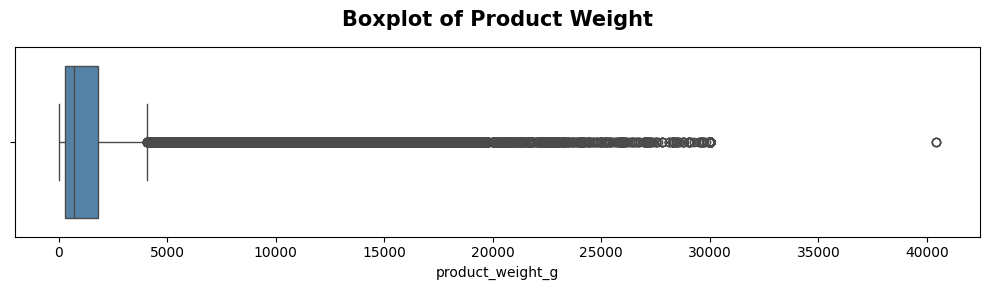

In [257]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=final_dataset["product_weight_g"],
    color="steelblue"
)

plt.title(
    "Boxplot of Product Weight",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    "../images/product_weight_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The boxplot indicates that the distribution of product weight is highly right-skewed and contains a substantial number of high-value outliers.

The median product weight is relatively low, while the middle 50% of products (Interquartile Range) are concentrated within a narrow range, indicating that most products are lightweight. Numerous observations lie beyond the upper whisker, representing products with significantly higher weights than the majority of the dataset.

The most extreme product weighs approximately 40.43 kg, highlighting the presence of a few exceptionally heavy products. These observations are expected in an e-commerce marketplace that offers a wide variety of products, ranging from small household items to large furniture and appliances.

Overall, the boxplot confirms that although most products are relatively light, a small proportion of heavy products contributes to the long upper tail of the distribution.

#### Business Insights
The majority of products are lightweight, resulting in lower shipping and handling costs for most orders.

Heavy products are relatively rare but are likely to incur higher freight charges and require additional logistics resources.

The presence of numerous high-weight outliers reflects the diverse range of products available on the marketplace rather than data quality issues.

Product weight is expected to have a strong relationship with freight cost and may also vary across product categories. These relationships will be examined in the Bivariate Analysis section.

## Summary of Univariate Analysis

In this section, each variable was analyzed independently to understand its distribution, variability, frequency, data quality, and business significance within the Olist e-commerce marketplace.

The analysis revealed that customer review scores are generally high, indicating positive customer satisfaction across most purchases. Payment values and freight charges exhibit right-skewed distributions with several high-value outliers, suggesting that while most transactions involve relatively low amounts, a small number of expensive purchases contribute substantially to overall revenue and shipping costs.

Product demand is concentrated within a limited number of product categories, highlighting the marketplace's most popular product segments. Order status analysis shows that the vast majority of orders are successfully delivered, while cancelled and unavailable orders represent only a small proportion of total transactions.

The seller distribution analysis indicates that sellers are highly concentrated in a few Brazilian states, particularly São Paulo, reflecting a geographically uneven seller network. Payment type analysis demonstrates that credit cards are the dominant payment method, followed by boleto payments, whereas vouchers and debit cards account for a much smaller share of transactions.

Product weight analysis reveals a highly right-skewed distribution with numerous extreme outliers. Most products are relatively lightweight, while a small number of very heavy products may significantly influence freight costs, logistics, and warehouse operations.

Missing value analysis across all selected variables showed that most missing records are associated with unavailable or cancelled orders, indicating that the missing information primarily reflects incomplete business transactions rather than data quality issues. The small proportion of missing values has a negligible impact on the overall analysis and was therefore retained without modification.

Overall, the univariate analysis provided a comprehensive understanding of the individual characteristics of the dataset and established a strong foundation for subsequent analyses. The insights obtained from this stage will support the next phase of Bivariate Analysis, where relationships between variables will be explored to uncover customer behavior patterns, operational trends, and actionable business insights.

## 7.12 Bivariate Analysis

### Introduction

Bivariate Analysis examines the relationship between two variables to identify associations, trends, and potential business drivers within the Olist e-commerce marketplace.

Unlike univariate analysis, which focuses on a single variable, bivariate analysis investigates how one variable changes with another. These relationships help explain customer behavior, operational performance, payment patterns, logistics, and product characteristics.

The insights obtained in this section provide valuable business knowledge and serve as a foundation for later statistical techniques such as correlation analysis, hypothesis testing, regression, and predictive modeling.

## 7.12.1 Payment Value vs Review Score

### Business Understanding

The payment_value variable represents the total amount paid by a customer for an order, while the review_score variable reflects the customer's overall satisfaction with the purchase on a scale from 1 (lowest) to 5 (highest).

This analysis investigates whether customer spending influences satisfaction. In other words, it examines whether customers who spend more tend to provide higher review scores or whether customer satisfaction is driven primarily by other factors such as product quality, delivery performance, and service experience.

Understanding this relationship can help businesses determine whether higher-value purchases require additional attention to maintain customer satisfaction.

### Business Questions

This analysis aims to answer the following questions:

- Does spending more lead to higher customer satisfaction?
- Are high-value purchases associated with lower review scores?
- Is customer satisfaction independent of the amount paid?
- Does the variability of payment values differ across review score categories?

### Variables

| Variable        | Type                   | Role                          |
| --------------- | ---------------------- | ----------------------------- |
| `review_score`  | Categorical (Ordinal)  | Independent Variable (X-axis) |
| `payment_value` | Numerical (Continuous) | Dependent Variable (Y-axis)   |


### Check Missing Values

In [258]:
final_dataset[
    ["review_score", "payment_value"]
].isna().sum()

review_score     997
payment_value      3
dtype: int64

#### Interpretation

The missing value analysis reveals:

The payment_value variable contains only 3 missing values, representing a negligible proportion of the dataset.
The review_score variable contains 997 missing values, which is considerably higher.

Unlike payment information, missing review scores are expected because not every customer submits a review after completing a purchase. Therefore, the absence of a review does not necessarily indicate poor data quality but rather reflects customer behavior.

Since the relationship between payment value and review score can only be evaluated for orders with available review scores, records with missing review scores will be excluded from this specific bivariate analysis.

In [260]:
# Create a temporary dataset

payment_review = final_dataset[
    ["payment_value", "review_score"]
].dropna()

### Descriptive Statistics by Review Score

In [261]:
payment_review.groupby("review_score")["payment_value"].describe()

,count,mean,std,min,25%,50%,75%,max
review_score,,,,,,,,
1.0,15425.0,231.630629,460.768807,0.00,72.18,134.25,236.5400,13664.08
2.0,4162.0,191.316970,264.562303,0.17,64.22,119.08,211.1075,3360.66
3.0,9894.0,167.840188,221.767268,0.00,59.50,107.44,187.9300,3242.84
4.0,22319.0,163.469189,219.218092,0.00,59.09,104.38,180.7650,4764.34
5.0,66343.0,160.777450,218.550270,0.00,58.59,104.40,179.1900,6929.31


#### Interpretation

The descriptive statistics summarize the distribution of payment values for each review score category after excluding records with missing review scores.

Several observations can be made:

- Orders with a 1-star review have the highest average payment value (231.63 BRL), while the average payment value gradually decreases as the review score increases.
- The median payment value also follows a similar pattern, decreasing from 134.25 BRL for 1-star reviews to 104.40 BRL for 5-star reviews.
- All review score categories exhibit a large standard deviation, indicating considerable variation in payment values within each rating group.
- The maximum payment values are substantially higher than the median values across all review categories, indicating the presence of several high-value transactions.
- The payment value distribution is positively skewed for every review score, with a small number of expensive purchases creating extreme outliers.

#### Observation

- Higher payment values are not associated with higher review scores.
- Customers who provided 1-star reviews spent more on average than those who gave higher ratings.
- Median payment values remain relatively close across review score categories, despite the differences in average payment values.
- All review score groups contain high-value outliers, indicating that expensive purchases occur regardless of customer satisfaction.

#### Business Insights

- Order value alone is not a strong driver of customer satisfaction.
- Customers making expensive purchases may have higher expectations, making them more likely to provide lower ratings if the overall experience does not meet those expectations.
- Improving factors such as product quality, delivery performance, packaging, and customer support is likely to have a greater impact on customer satisfaction than simply increasing sales value.
- Since payment values overlap considerably across all review score categories, additional variables should be examined to better understand customer satisfaction. This motivates further analyses involving delivery time, freight charges, payment methods, and product categories.

*While descriptive statistics provide a numerical summary of payment values across review score categories, a boxplot offers a clearer visualization of the distribution, variability, and presence of outliers within each group.*

### Visualization

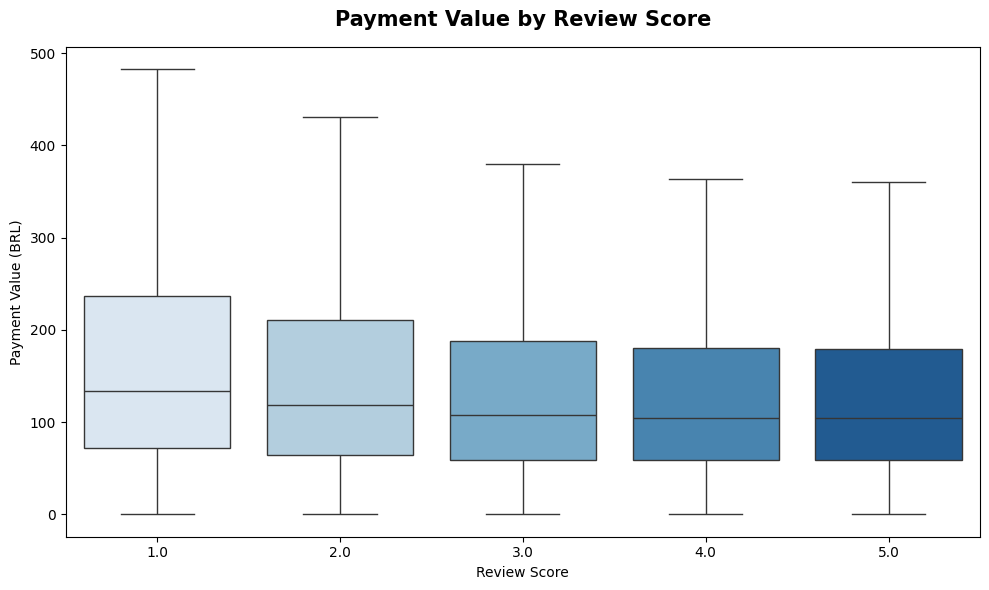

In [269]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=payment_review,
    x="review_score",
    y="payment_value",
    showfliers=False,
    palette="Blues"
)

plt.title(
    "Payment Value by Review Score",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Review Score")
plt.ylabel("Payment Value (BRL)")

plt.tight_layout()

plt.savefig(
    "../images/payment_value_vs_review_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

*Outliers were hidden in the visualization to improve readability. They remain part of the dataset and are included in all statistical calculations.*

#### Interpretation

The boxplot compares the distribution of payment values across different customer review score categories.

Key observations include:

- The median payment value is slightly higher for 1-star reviews and gradually decreases for higher review scores, although the differences are relatively small.
- Customers giving higher review scores (4 and 5) do not consistently spend more than customers giving lower ratings.
- The interquartile ranges (IQRs) overlap substantially across all review score categories, indicating that payment values are distributed similarly regardless of the review score.
- Although the visualization hides outliers for better readability, the descriptive statistics reveal the presence of numerous high-value transactions across all review score categories, indicating considerable variability in payment amounts.

Overall, the boxplot suggests that payment value alone has only a weak relationship with customer review score.

#### Observation

The median payment value is highest for 1-star reviews (approximately BRL 134) and gradually decreases to around BRL 104 for 4-star and 5-star reviews.

Payment distributions overlap considerably across all review score categories.

The spread of payment values is relatively similar, although 1-star reviews exhibit slightly greater variability.

High-value transactions occur across every review score category.

No clear trend indicates that customers who spend more consistently provide higher review scores.

#### Business Insights

Customer satisfaction does not appear to be strongly influenced by the amount spent on a purchase.

Higher-priced orders are not guaranteed to receive better customer ratings; in fact, some expensive purchases receive low review scores.

Customers purchasing costly products may have higher expectations, making them more likely to leave lower ratings if those expectations are not met.

Factors such as delivery performance, product quality, packaging quality, order accuracy, and customer service are likely to have a greater impact on customer satisfaction than payment value alone.

Businesses should prioritize improving the overall customer experience rather than assuming that premium-priced purchases will naturally result in higher customer satisfaction.

## 7.12.2 Freight Value vs Product Weight

### Business Understanding

Freight Value represents the shipping cost paid for delivering an order, while Product Weight measures the weight of the purchased product in grams.

Shipping charges are generally expected to increase as product weight increases because heavier products require greater transportation, handling, and packaging resources. However, freight costs may also vary depending on factors such as delivery distance, seller and customer locations, shipping methods, and logistics efficiency.

This analysis investigates the relationship between product weight and freight value to determine whether heavier products consistently incur higher shipping charges.

### Business 

- Does freight value increase as product weight increases?
- Is there a positive relationship between product weight and freight cost?
- Are there lightweight products with unusually high freight charges?
- Are some heavy products shipped at relatively low cost?
- Besides product weight, do other factors appear to influence freight charges?

### Variables

| Variable           | Type                   | Role                          |
| ------------------ | ---------------------- | ----------------------------- |
| `product_weight_g` | Numerical (Continuous) | Independent Variable (X-axis) |
| `freight_value`    | Numerical (Continuous) | Dependent Variable (Y-axis)   |



### Check Missing Values

In [270]:
final_dataset[
    ["product_weight_g", "freight_value"]
].isna().sum()

product_weight_g    853
freight_value       833
dtype: int64

#### Interpretation of Missing Values

- The dataset contains 853 missing values for product_weight_g and 833 missing values for freight_value.
- These missing values primarily occur in unavailable and cancelled orders, where product and shipping information is naturally absent because the orders were not successfully fulfilled.
- Since this analysis investigates the relationship between product weight and freight value, observations with missing values in either variable cannot contribute meaningful information.
- Therefore, records with missing values will be excluded from this specific bivariate analysis using dropna().
- Given that these missing values represent a very small proportion of the overall dataset and are largely associated with incomplete transactions, their exclusion is unlikely to affect the overall conclusions.

In [272]:
# Create a clean dataset
freight_weight = final_dataset[
    ["product_weight_g", "freight_value"]
].dropna()

print("Original rows:", len(final_dataset))
print("Rows after removing missing values:", len(freight_weight))
print("Rows removed:", len(final_dataset) - len(freight_weight))


Original rows: 119143
Rows after removing missing values: 118290
Rows removed: 853


### Descriptive Statistics

In [273]:
freight_weight.describe() 

,product_weight_g,freight_value
count,118290.000000,118290.000000
mean,2112.250740,20.033201
std,3786.695111,15.837979
min,0.000000,0.000000
25%,300.000000,13.080000
50%,700.000000,16.280000
75%,1800.000000,21.180000
max,40425.000000,409.680000


### Visualization

#### Scatter Plot

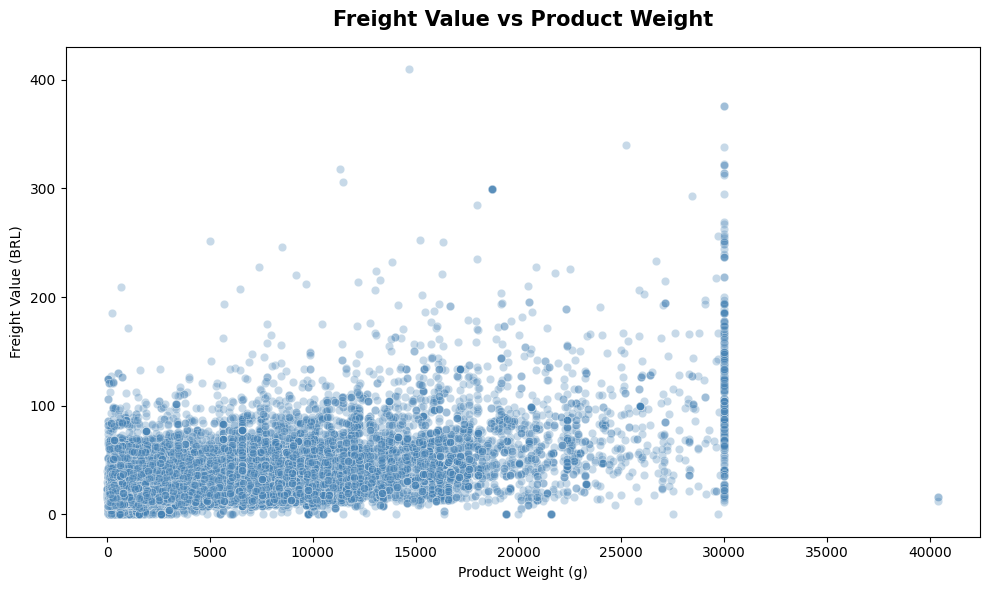

In [278]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=freight_weight,
    x="product_weight_g",
    y="freight_value",
    alpha=0.30,
    color="steelblue"
)

plt.title(
    "Freight Value vs Product Weight",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Product Weight (g)")
plt.ylabel("Freight Value (BRL)")

plt.tight_layout()

plt.savefig(
    "../images/freight_vs_product_weight.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Regression Plot

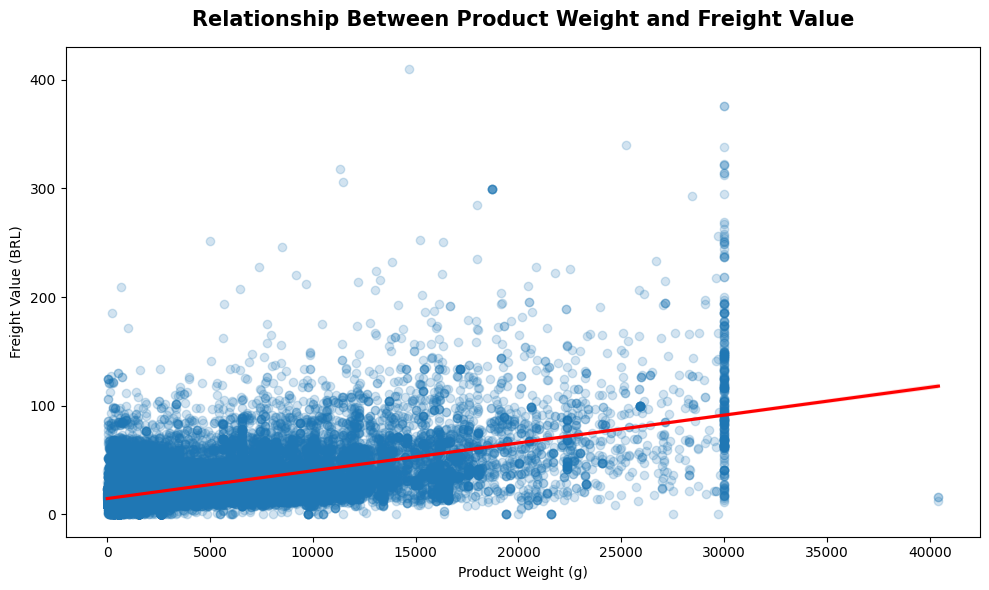

In [275]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=freight_weight,
    x="product_weight_g",
    y="freight_value",
    scatter_kws={"alpha":0.20},
    line_kws={"color":"red"}
)

plt.title(
    "Relationship Between Product Weight and Freight Value",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Product Weight (g)")
plt.ylabel("Freight Value (BRL)")

plt.tight_layout()

plt.savefig(
    "../images/freight_weight_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Pearson Correlation

To quantify the linear relationship between product weight and freight value, Pearson correlation is calculated.

Pearson correlation ranges from -1 to +1:

- A value close to +1 indicates a strong positive linear relationship.
- A value close to -1 indicates a strong negative linear relationship.
- A value close to 0 indicates a weak or negligible linear relationship.

The correlation coefficient helps quantify the relationship observed in the scatter plot and regression plot.

In [276]:
correlation = freight_weight["product_weight_g"].corr(
    freight_weight["freight_value"],
    method="pearson"
)

print("Pearson Correlation:", round(correlation, 3))

Pearson Correlation: 0.612


#### Interpretation

A Pearson correlation of 0.612 indicates a moderate-to-strong positive linear relationship between product_weight_g and freight_value.

In practical terms, as product weight increases, freight value tends to increase as well. This supports the upward trend visible in your regression plot.

However, the correlation is not close to +1, so product weight does not completely determine freight cost. There is substantial variation in freight charges for products with similar weights.

#### Observation

- The Pearson correlation coefficient between product weight and freight value is **0.612**.
- This indicates a **moderate-to-strong positive linear relationship** between the two variables.
- The positive correlation confirms the upward trend observed in the regression plot.
- As product weight increases, freight value generally tends to increase.
- However, the relationship is not perfectly linear, indicating that product weight alone does not fully explain variations in freight charges.
- Considerable dispersion is visible, particularly among heavier products, suggesting the influence of additional factors on shipping costs.

#### Business Insights

- Product weight is an important factor influencing freight costs.
- Heavier products generally tend to incur higher shipping charges.
- The correlation of **0.612** indicates that weight has a meaningful relationship with freight value, but it is not the only determinant.
- Other factors such as delivery distance, seller location, customer location, shipping zones, and logistics policies may also influence freight charges.
- Therefore, an effective freight-pricing strategy should consider multiple factors rather than relying solely on product weight.
- Understanding these factors can help the business improve shipping-cost estimation and logistics efficiency.

## 7.12.3 Product Category vs Review Score

### Business Understanding

Customer satisfaction may vary across different product categories. Analyzing review scores by category can help identify product groups that consistently receive positive or negative customer feedback.

This can help the business identify categories with strong customer satisfaction and categories that may require improvements in product quality, descriptions, packaging, or fulfillment.

### Business Questions
- Which product categories have the highest average review scores?
- Which categories have the lowest average review scores?
- Are some product categories consistently associated with lower customer satisfaction?
- Which categories may require further investigation?

### Variables

| Variable                        | Type        | Role                 |
| ------------------------------- | ----------- | -------------------- |
| `product_category_name_english` | Categorical | Independent Variable |
| `review_score`                  | Ordinal     | Dependent Variable   |


### Check Missing Values

In [279]:
final_dataset[
    ["product_category_name_english", "review_score"]
].isna().sum()

product_category_name_english    853
review_score                     997
dtype: int64

#### Investigate missing product categories

In [281]:
missing_category = final_dataset[
    final_dataset["product_category_name_english"].isna()
]

missing_category["order_status"].value_counts()

order_status
unavailable    645
canceled       180
delivered       20
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [282]:
missing_category[
    ["order_id", "order_status", "product_id",
     "product_category_name_english"]
].head(10)

,order_id,order_status,product_id,product_category_name_english
319,8e24261a7e58791d10cb1bf9da94df5c,unavailable,NaN,NaN
702,c272bcd21c287498b4883c7512019702,unavailable,NaN,NaN
828,37553832a3a89c9b2db59701c357ca67,unavailable,NaN,NaN
887,d57e15fb07fd180f06ab3926b39edcd2,unavailable,NaN,NaN
1362,00b1cb0320190ca0daa2c88b35206009,canceled,NaN,NaN
1395,2f634e2cebf8c0283e7ef0989f77d217,unavailable,NaN,NaN
1897,ee0db22a8e742b752914016708470ec8,unavailable,NaN,NaN
2142,ed3efbd3a87bea76c2812c66a0b32219,canceled,NaN,NaN
2180,6ad57aecbae806a7e9cc2cdb6b380711,unavailable,NaN,NaN
2232,df8282afe61008dc26c6c31011474d02,canceled,NaN,NaN


##### Interpretation

The missing product category values were investigated by examining their
associated order statuses.

A total of 853 records have missing product category information. The majority
of these records are associated with unavailable (645) and canceled (180)
orders. Together, these account for approximately 96.7% of all missing
category records.

Only a small number of missing-category records belong to delivered orders
(20), while the remaining records are associated with created, invoiced, and
shipped orders.

The investigation also shows that product information is missing in several
of these records, suggesting that the missing category values are primarily
related to incomplete product/order records rather than a problem with the
category-name translation itself.

Since product category is required for the category-level review analysis,
records with missing categories will be excluded using dropna(). The original
dataset will not be modified.

##### Observation

- 853 records have missing product category information.
- Most missing category records are associated with unavailable or canceled
  orders.
- Only 20 missing-category records belong to delivered orders.
- The missing values appear to be concentrated among incomplete or
  unsuccessful orders.
- Therefore, excluding these records from the Product Category vs Review Score
  analysis is unlikely to substantially distort the analysis of completed
  customer purchases.

#### Investigate Missing Review Score:

In [283]:
missing_review = final_dataset[
    final_dataset["review_score"].isna()
]

missing_review["order_status"].value_counts()

order_status
delivered      861
shipped         88
canceled        20
unavailable     14
processing       6
invoiced         6
created          2
Name: count, dtype: int64

In [284]:
missing_review[
    ["order_id", "order_status", "review_score"]
].head(10)

,order_id,order_status,review_score
20,403b97836b0c04a622354cf531062e5f,delivered,NaN
192,6942b8da583c2f9957e990d028607019,shipped,NaN
371,4906eeadde5f70b308c20c4a8f20be02,delivered,NaN
455,b7a4a9ecb1cd3ef6a3e36a48e200e3be,delivered,NaN
463,59b32faedc12322c672e95ec3716d614,delivered,NaN
485,c2215076050fa358934105b15c34cf3b,delivered,NaN
639,eafef0e6c44f121531569a69a318c3b3,delivered,NaN
1004,95d9d2979d40161be87292ff88563cba,delivered,NaN
1005,95d9d2979d40161be87292ff88563cba,delivered,NaN
1007,a9b151f0c0471d9b2534fa73c9c0e123,delivered,NaN


##### Interpretation

A total of 997 records have missing review scores. The missing review records
were investigated by examining their associated order statuses.

The majority of missing review scores (861 records, approximately 86.4%) are
associated with delivered orders. A further 88 records (8.8%) belong to
shipped orders, while only a small proportion are associated with canceled,
unavailable, processing, invoiced, and created orders.

The high number of missing review scores among delivered orders suggests that
a missing review score does not necessarily indicate an unsuccessful order or
poor customer satisfaction. Instead, customers may have completed their
purchases without submitting a review.

Therefore, missing review scores are treated as unavailable customer feedback
rather than as negative ratings. Since review score is required for the
Product Category vs Review Score analysis, records with missing review scores
will be excluded from this specific bivariate analysis using dropna().

##### Observation

- 997 records have missing review scores.
- 86.4% of these records correspond to delivered orders.
- Only a small proportion of missing reviews are associated with canceled or
  unavailable orders.
- Missing review scores therefore appear to represent the absence of
  customer feedback rather than failed transactions.
- The analysis will use only records where both product category and review
  score are available.

In [280]:
# Create a temporary dataset:

category_review = final_dataset[
    ["product_category_name_english", "review_score"]
].dropna()

### Calculate both average and count of review score by category

In [288]:
category_summary = (
    category_review
    .groupby("product_category_name_english")["review_score"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

category_summary.head(15)


,mean,count
product_category_name_english,,
cds_dvds_musicals,4.642857,14
fashion_childrens_clothes,4.500000,8
books_general_interest,4.438503,561
flowers,4.419355,31
books_imported,4.419355,62
costruction_tools_tools,4.415842,101
books_technical,4.375465,269
food_drink,4.324138,290
small_appliances_home_oven_and_coffee,4.320513,78


##### Categories with a reasonable number of reviews

In [305]:
reliable_categories = category_summary[
    (category_summary["count"] >= 100) &
    (category_summary.index != "Unknown")
]

reliable_categories.head(15)

,mean,count
product_category_name_english,,
books_general_interest,4.438503,561
costruction_tools_tools,4.415842,101
books_technical,4.375465,269
food_drink,4.324138,290
luggage_accessories,4.295945,1159
food,4.228963,511
fashion_shoes,4.223443,273
home_appliances_2,4.212687,268
pet_shop,4.197030,2020


#### Top 15 Categories Visualization

In [306]:
top_15_categories = reliable_categories.head(15)

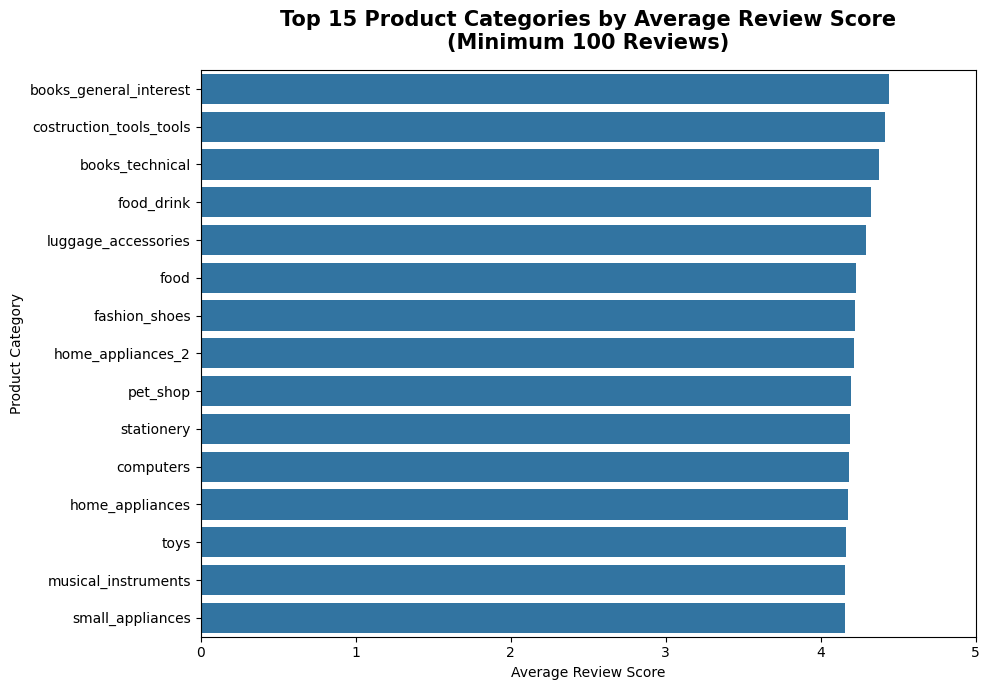

In [307]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_15_categories["mean"],
    y=top_15_categories.index
)

plt.title(
    "Top 15 Product Categories by Average Review Score\n"
    "(Minimum 100 Reviews)",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.xlim(0, 5)

plt.tight_layout()

plt.savefig(
    "../images/top_15_categories_by_review_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


##### Observation

- Among product categories with at least 100 reviews, books_general_interest
  has the highest average review score at approximately 4.44.
- Construction_tools_tools and books_technical also show high average review
  scores of approximately 4.42 and 4.38, respectively.
- Most of the top-performing categories have average review scores above 4.15,
  indicating generally positive customer satisfaction.
- Categories such as pet_shop, stationery, and toys have large numbers of
  reviews, making their average scores relatively well-supported.
- The differences in average review scores across the top categories are
  relatively small, suggesting generally positive satisfaction across these
  product categories.

##### Business Insights

- Product category appears to be associated with differences in customer
  satisfaction, although the differences among the highest-rated categories
  are relatively modest.
- Categories with consistently high review scores may provide useful examples
  of product quality or customer experience practices.
- Categories with lower average ratings should be investigated further to
  identify potential issues related to product quality, delivery, packaging,
  or customer expectations.
- Average review score should be interpreted together with review volume,
  since categories with very few reviews can produce unstable averages.

In [308]:
bottom_15_categories = (
    reliable_categories
    .sort_values("mean", ascending=True)
    .head(15)
)

bottom_15_categories

,mean,count
product_category_name_english,,
office_furniture,3.526791,1773
fashion_male_clothing,3.548611,144
fixed_telephony,3.672862,269
audio,3.840849,377
furniture_bedroom,3.841270,126
construction_tools_safety,3.848485,198
bed_bath_table,3.890605,11847
home_confort,3.907563,476
furniture_decor,3.912158,8743


#### Bottom-15 Categories Visualization

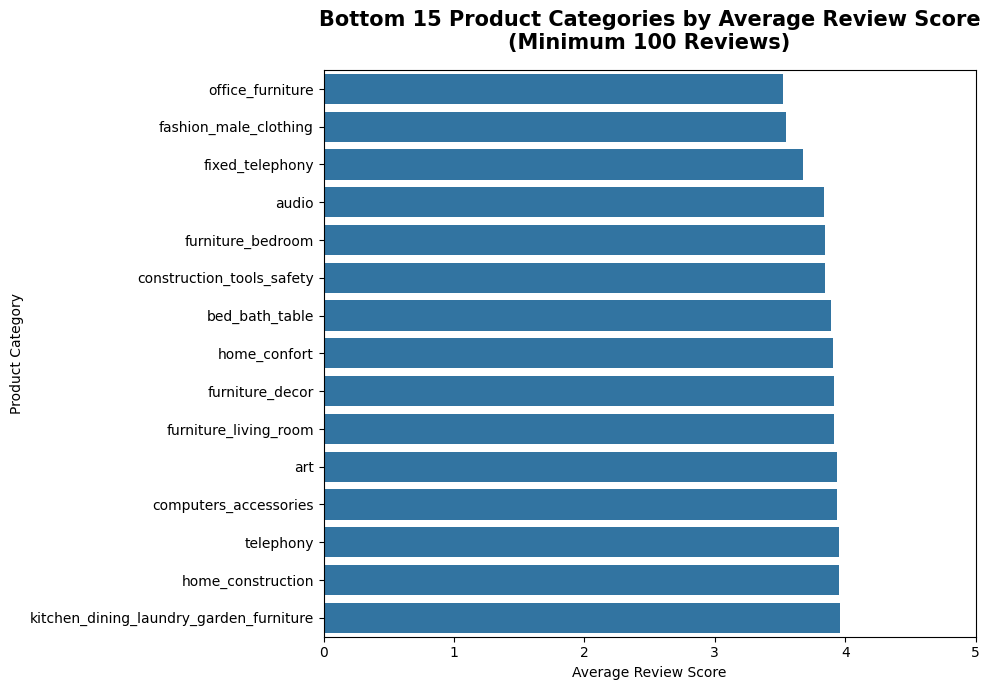

In [309]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=bottom_15_categories["mean"],
    y=bottom_15_categories.index
)

plt.title(
    "Bottom 15 Product Categories by Average Review Score\n"
    "(Minimum 100 Reviews)",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.xlim(0, 5)

plt.tight_layout()

plt.savefig(
    "../images/bottom_15_categories_by_review_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Observation

- Office furniture has the lowest average review score at 3.53, followed by fashion male clothing (3.55) and fixed telephony (3.67).
- Audio, furniture bedroom, and construction tools safety have average review scores around 3.84, indicating comparatively lower customer satisfaction.
- The remaining categories in the Bottom 15 have average review scores between approximately 3.89 and 3.96.
- Bed & bath table has a particularly large review volume of 11,847 reviews, while furniture decor and computers accessories have 8,743 and 8,105 reviews, respectively.
- The results show that customer satisfaction varies across product categories, with some categories receiving considerably lower average ratings than others.
- Since only categories with at least 100 reviews were included, the comparison is less affected by categories with very small sample sizes.

##### Business Insights

- Office furniture, fashion male clothing, and fixed telephony are the primary categories that may require investigation due to their relatively low average review scores.
- Businesses should investigate whether lower ratings are associated with product quality, customer expectations, delivery performance, packaging, sizing, or after-sales service.
- Categories with large numbers of reviews provide more reliable evidence of customer satisfaction patterns.
- The results can help businesses prioritize categories for quality improvement and customer-experience initiatives.
- Further bivariate analysis involving delivery time, freight value, payment value, and product characteristics can help identify the factors contributing to lower customer satisfaction.

### Observation

- Average review scores vary across product categories, indicating differences in customer satisfaction by product type.
- Among categories with at least 100 reviews, books_general_interest has the highest average review score at approximately 4.44, followed by construction_tools_tools (4.42) and books_technical (4.38).
- Office furniture has the lowest average review score at approximately 3.53, followed by fashion male clothing (3.55) and fixed telephony (3.67).
- Several categories with large numbers of reviews, such as bed & bath table (11,847), furniture decor (8,743), and computers accessories (8,105), have moderate average scores rather than being among the highest-rated categories.
- The difference between the highest-rated and lowest-rated categories shows that customer satisfaction is not uniform across product categories.
- The analysis uses a minimum threshold of 100 reviews and excludes Unknown, making the category comparison more reliable.
- Overall, product category appears to be associated with differences in customer satisfaction, although category alone cannot explain why customers give higher or lower ratings. Further analysis with delivery time, freight value, product characteristics, and other factors would be useful.

## 7.12.4 Product Category vs Payment Value

### Business Understanding

Different product categories may have different price and spending patterns. Understanding payment values across categories can help identify categories associated with higher-value and lower-value purchases.

This analysis examines how customer payment values vary across product categories.

### Business Questions
- Which product categories are associated with higher payment values?
- Which categories tend to have lower payment values?
- How much does payment value vary within each category?
- Are some categories characterized by a small number of very high-value purchases?
- Do high-volume categories necessarily have higher payment values?

### Variables

| Variable                        | Type                   | Role                 |
| ------------------------------- | ---------------------- | -------------------- |
| `product_category_name_english` | Categorical            | Independent Variable |
| `payment_value`                 | Numerical (Continuous) | Dependent Variable   |


### Check Missing Values

In [310]:
final_dataset[
    ["product_category_name_english", "payment_value"]
].isna().sum()

product_category_name_english    853
payment_value                      3
dtype: int64

#### Interpretation:

Product category contains 853 missing values, which were investigated in the previous Product Category vs Review Score analysis. Payment value contains only 3 missing values. Since these records cannot contribute to the comparison between product category and payment value, rows with missing values are excluded from this analysis.

In [312]:
# Create the analysis dataset

category_payment = final_dataset[
    ["product_category_name_english", "payment_value"]
].dropna()

# exclude Unknown

category_payment = category_payment[
    category_payment["product_category_name_english"] != "Unknown"
]

### Descriptive Statistics

Since payment_value distribution is highly right-skewed, need to calculate both mean and median.

In [313]:
category_payment_summary = (
    category_payment
    .groupby("product_category_name_english")["payment_value"]
    .agg(["mean", "median", "count"])
    .sort_values("median", ascending=False)
)

category_payment_summary.head(15)

,mean,median,count
product_category_name_english,,,
computers,1268.734318,1240.850,220
small_appliances_home_oven_and_coffee,656.786154,644.340,78
home_appliances_2,462.466370,256.870,270
office_furniture,364.662472,233.940,1788
furniture_bedroom,253.265317,230.750,126
agro_industry_and_commerce,471.153214,224.600,252
construction_tools_lights,232.379172,193.980,314
air_conditioning,301.889603,187.180,302
construction_tools_safety,330.105678,186.620,199


*Median payment value is often a better representation of the typical purchase than mean payment value.*

### Visualization

In [ ]:
# First select categories with a reasonable number of observations (use minimum 100 transactions):

reliable_categories = (
    category_payment_summary[
        category_payment_summary["count"] >= 100
    ]
)

reliable_categories.head(15)

,mean,median,count
product_category_name_english,,,
computers,1268.734318,1240.85,220
home_appliances_2,462.466370,256.87,270
office_furniture,364.662472,233.94,1788
furniture_bedroom,253.265317,230.75,126
agro_industry_and_commerce,471.153214,224.60,252
construction_tools_lights,232.379172,193.98,314
air_conditioning,301.889603,187.18,302
construction_tools_safety,330.105678,186.62,199
kitchen_dining_laundry_garden_furniture,250.421538,157.21,299


In [321]:
# Top 15 categories based on median payment value:

top_15_categories = (
    reliable_categories
    .sort_values("median", ascending=False)
    .head(15)
)

top_15_categories

,mean,median,count
product_category_name_english,,,
computers,1268.734318,1240.85,220
home_appliances_2,462.466370,256.87,270
office_furniture,364.662472,233.94,1788
furniture_bedroom,253.265317,230.75,126
agro_industry_and_commerce,471.153214,224.60,252
construction_tools_lights,232.379172,193.98,314
air_conditioning,301.889603,187.18,302
construction_tools_safety,330.105678,186.62,199
kitchen_dining_laundry_garden_furniture,250.421538,157.21,299


In [322]:
# Create the plotting dataset:

top_categories = top_15_categories.index

category_payment_top15 = category_payment[
    category_payment["product_category_name_english"].isin(top_categories)
]

category_payment_top15

,product_category_name_english,payment_value
11,office_furniture,161.42
12,office_furniture,8.34
20,construction_tools_construction,1376.45
31,cool_stuff,125.43
35,watches_gifts,192.68
...,...,...
119121,construction_tools_construction,319.25
119122,furniture_living_room,146.83
119124,watches_gifts,104.79
119129,musical_instruments,71.04


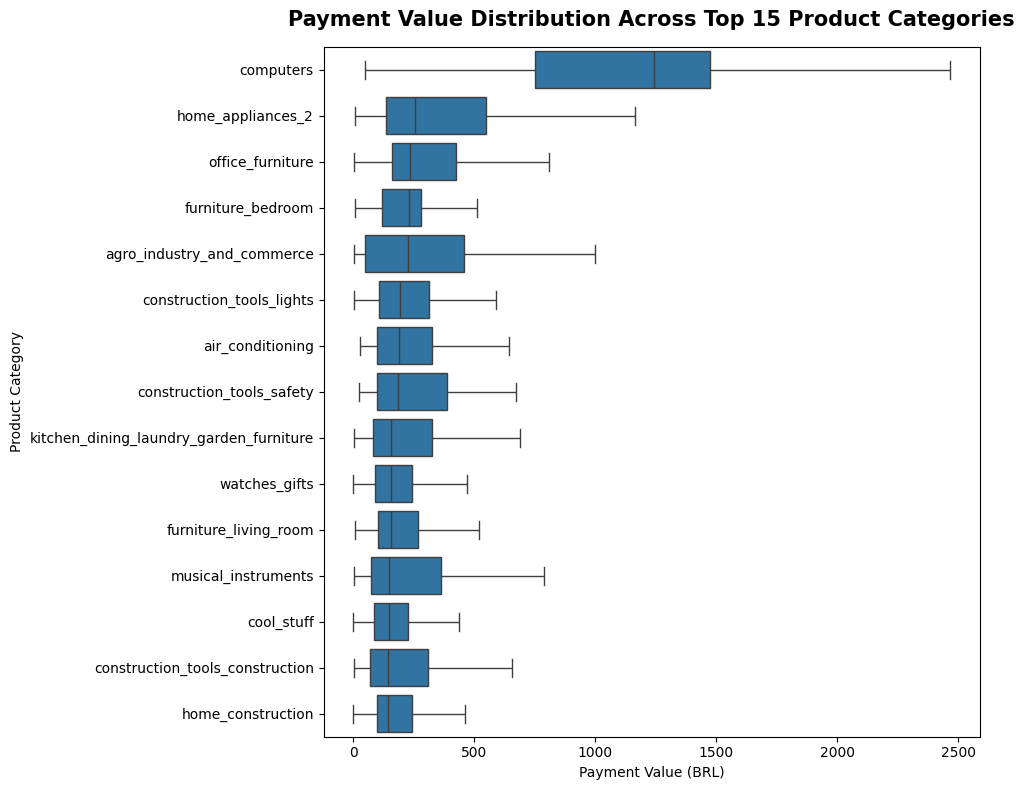

In [326]:
plt.figure(figsize=(10, 8))

sns.boxplot(
    data=category_payment_top15,
    x="payment_value",
    y="product_category_name_english",
    order=top_15_categories.index,
    showfliers=False
)

plt.title(
    "Payment Value Distribution Across Top 15 Product Categories",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Payment Value (BRL)")
plt.ylabel("Product Category")

plt.tight_layout()

plt.savefig(
    "../images/payment_value_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The boxplot shows that payment values vary considerably across product categories. Computers have by far the highest typical payment value, with a median of approximately BRL 1,240.85, substantially higher than the other categories shown. home_appliances_2 and office_furniture follow with median payment values of approximately BRL 256.87 and BRL 233.94, respectively.

Most other categories have considerably lower median payment values, generally below approximately BRL 230. The width of the boxes and whiskers also indicates substantial variation in payment values within several categories.

The mean is considerably higher than the median for some categories, particularly computers (mean ≈ BRL 1,268.73 vs. median ≈ BRL 1,240.85) and agro_industry_and_commerce (mean ≈ BRL 471.15 vs. median ≈ BRL 224.60), suggesting that higher-value transactions influence the average.

Because showfliers=False was used in the visualization, individual outliers are not displayed in the boxplot.

### Observation

- Computers have the highest typical payment value, with a median of approximately BRL 1,240.85.
home_appliances_2 and office_furniture also show relatively high median payment values compared with most other categories.

- Most categories have substantially lower median payment values, indicating that typical transaction values differ significantly across product categories.

- Several categories show a noticeable difference between their mean and median, indicating right-skewed payment distributions caused by higher-value transactions.

- agro_industry_and_commerce is a particularly clear example, with a mean of approximately BRL 471.15 compared with a median of BRL 224.60.

- The boxplot shows considerable variation within several categories, meaning payment value is not consistent even within the same product category.

- Overall, product category appears to be associated with the typical payment value of a transaction.

### Business Insights

- Computers represent a high-value transaction category, making them important for strategies focused on high-value sales and revenue generation.

- Categories with lower median payment values may depend more heavily on higher sales volume to generate substantial total revenue.

- The large difference between mean and median in some categories suggests that a small number of expensive purchases can significantly increase average payment value.

- Businesses should therefore consider both transaction volume and typical payment value when evaluating category performance rather than relying on average payment alone.

- High-value categories may require different pricing, promotions, financing, and customer-retention strategies compared with lower-value categories.

- Understanding the payment-value distribution within each category can help businesses identify high-value product segments and opportunities for targeted marketing.

## 7.12.5 Seller State vs Order Volume

### Business Understanding

Seller location can influence marketplace coverage, logistics efficiency, delivery times, and regional market reach.

This analysis examines the distribution of orders across seller states to understand where marketplace activity is geographically concentrated.

### Business Questions

- Which seller states generate the highest number of orders?

- Is marketplace activity concentrated in a small number of states?

- Which states have relatively low order volumes?

- Which regions may have potential for marketplace expansion?

### Variables

| Variable       | Type                   | Role                        |
| -------------- | ---------------------- | --------------------------- |
| `seller_state` | Categorical            | Independent Variable        |
| `order_id`     | Categorical/Identifier | Used to count unique orders |

***Important**: Since the dataset can contain multiple rows for the same order, we should count unique order_id, rather than simply counting rows.*

### Check Missing Values

In [328]:
final_dataset[
    ["seller_state", "order_id"]
].isna().sum()

seller_state    833
order_id          0
dtype: int64

In [330]:
missing_seller_state = final_dataset[
    final_dataset["seller_state"].isna()
]

missing_seller_state[
    ["order_id", "seller_id", "seller_state", "order_status"]
].head(10)

,order_id,seller_id,seller_state,order_status
319,8e24261a7e58791d10cb1bf9da94df5c,NaN,NaN,unavailable
702,c272bcd21c287498b4883c7512019702,NaN,NaN,unavailable
828,37553832a3a89c9b2db59701c357ca67,NaN,NaN,unavailable
887,d57e15fb07fd180f06ab3926b39edcd2,NaN,NaN,unavailable
1362,00b1cb0320190ca0daa2c88b35206009,NaN,NaN,canceled
1395,2f634e2cebf8c0283e7ef0989f77d217,NaN,NaN,unavailable
1897,ee0db22a8e742b752914016708470ec8,NaN,NaN,unavailable
2142,ed3efbd3a87bea76c2812c66a0b32219,NaN,NaN,canceled
2180,6ad57aecbae806a7e9cc2cdb6b380711,NaN,NaN,unavailable
2232,df8282afe61008dc26c6c31011474d02,NaN,NaN,canceled


In [ ]:
# Check whether all 833 missing seller states also have missing seller IDs
missing_seller_state["seller_id"].isna().sum()

np.int64(833)

In [ ]:
# Check order status
missing_seller_state["order_status"].value_counts()

order_status
unavailable    645
canceled       180
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

#### Interpretation

A total of 833 records have missing seller-state information. All 833 of these records also have missing seller IDs, indicating that the missing seller state is a consequence of unavailable seller information rather than an isolated missing location value. Most of these records are associated with unavailable (645) and canceled (180) orders. Since the seller cannot be reliably identified for these records, seller state cannot be accurately determined. These records are therefore excluded from the seller-state order-volume analysis rather than being imputed.

#### Observation

Missing seller-state records are strongly concentrated among unavailable and canceled orders. Only 8 records with missing seller state have other statuses (created, invoiced, or shipped). This suggests that the missing seller information is largely associated with orders that did not progress normally through the fulfillment process.

### Data Preparation

In [334]:
# Create a summary containing the number of unique orders per seller state:

seller_state_orders = (
    final_dataset
    .dropna(subset=["seller_state"])
    .groupby("seller_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

seller_state_orders

seller_state
SP    70188
MG     7930
PR     7673
RJ     4353
SC     3667
RS     1989
DF      824
BA      569
GO      463
PE      406
MA      392
ES      318
MT      137
CE       91
RN       51
MS       49
PB       36
RO       14
PI       12
SE        9
PA        8
AM        3
AC        1
Name: order_id, dtype: int64

#### Observation

São Paulo (SP) is overwhelmingly dominant, with 70,188 unique orders, compared with 7,930 for MG and 7,673 for PR.

### Descriptive Statistics

Since seller_state is categorical and order volume is a count, traditional statistics such as mean and standard deviation of seller state aren't particularly meaningful.

Instead, your most useful descriptive statistics are:

- Total unique orders by state
- Highest order-volume state
- Lowest order-volume state
- Number of states represented
- Ranking of states by order volume

In [335]:
seller_state_orders.describe()

count       23.000000
mean      4312.304348
std      14551.523011
min          1.000000
25%         25.000000
50%        318.000000
75%       1406.500000
max      70188.000000
Name: order_id, dtype: float64

In [336]:
print("Number of states:", seller_state_orders.index.nunique())
print("Highest order volume:", seller_state_orders.max())
print("Highest-volume state:", seller_state_orders.idxmax())
print("Lowest order volume:", seller_state_orders.min())
print("Lowest-volume state:", seller_state_orders.idxmin())

Number of states: 23
Highest order volume: 70188
Highest-volume state: SP
Lowest order volume: 1
Lowest-volume state: AC


#### Interpretation

Order volume varies substantially across seller states. São Paulo has the highest order volume with 70,188 unique orders, far exceeding all other states. The median order volume is only 318 orders, compared with a mean of 4,312 orders, indicating a strongly right-skewed distribution caused primarily by the exceptionally high order volume in São Paulo. The large standard deviation of 14,551.52 further confirms substantial variation in marketplace activity across states.

#### Observation

The marketplace is highly concentrated geographically. São Paulo is a clear outlier with 70,188 unique orders, while most states have considerably lower order volumes. The median of 318 orders compared with the maximum of 70,188 demonstrates the extreme imbalance in order distribution across states.

This is better than simply saying "São Paulo dominates" because you're actually supporting the observation with your statistics.

#### Business Insights

- São Paulo is the primary marketplace hub, accounting for a disproportionately large share of seller-side order activity.

- The large difference between São Paulo and the remaining states indicates strong geographical concentration of marketplace activity.

- States such as MG and PR, with 7,930 and 7,673 orders respectively, represent the next significant seller markets.

- The large variation across states suggests that seller presence, customer demand, logistics infrastructure, and marketplace penetration are not evenly distributed.

- Lower-volume states may provide potential expansion opportunities, but low order volume alone does not prove that demand is weak.

- Before expanding into lower-volume states, the business should examine customer demand, number of active sellers, revenue, delivery performance, and logistics coverage.

### Visualization

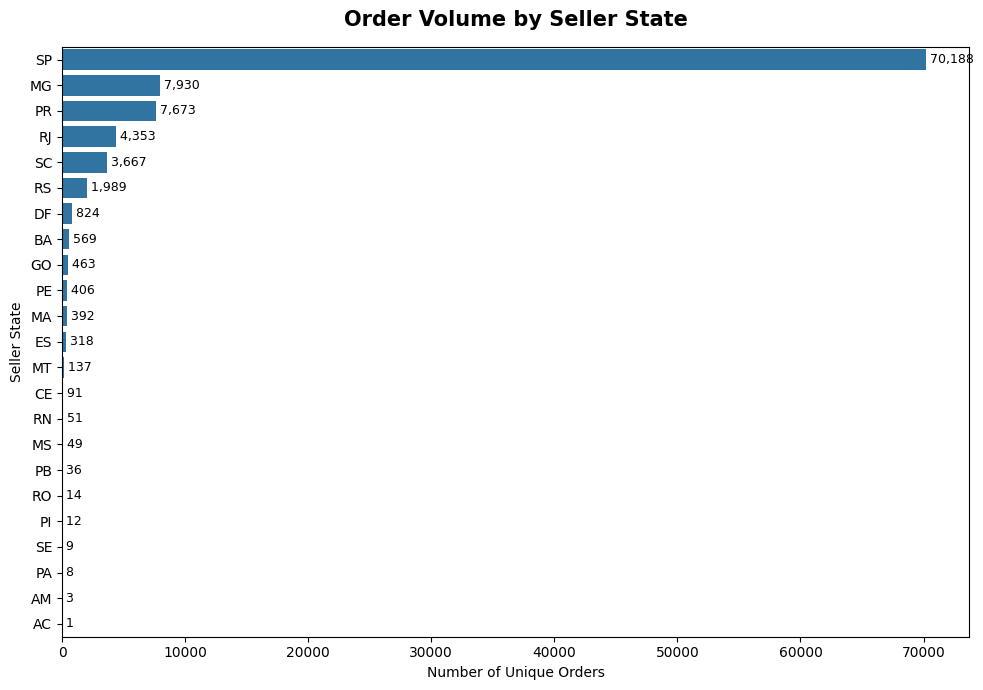

In [339]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=seller_state_orders.values,
    y=seller_state_orders.index
)

plt.title(
    "Order Volume by Seller State",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Unique Orders")
plt.ylabel("Seller State")

for i, value in enumerate(seller_state_orders.values):
    ax.text(
        value,
        i,
        f" {value:,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "../images/seller_state_order_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Final interpretation

The visualization shows a highly uneven distribution of order volume across seller states. São Paulo (SP) has an exceptionally high order volume of 70,188 unique orders, substantially exceeding Minas Gerais (MG) and Paraná (PR), which have 7,930 and 7,673 orders respectively. Order volumes decline sharply across the remaining states, indicating strong geographical concentration of marketplace activity.

### Final observation

São Paulo is a clear outlier in terms of seller-side order volume. The large gap between SP and all other states confirms the highly right-skewed distribution observed in the descriptive statistics. Most states contribute relatively small volumes compared with the leading markets.

### Final business insights

- São Paulo is the primary marketplace hub and should receive significant attention in seller management, logistics, and operational planning.

- MG and PR are important secondary markets, although their order volumes remain substantially lower than São Paulo.

- The strong geographical concentration suggests that marketplace activity is influenced by seller presence, customer demand, logistics infrastructure, and regional e-commerce maturity.

- Lower-volume states may offer potential expansion opportunities, but additional analysis of customer demand, seller density, revenue, and logistics coverage is required before making expansion decisions.

- The business can use state-level order patterns to prioritize seller acquisition, logistics investment, and regional marketing strategies.

## 7.12.6 Payment Type vs Payment Value

### Business Understanding

Different payment methods may be associated with different transaction values. Understanding how payment value varies across payment methods can help identify customer spending patterns and support payment-method strategy.

### Business Questions

- Do credit-card transactions generally have higher payment values?

- Are voucher transactions concentrated around smaller payment values?

- Which payment method has the highest typical transaction value?

- How much does payment value vary within each payment method?

- Are there unusually high-value transactions for particular payment methods?

### Variables

| Variable        | Type                   | Role                 |
| --------------- | ---------------------- | -------------------- |
| `payment_type`  | Categorical            | Independent Variable |
| `payment_value` | Numerical (Continuous) | Dependent Variable   |


### Check Missing Values

In [340]:
final_dataset[
    ["payment_type", "payment_value"]
].isna().sum()

payment_type     3
payment_value    3
dtype: int64

In [341]:
# First investigate these 3 missing records

missing_payment = final_dataset[
    final_dataset["payment_type"].isna() |
    final_dataset["payment_value"].isna()
]

missing_payment[
    ["order_id", "payment_type", "payment_value"]
]

,order_id,payment_type,payment_value
36864,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN
36865,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN
36866,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN


In [342]:
# Check whether these missing values correspond to particular order statuses

missing_payment["order_status"].value_counts()

order_status
delivered    3
Name: count, dtype: int64

#### Interpretation

Three records were identified with missing values in both payment_type and payment_value. All three records belong to the same order and have an order status of delivered. This indicates that the missing payment information is not limited to cancelled or unsuccessful orders. Since the actual payment method and transaction value cannot be reliably inferred, these records are excluded from the payment type vs payment value analysis rather than being imputed.

#### Observation

The analysis contains only three records with missing payment information, representing a negligible portion of the dataset. Because both the categorical payment method and numerical payment value are missing, imputing these values could introduce assumptions and distort the distribution of transaction values.

### Data Preparation

In [346]:
payment_analysis = final_dataset[
    ["payment_type", "payment_value"]
].dropna()

payment_analysis = payment_analysis[
    payment_analysis["payment_type"] != "not_defined"
]

### Descriptive Statistics

In [347]:
payment_summary = (
    payment_analysis
    .groupby("payment_type")["payment_value"]
    .agg(["mean", "median", "count", "min", "max"])
    .sort_values("median", ascending=False)
)

payment_summary

,mean,median,count,min,max
payment_type,,,,,
credit_card,179.723963,115.300,87776,0.01,13664.08
boleto,177.271270,105.980,23190,11.62,7274.88
debit_card,150.864531,97.535,1706,13.38,4445.50
voucher,67.427353,40.110,6465,0.00,3184.34


#### Interpretation

Credit card transactions have the highest median payment value at approximately R$115.30, followed by boleto at R$105.98 and debit card at R$97.54. Voucher transactions have a substantially lower median value of approximately R$40.11. For all payment methods, the mean exceeds the median, indicating a right-skewed distribution caused by relatively high-value transactions.

#### Observation

Payment values vary considerably across payment methods. Credit card transactions show the highest typical transaction value, while voucher transactions are concentrated around considerably lower values. The difference between mean and median across payment methods suggests the presence of high-value transactions that increase the average payment value.

#### Business Insights

- Credit cards are associated with the highest typical transaction values, making them particularly important for higher-value purchases.

- Boleto also supports relatively high-value transactions, with a median payment value close to that of credit cards.

- Voucher transactions have substantially lower payment values, suggesting that vouchers are primarily used for smaller purchases.

- The strong difference between mean and median indicates that high-value purchases occur across payment methods, so businesses should consider the full transaction-value distribution rather than relying only on average payment value.

- Payment-method-specific spending patterns can help the business design targeted promotions, payment incentives, and checkout strategies.

### Visualization

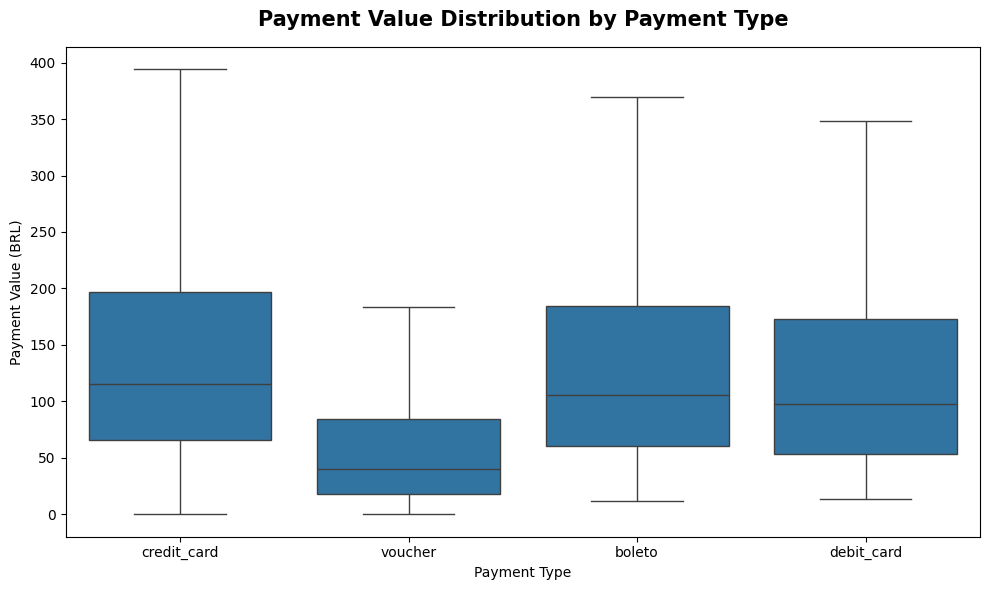

In [349]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=payment_analysis,
    x="payment_type",
    y="payment_value",
    showfliers = False
)

plt.title(
    "Payment Value Distribution by Payment Type",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Payment Type")
plt.ylabel("Payment Value (BRL)")

plt.tight_layout()

plt.savefig(
    "../images/payment_value_by_payment_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Final Interpretation

The box plot shows clear differences in payment-value distributions across payment methods. Credit card transactions have the highest median payment value, followed closely by boleto and debit card transactions. Voucher transactions have a substantially lower median and a narrower concentration toward lower payment values. The relatively long upper whiskers across payment methods indicate the presence of higher-value transactions.

### Final Observation

Payment values are positively skewed across the payment methods, with transaction distributions extending considerably toward higher values. Credit card transactions show the highest typical payment value, while voucher transactions are concentrated at the lower end. Boleto and debit card transactions occupy an intermediate range.

### Final Business Insights

- Credit card transactions have the highest typical transaction value, suggesting that credit cards are particularly important for higher-value purchases.

- Boleto transactions have a similar median to credit cards, indicating that this payment method also supports relatively high-value purchases.

- Voucher transactions have substantially lower payment values, suggesting their greater relevance for smaller purchases.

- The broad distributions indicate that transaction value varies considerably within each payment method, so payment method alone does not determine purchase value.

- The business can use these differences to design payment-specific promotions and incentives, particularly for encouraging higher-value purchases.

## 7.12.7 Payment Installments vs Payment Value

### Business Understanding

Customers may use more installments when purchasing higher-value products. This analysis examines whether payment value differs across installment counts and whether installment usage is concentrated among particular transaction values.

### Business Questions

- Does payment value tend to increase as the number of installments increases?
- Which installment counts are most commonly used?
- Do higher-value transactions tend to involve more installments?
- Is there a noticeable difference in payment value between one-time and installment purchases?

### Variables

| Variable               | Type                 | Role                 |
| ---------------------- | -------------------- | -------------------- |
| `payment_installments` | Discrete Numerical   | Independent Variable |
| `payment_value`        | Continuous Numerical | Dependent Variable   |



### Check Missing Values

In [350]:
final_dataset[
    ["payment_installments", "payment_value"]
].isna().sum()

payment_installments    3
payment_value           3
dtype: int64

In [352]:
# Investigate Missing Values

missing_installments = final_dataset[
    final_dataset["payment_installments"].isna() |
    final_dataset["payment_value"].isna()
]

missing_installments[
    ["order_id", "payment_type", "payment_installments",
     "payment_value", "order_status"]
]

,order_id,payment_type,payment_installments,payment_value,order_status
36864,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN,NaN,delivered
36865,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN,NaN,delivered
36866,bfbd0f9bdef84302105ad712db648a6c,NaN,NaN,NaN,delivered


In [353]:
missing_installments["order_status"].value_counts()

order_status
delivered    3
Name: count, dtype: int64

#### Investigation of Missing Values:

Three records were found with missing payment_installments and payment_value. All three records belong to the same order_id and have a delivered order status. Since the actual payment amount and installment count cannot be reliably inferred, these records were excluded from the installment-payment analysis rather than imputed. As they represent a single order, their exclusion is unlikely to materially affect the overall analysis.

In [356]:
installment_analysis["payment_installments"].value_counts().sort_index()

payment_installments
0.0         3
1.0     59446
2.0     13838
3.0     11889
4.0      8072
5.0      6097
6.0      4674
7.0      1848
8.0      5120
9.0       739
10.0     6976
11.0       26
12.0      168
13.0       19
14.0       16
15.0       93
16.0        7
17.0        8
18.0       38
20.0       21
21.0        6
22.0        1
23.0        1
24.0       34
Name: count, dtype: int64

In [362]:
final_dataset[
    final_dataset["payment_installments"] == 0
][
    ["order_id", "payment_type", "payment_value",
     "payment_installments", "order_status"]
]

,order_id,payment_type,payment_value,payment_installments,order_status
76229,744bade1fcf9ff3f31d860ace076d422,credit_card,58.69,0.0,delivered
79377,1a57108394169c0b47d8f876acc9ba2d,credit_card,129.94,0.0,delivered
79378,1a57108394169c0b47d8f876acc9ba2d,credit_card,129.94,0.0,delivered


#### Investigation of Zero Installments

Three records were identified with payment_installments = 0. All three transactions were made using credit cards and had a delivered order status. Since a zero-installment value is not meaningful for installment-based payment analysis, these records were treated as anomalous values rather than valid installment categories. In addition, one order appears twice with identical payment information. Therefore, these three records were excluded from the installment analysis.

### Data Preparation

Records with missing payment information and anomalous zero-installment values were excluded. The resulting dataset contains valid payment transactions with installment counts ranging from 1 to 24.

In [365]:
# Keep only valid installment transactions
installment_analysis = final_dataset[
    (final_dataset["payment_installments"] > 0) &
    (final_dataset["payment_value"].notna())
][
    ["payment_installments", "payment_value"]
]

installment_analysis.head()

,payment_installments,payment_value
0,1.0,18.12
1,1.0,2.00
2,1.0,18.59
3,1.0,141.46
4,3.0,179.12


### Descriptive Statistics

In [367]:
installment_summary = (
    installment_analysis
    .groupby("payment_installments")["payment_value"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_index()
)

installment_summary

,count,mean,median,min,max
payment_installments,,,,,
1.0,59446,132.483541,79.140,0.00,13664.08
2.0,13838,134.547213,113.850,20.03,2442.82
3.0,11889,154.102631,119.340,30.00,3256.14
4.0,8072,178.730047,127.005,40.00,3126.50
5.0,6097,197.376475,134.760,49.99,4809.44
6.0,4674,233.746996,147.150,59.99,2828.42
7.0,1848,193.551769,141.480,69.97,2094.44
8.0,5120,309.554754,217.700,37.58,6929.31
9.0,739,207.404100,99.940,90.11,2116.01


In [ ]:
# Most commonly used installment options
installment_analysis["payment_installments"].value_counts().sort_values(
    ascending=False
).head(10)

payment_installments
1.0     59446
2.0     13838
3.0     11889
4.0      8072
10.0     6976
5.0      6097
8.0      5120
6.0      4674
7.0      1848
9.0       739
Name: count, dtype: int64

#### Business Insights

- **Installment financing is associated with higher-value purchases**. Customers making larger purchases appear more likely to use a greater number of installments.

- **One-time payment remains the dominant customer preference**, suggesting that many customers either make relatively smaller purchases or prefer to pay immediately.

- **Installment options can support high-value purchases** by allowing customers to spread payments over time, potentially making expensive products more affordable.

- **The 8–10 installment range is particularly interesting** because transaction values are noticeably higher while transaction volumes are still substantial compared with very high installment counts.

- **Very high installment plans should be evaluated carefully**. Although their median payment values are high, some categories have very few observations, so they should not be used alone to make strategic conclusions.

#### Final Business Conclusion

The analysis indicates a positive association between installment count and payment value: higher-value transactions generally tend to use more installments. However, most transactions use lower installment counts, especially one installment. This suggests that installment financing plays an important role in supporting higher-value purchases, while one-time payment remains the dominant payment behavior.

### Visualization

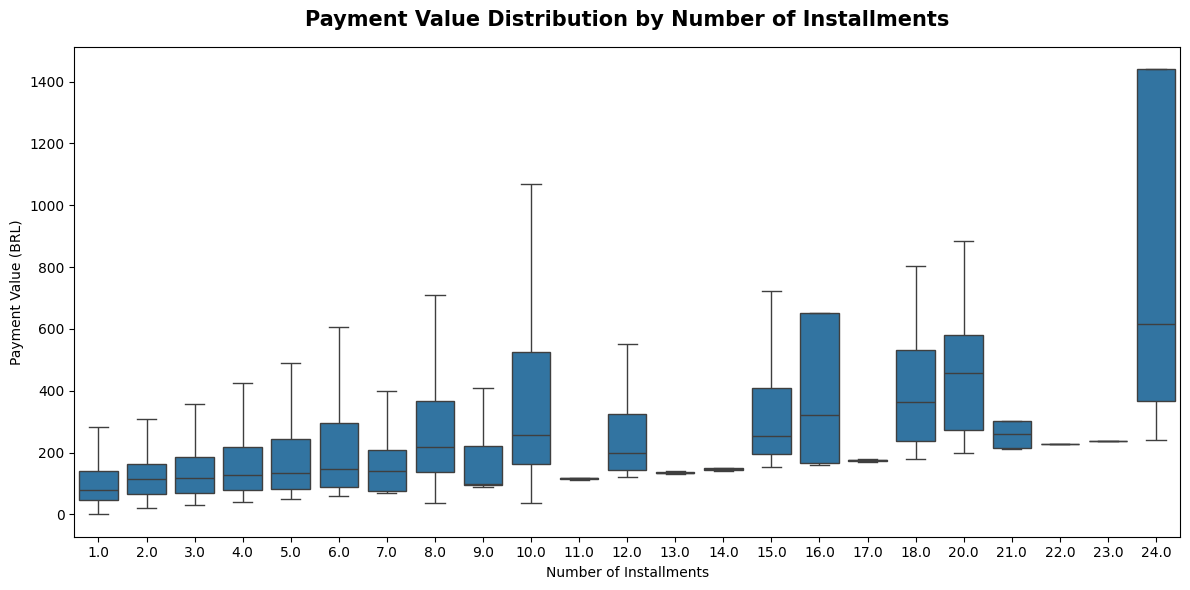

In [369]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=installment_analysis,
    x="payment_installments",
    y="payment_value",
    showfliers=False
)

plt.title(
    "Payment Value Distribution by Number of Installments",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Installments")
plt.ylabel("Payment Value (BRL)")

plt.tight_layout()

plt.savefig(
    "../images/payment_value_by_installments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The box plot indicates that payment value generally increases with the number of installments. Transactions using higher installment counts tend to have higher median payment values and wider payment-value distributions. However, the relationship is not strictly linear, and some high-installment groups have relatively few transactions, so their results should be interpreted with caution.

### Observation

Most transactions are concentrated in lower installment counts, particularly 1–6 installments. At the same time, higher installment plans tend to be associated with higher payment values. The increase becomes more noticeable from around 8–10 installments onward. Very high installment counts have considerably fewer observations, despite showing relatively high payment values.

### Business Insights

- Higher-value purchases tend to be associated with more installments, suggesting that installment financing is commonly used for expensive purchases.

- One-installment payments dominate overall transaction volume, indicating that immediate payment remains the most common behavior.

- Installment financing may help customers afford higher-value purchases by spreading the payment burden.

- The 8–10 installment range is particularly relevant because it combines relatively high payment values with substantial transaction volumes.

- Very high installment options such as 20–24 installments should be treated cautiously because their transaction counts are much smaller.

- From a business perspective, offering flexible installment options can be useful for increasing accessibility to higher-value products, but the company should balance this against financing costs and customer repayment risk.

## 7.12.8 Review Score vs Delivery Time

### Business Understanding

Delivery time is an important part of the customer experience. Longer delivery times may lead to customer dissatisfaction and potentially lower review scores.

This analysis examines whether there is an observable relationship between delivery time and customer review scores.

### Business Questions

- Does slower delivery tend to be associated with lower customer satisfaction?
- What delivery time is typically associated with higher review scores?
- Are long delivery times more common among customers giving low ratings?
- How much does delivery time vary within each review-score group?

### Variables

| Variable        | Type                            | Role                 |
| --------------- | ------------------------------- | -------------------- |
| `delivery_days` | Numerical (Continuous/Discrete) | Independent Variable |
| `review_score`  | Ordinal Numerical               | Dependent Variable   |

- `delivery_days` measures how long the customer waited for the order.
- `review_score` represents customer satisfaction on a 1–5 scale.

### Data Preparation

In [370]:
# Create a new feature representing the number of days between order purchase and customer delivery.

final_dataset["delivery_days"] = (
    final_dataset["order_delivered_customer_date"] -
    final_dataset["order_purchase_timestamp"]
).dt.days

In [371]:
# Check the new variable

final_dataset["delivery_days"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [373]:
# Also check for missing values:

final_dataset[
    ["delivery_days", "review_score", "order_delivered_customer_date" ]
].isna().sum()

delivery_days                    3421
review_score                      997
order_delivered_customer_date    3421
dtype: int64

Orders that have not been delivered will have no order_delivered_customer_date, so their delivery_days will be missing.

For this analysis, we should use only records where both delivery time and review score are available.

In [374]:
delivery_analysis = final_dataset[
    ["delivery_days", "review_score"]
].dropna()

### Data Validation

In [375]:
# Before visualization, check for unusual delivery values:

delivery_analysis["delivery_days"].describe()

count    114861.000000
mean         11.980472
std           9.373654
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         208.000000
Name: delivery_days, dtype: float64

In [378]:
# Check for impossible negative values:

(delivery_analysis["delivery_days"] < 0).sum()

np.int64(0)

In [379]:
# Check for 0 delivery days:

(delivery_analysis["delivery_days"] == 0).sum()

np.int64(19)

*Zero delivery days represent orders delivered within less than one full day according to the .dt.days calculation and are therefore not necessarily erroneous. Negative delivery times, if present, would indicate potential data-quality issues and should be investigated separately.*

### Descriptive Statistics

In [380]:
delivery_summary = (
    delivery_analysis
    .groupby("review_score")["delivery_days"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_index()
)

delivery_summary

,count,mean,median,min,max
review_score,,,,,
1.0,13121,19.099992,14.0,0.0,195.0
2.0,3899,15.381893,12.0,1.0,208.0
3.0,9650,13.552435,11.0,0.0,188.0
4.0,22150,11.778330,10.0,0.0,194.0
5.0,66041,10.203253,9.0,0.0,187.0


### Visualization

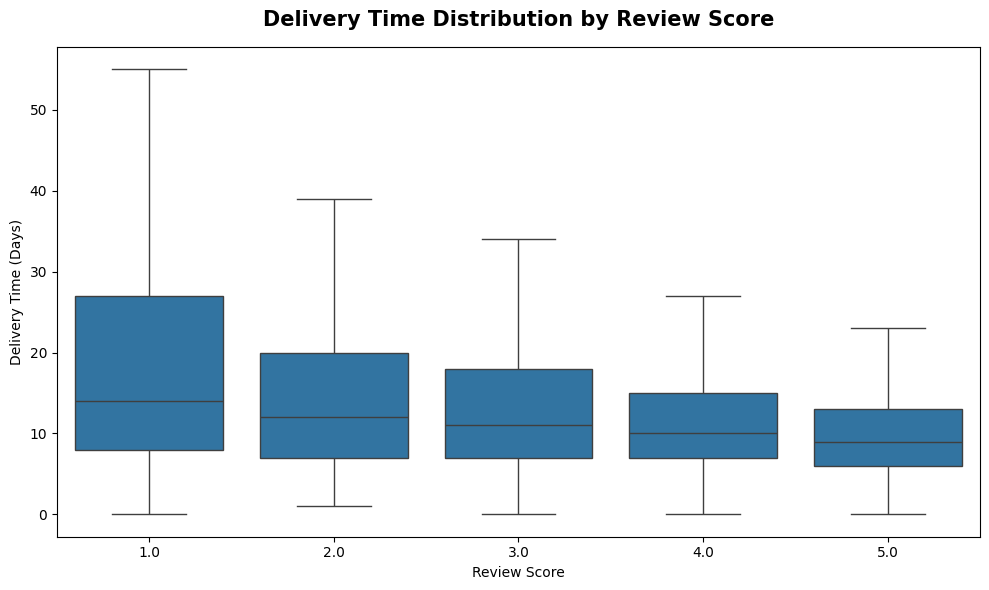

In [381]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=delivery_analysis,
    x="review_score",
    y="delivery_days",
    showfliers=False
)

plt.title(
    "Delivery Time Distribution by Review Score",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Review Score")
plt.ylabel("Delivery Time (Days)")

plt.tight_layout()

plt.savefig(
    "../images/delivery_time_by_review_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The box plot shows that delivery time generally decreases as the review score increases.

- 1-star reviews have the highest median delivery time, around 14 days, and the widest distribution.
- 2-star reviews have a median of around 12 days.
- 3-star reviews have a median of around 11 days.
- 4-star reviews have a median of around 10 days.
- 5-star reviews have the lowest median delivery time, around 9 days.

The 1-star group also has a considerably higher upper range, indicating that some poorly rated orders experienced substantially longer delivery times.

### Observation

The box plot shows a clear downward trend in delivery time as review scores increase. Lower-rated orders tend to have longer delivery times, while higher-rated orders generally arrive faster. The 1-star group has the greatest variability, whereas 4- and 5-star reviews show more concentrated delivery times.

### Business Insights

- Delivery speed is closely associated with customer satisfaction.
- Orders taking considerably longer to arrive are more likely to receive lower review scores.
- The business should monitor delayed orders, particularly those exceeding the normal delivery range.
- Sellers and logistics partners with consistently long delivery times could be identified for performance improvement.
- Improving delivery reliability—not just reducing average delivery time—could help improve customer experience.

### Final Business Conclusion

The analysis indicates a negative association between delivery time and customer satisfaction. Faster deliveries are generally associated with higher review scores, while longer and more variable delivery times are associated with lower ratings. Therefore, improving delivery speed and consistency should be an important priority for enhancing customer satisfaction.

## 7.13 Multivariate Analysis

The purpose is to examine three or more variables together and discover relationships that aren't visible when looking at only two variables.

## 7.13.1 Payment Value vs Review Score vs Payment Type

### Business Understanding

Payment value and customer satisfaction may vary across different payment methods. Analyzing payment value, review score, and payment type together can help determine whether spending patterns and customer satisfaction differ depending on the payment method used.

### Business Questions

- Does payment value differ across review scores?

- Does this relationship vary by payment method?

- Which payment methods are associated with higher-value purchases?

- Are certain payment methods more common among highly rated or poorly rated orders?

### Variables

| Variable        | Type                       | Role                 |
| --------------- | -------------------------- | -------------------- |
| `payment_value` | Continuous Numerical       | Dependent Variable   |
| `review_score`  | Discrete/Ordinal Numerical | Independent Variable |
| `payment_type`  | Categorical                | Grouping Variable    |


### Check Missing Values

In [383]:
final_dataset[
    ["payment_value", "review_score", "payment_type"]
].isna().sum()

payment_value      3
review_score     997
payment_type       3
dtype: int64

Based on your earlier analysis, there are 3 missing records in the payment-related fields. These records have the same `order_id` and `order_status` = delivered, so they appear to represent one order with multiple payment rows.

### Data Preparation

In [387]:
payment_review_analysis = final_dataset.dropna(
    subset=["payment_value", "review_score", "payment_type"]
)[
    ["payment_value", "review_score", "payment_type"]
]

payment_review_analysis = payment_review_analysis[
    payment_review_analysis["payment_type"] != "not_defined"
]

In [388]:
payment_review_analysis.shape

(118140, 3)

In [389]:
payment_review_analysis["payment_type"].value_counts()

payment_type
credit_card    87026
boleto         23002
voucher         6413
debit_card      1699
Name: count, dtype: int64

### Descriptive Statistics

In [390]:
payment_review_summary = (
    payment_review_analysis
    .groupby(["review_score", "payment_type"])["payment_value"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_index()
)

payment_review_summary

count        mean   median    min       max
review_score payment_type                                             
1.0          boleto         3019  273.892282  136.440  15.38   7274.88
             credit_card   11353  232.372339  141.500   0.07  13664.08
             debit_card      182  164.126923  102.815  20.61   2404.72
             voucher         869   89.789862   47.690   0.00   3184.34
2.0          boleto          777  209.572111  116.590  20.38   2794.50
             credit_card    3034  199.162221  129.590   0.27   3360.66
             debit_card       54  139.575370  107.065  20.82   1442.79
             voucher         297   72.823064   40.000   0.17   1302.42
3.0          boleto         1992  163.117339  102.840  13.78   2938.17
             credit_card    7219  177.590790  114.840   0.39   3242.84
             debit_card      127  142.451969   82.970  20.73   1562.57
             voucher         555   64.075261   42.110   0.14   1400.33
4.0          boleto         4426  167.102948  102.145  12.28   3979.55
             credit_card   16406  169.867353  110.550   0.03   4764.34
             debit_card      306  154.895784   92.125  13.38   4163.51
             voucher        1181   63.191592   37.940   0.00   1839.05
5.0          boleto        12788  157.528765  100.865  11.62   6726.66
             credit_card   49014  168.929278  111.210   0.01   6929.31
             debit_card     1030  149.435010   98.545  14.89   4445.50
             voucher        3511   62.136952   39.420   0.00   1522.42

In [393]:
payment_review_median = (
    payment_review_analysis
    .groupby(["review_score", "payment_type"])["payment_value"]
    .median()
    .unstack()
)

payment_review_median


payment_type,boleto,credit_card,debit_card,voucher
review_score,,,,
1.0,136.440,141.50,102.815,47.69
2.0,116.590,129.59,107.065,40.00
3.0,102.840,114.84,82.970,42.11
4.0,102.145,110.55,92.125,37.94
5.0,100.865,111.21,98.545,39.42


#### Interpretation

1. Credit Card Has the Highest Median Payment Value

For every review score, **credit-card transactions have the highest median payment value**.

For example:

- 1-star → **BRL 141.50**
- 3-star → **BRL 114.84**
- 5-star → **BRL 111.21**

This suggests that credit cards are associated with relatively higher-value purchases across all satisfaction levels.

2. Vouchers Have the Lowest Median Payment Value

Voucher transactions consistently have the lowest median payment values:

- 1-star → **BRL 47.69**
- 2-star → **BRL 40.00**
- 3-star → **BRL 42.11**
- 4-star → **BRL 37.94**
- 5-star → **BRL 39.42**

This supports the observation that **vouchers are primarily associated with lower-value transactions**.

3. Payment Value Tends to Decrease as Review Score Increases

This pattern is particularly noticeable for **credit cards and boleto**.

For credit cards:

→ 1-star: **BRL 141.50 → 5-star: BRL 111.21**

For boleto:

→ 1-star: **BRL 136.44 → 5-star: BRL 100.87**

Therefore, in this dataset, **lower-rated purchases tend to have higher median payment values**.

**Note:** This indicates an association between payment value and review score. It does **not** establish that higher payment value causes lower customer ratings.

4. Debit Card Shows a Less Consistent Pattern

Debit-card median payment values fluctuate across review scores:

**BRL 102.82 → 107.07 → 82.97 → 92.13 → 98.55**

Therefore, the relationship between payment value and review score is **less consistent for debit-card transactions**.

#### Observation

Median payment value varies across both payment methods and review scores. Credit-card transactions consistently have the highest median payment values, while voucher transactions have the lowest. For credit-card and boleto transactions, median payment value generally decreases as review score increases, indicating that higher-value purchases are relatively more common among lower-rated transactions. Debit-card transactions show a less consistent pattern across review scores.

#### Business Insights

- **Credit cards are associated with the highest-value purchases** across all review scores, making them an important payment channel for higher-value transactions.

- **Voucher transactions have substantially lower median payment values**, suggesting that vouchers are primarily used for smaller purchases.

- **Higher median payment values among lower-rated credit-card and boleto transactions** may indicate that dissatisfaction can be particularly important for higher-value purchases.

- The business should **prioritize customer experience for high-value transactions**, as negative experiences associated with expensive purchases may have a greater impact on customer perception and retention.

- **Payment method should be considered when analyzing customer satisfaction**, because spending patterns differ significantly across payment types.

### Visualization

A grouped box plot was used to compare **payment value** across different **review scores**, with **payment type** represented using separate groups.

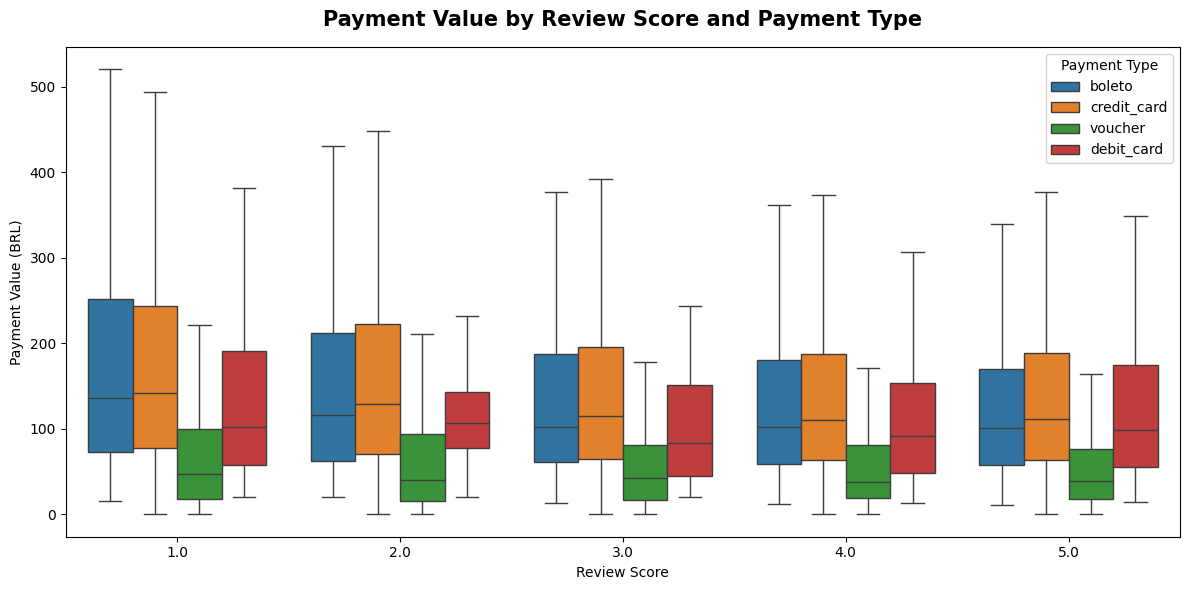

In [395]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=payment_review_analysis,
    x="review_score",
    y="payment_value",
    hue="payment_type",
    showfliers=False
)

plt.title(
    "Payment Value by Review Score and Payment Type",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Review Score")
plt.ylabel("Payment Value (BRL)")
plt.legend(title="Payment Type")

plt.tight_layout()

plt.savefig(
    "../images/payment_value_review_score_payment_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

1. Credit-card and boleto transactions generally have higher payment values

Across most review scores, the median payment values for **credit card** and **boleto** are higher than those for **voucher** transactions.

2. Voucher transactions have consistently lower payment values

Voucher transactions remain at the lower end across all review scores. This indicates that vouchers are mainly associated with relatively smaller-value transactions.

3. Debit-card transactions show intermediate payment values

Debit-card transactions generally have higher payment values than vouchers but lower values than credit-card and boleto transactions.

4. Payment value varies across review scores

For **credit-card** and **boleto** transactions, median payment values appear somewhat higher for lower review scores and generally decrease toward the higher review scores.

5. Payment values show substantial variability

The box plots and whiskers show a wide spread of payment values within each payment method, particularly for credit-card and boleto transactions. This indicates that customers using the same payment method can still have very different purchase values.

6. Payment-method differences are clearly visible

The differences between payment methods are noticeable within each review-score group, particularly between **voucher** transactions and **credit-card/boleto** transactions.


### Observation

Payment value varies considerably across both review scores and payment methods. Credit-card and boleto transactions generally show higher median payment values, while voucher transactions consistently have the lowest payment values. Debit-card transactions generally fall between these groups. The chart also suggests that higher payment values are relatively more common among lower review scores for credit-card and boleto transactions. However, the considerable overlap and variation within groups indicate that payment method and review score alone do not completely explain payment value.


### Business Insights

- **Credit cards and boleto are important payment channels for higher-value purchases**, so these channels should be considered when analyzing and targeting high-value customers.

- **Voucher transactions are predominantly associated with lower-value purchases**, suggesting that promotional strategies could be used to encourage voucher users to increase their basket size.

- **Higher-value purchases appear relatively more common among lower-rated transactions**, particularly for credit-card and boleto payments. This suggests that dissatisfaction with high-value purchases may represent an important customer-experience risk.

- **Customer satisfaction should be closely monitored for high-value transactions**, because a negative experience on an expensive purchase may have a greater impact on customer perception and future purchasing behavior.

- **Payment type should be considered when analyzing customer satisfaction**, because spending patterns differ substantially across payment methods.

**Important:** The chart shows an **association** between payment value, review score, and payment type. It does **not establish causation**. Therefore, we cannot conclude that a higher payment value or a particular payment method causes lower or higher review scores.

## 7.13.2 Delivery Time vs Review Score vs Seller State

### Business Understanding

Delivery performance can vary depending on the seller's geographic location. Longer delivery times may affect customer satisfaction, and this relationship may differ across seller states.

This analysis extends the previous **Delivery Time vs Review Score** analysis by adding **Seller State** as a third variable.

### Business Questions

- Does delivery time vary across seller states?
- Do seller states with longer delivery times tend to receive lower review scores?
- Does the relationship between delivery time and customer satisfaction differ geographically?
- Which seller states have relatively fast delivery and high customer satisfaction?
- Which seller states may require improvement in delivery performance?

### Variables

| Variable | Type | Role |
|---|---|---|
| `delivery_days` | Numerical (Continuous) | Independent Variable |
| `review_score` | Ordinal Numerical | Dependent Variable |
| `seller_state` | Categorical | Grouping Variable |

### Data Preparation

First, create an analysis dataset containing only the required variables and remove records with missing values.

In [396]:
delivery_state_analysis = final_dataset.dropna(
    subset=["delivery_days", "review_score", "seller_state"]
)[
    ["delivery_days", "review_score", "seller_state"]
]

delivery_state_analysis.shape

(114861, 3)

In [398]:
# Check the number of seller states

delivery_state_analysis["seller_state"].nunique()

22

In [399]:
# Check seller-state distribution

delivery_state_analysis["seller_state"].value_counts()

seller_state
SP    81939
MG     9004
PR     8820
RJ     4860
SC     4167
RS     2241
DF      931
BA      679
GO      536
PE      459
MA      400
ES      377
MT      146
CE       99
MS       59
RN       56
PB       42
RO       14
PI       11
SE       10
PA        8
AM        3
Name: count, dtype: int64

### Descriptive Statistics

In [402]:
# Calculate delivery-time statistics for each seller state.

delivery_state_summary = (
    delivery_state_analysis
    .groupby("seller_state")["delivery_days"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=True)
)

delivery_state_summary

,count,mean,median,min,max
seller_state,,,,,
RN,56,12.642857,7.5,1.0,50.0
RJ,4860,11.439918,9.0,0.0,142.0
RS,2241,11.089246,9.0,1.0,189.0
PB,42,11.357143,9.0,4.0,31.0
SP,81939,11.800888,9.0,0.0,208.0
MG,9004,12.290871,10.0,0.0,195.0
DF,931,12.157895,10.0,1.0,79.0
GO,536,12.311567,10.0,1.0,62.0
PR,8820,12.859524,11.0,1.0,168.0


In [403]:
# Calculate the average review score for each seller state.

state_review_summary = (
    delivery_state_analysis
    .groupby("seller_state")["review_score"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

state_review_summary

,count,mean,median
seller_state,,,
MS,59,4.559322,5.0
PA,8,4.500000,5.0
PI,11,4.363636,5.0
GO,536,4.317164,5.0
CE,99,4.282828,5.0
RN,56,4.267857,5.0
RS,2241,4.244534,5.0
MT,146,4.198630,5.0
RJ,4860,4.168313,5.0


In [407]:
# Compare delivery time and review score by seller state

state_comparison = (
    delivery_state_analysis
    .groupby("seller_state")
    .agg(
        median_delivery_days=("delivery_days", "median"),
        average_review_score=("review_score", "mean"),
        order_count=("review_score", "count")
    )
    .reset_index()
    .sort_values("median_delivery_days")
)

state_comparison

,seller_state,median_delivery_days,average_review_score,order_count
16,RN,7.5,4.267857,56
15,RJ,9.0,4.168313,4860
18,RS,9.0,4.244534,2241
11,PB,9.0,3.952381,42
21,SP,9.0,4.050550,81939
7,MG,10.0,4.161484,9004
3,DF,10.0,4.087003,931
5,GO,10.0,4.317164,536
14,PR,11.0,4.131066,8820
12,PE,11.0,4.135076,459


#### Interpretation

1. Delivery time varies across seller states

The median delivery time differs noticeably across seller states.

- **RN** has the lowest median delivery time at **7.5 days**.
- **RJ, RS, PB, and SP** have a median delivery time of approximately **9 days**.
- **MG, DF, and GO** have a median of approximately **10 days**.
- **PR, PE, ES, BA, and SC** have a median of approximately **11 days**.
- **MA** has a median delivery time of **15 days**.
- **RO** has a median of **16 days**.
- **AM** has the highest median delivery time at **29 days**.

This indicates that delivery performance differs substantially across geographic regions.

2. High-volume states generally have moderate delivery times

The largest seller states by number of orders include:

- **SP:** 81,939 orders
- **MG:** 9,004 orders
- **PR:** 8,820 orders
- **RJ:** 4,860 orders
- **SC:** 4,167 orders
- **RS:** 2,241 orders

Among these high-volume states, median delivery time ranges from approximately **9 to 11 days**.

This suggests that the major seller markets generally maintain relatively consistent delivery performance.

3. Some states show considerably longer delivery times

Several states have substantially higher median delivery times:

- **MA:** 15 days
- **RO:** 16 days
- **AM:** 29 days

These states may face geographic or logistical challenges that contribute to longer delivery times.

However, these results should be interpreted carefully because their sample sizes are much smaller than states such as SP and MG.

4. Review scores are generally high across most states

The average review score is above **4.0** for most seller states.

Examples include:

- **MS:** 4.56
- **PA:** 4.50
- **GO:** 4.32
- **RS:** 4.24
- **RJ:** 4.17
- **MG:** 4.16
- **SP:** 4.06

This indicates that customers generally provide positive ratings across the dataset, even though delivery times differ between states.

5. Some low-rated states have very small sample sizes

**AM** has an average review score of only **2.33**, but it contains only **3 orders**.

Similarly:

- **RO:** 14 orders, average score 3.86
- **SE:** 10 orders, average score 3.90
- **PI:** 11 orders, average score 4.36
- **PA:** 8 orders, average score 4.50

Therefore, the lower average review scores in some states should not be treated as representative of the entire region.

6. Longer delivery time does not automatically mean lower review scores

The results do not show a simple one-to-one relationship between delivery time and review score.

For example:

- **MS** has a median delivery time of 12 days but a high average review score of **4.56**.
- **PA** has a median delivery time of 12.5 days and an average review score of **4.50**.
- **AM** has a very long median delivery time of 29 days and a much lower average review score of **2.33**.

This suggests that delivery time may be associated with customer satisfaction in some regions, but other factors may also influence review scores.


#### Observation

Delivery performance varies considerably across seller states, with median delivery times ranging from approximately **7.5 days to 29 days**. High-volume states such as SP, MG, PR, RJ, SC, and RS generally show moderate median delivery times between **9 and 11 days**. Some states, particularly AM, RO, and MA, show considerably longer delivery times. However, the relationship between delivery time and customer satisfaction is not consistent across all states. Most states have high average review scores, while some apparently low-performing states have very small sample sizes and therefore require cautious interpretation.

#### Business Insights

- **Geographic location can influence delivery performance**, as median delivery time varies significantly across seller states.

- **High-volume states should be used as operational benchmarks**, since states such as SP, MG, PR, RJ, SC, and RS have large numbers of orders and relatively moderate delivery times.

- **States with consistently longer delivery times should be investigated**, particularly AM, RO, and MA, to identify potential logistics, transportation, or fulfillment challenges.

- **Customer satisfaction should not be evaluated using delivery time alone.** The analysis shows that some states maintain high review scores despite relatively longer delivery times.

- **Low-volume states require additional data before making business decisions.** For example, AM has an average review score of 2.33, but this is based on only 3 orders.

- **The business can prioritize logistics improvements geographically**, focusing first on regions with both relatively long delivery times and sufficient order volume to support reliable conclusions.

**Important:** This analysis identifies patterns and associations between seller state, delivery time, and review score. It does not establish that longer delivery times directly cause lower review scores.

### Visualization

In [410]:
# Select the top 10 seller states by order volume

top_states = (
    state_comparison
    .sort_values("order_count", ascending=False)
    .head(10)
)

top_states

,seller_state,median_delivery_days,average_review_score,order_count
21,SP,9.0,4.050550,81939
7,MG,10.0,4.161484,9004
14,PR,11.0,4.131066,8820
15,RJ,9.0,4.168313,4860
19,SC,11.0,4.137029,4167
18,RS,9.0,4.244534,2241
3,DF,10.0,4.087003,931
1,BA,11.0,4.153166,679
5,GO,10.0,4.317164,536
12,PE,11.0,4.135076,459


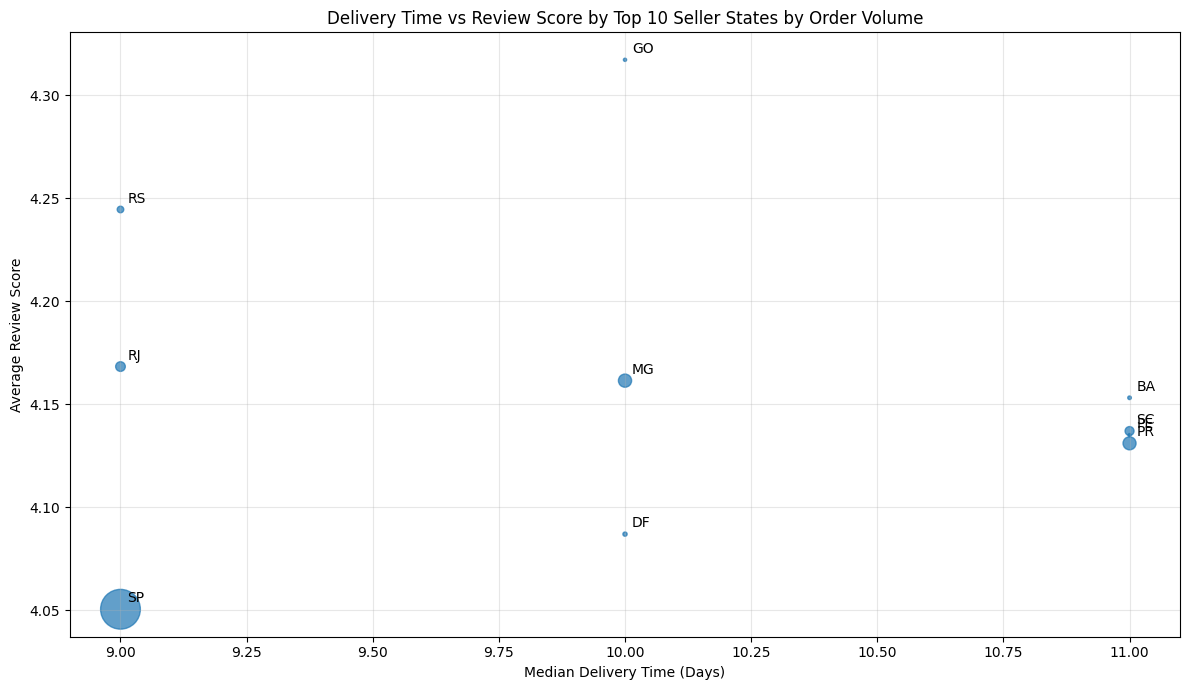

In [420]:
plt.figure(figsize=(12, 7))

plt.scatter(
    top_states["median_delivery_days"],
    top_states["average_review_score"],
    s=top_states["order_count"] / 100,
    alpha=0.7
)

for _, row in top_states.iterrows():
    plt.annotate(
        row["seller_state"],
        (row["median_delivery_days"], row["average_review_score"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Median Delivery Time (Days)")
plt.ylabel("Average Review Score")
plt.title("Delivery Time vs Review Score by Top 10 Seller States by Order Volume")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/delivery_time_vs_review_score_seller_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

1. Seller states show different delivery-time patterns

The top seller states have median delivery times ranging from approximately **9 to 11 days**.

- **SP, RJ, and RS** have a median delivery time of around **9 days**.
- **MG and DF** have a median delivery time of around **10 days**.
- **BA, SC, and PR** have a median delivery time of around **11 days**.

This indicates that delivery performance varies across seller locations.

2. Faster delivery does not always correspond to higher review scores

The relationship between delivery time and review score is not perfectly linear.

For example:

- **RS** has a median delivery time of about **9 days** and a high average review score of approximately **4.24**.
- **RJ** also has about **9 days** of delivery time with an average review score of approximately **4.17**.
- **GO** has a longer median delivery time of about **10 days**, but has the highest average review score at approximately **4.32**.
- **SP** has about **9 days** of delivery time but a lower average review score of approximately **4.05**.

Therefore, delivery time alone does not completely explain differences in customer satisfaction.

3. SP has the largest order volume

The bubble size represents order count.

**SP has by far the largest bubble**, indicating that it has substantially more orders than the other top seller states.

This makes SP particularly important from a business perspective because even a small improvement in customer experience in this state could affect a large number of customers.

4. Some states combine relatively longer delivery with good satisfaction

States such as **BA, SC, and PR** have median delivery times of approximately **11 days**, but their average review scores remain above **4.1**.

This suggests that customers may tolerate somewhat longer delivery times when other aspects of the purchasing experience are satisfactory.


### Observation

Delivery time and customer satisfaction vary across seller states, but the relationship is not strictly linear. RS and RJ achieve relatively high review scores with approximately 9 days of median delivery time, while GO records the highest average review score despite having a median delivery time of around 10 days. States such as BA, SC, and PR have longer median delivery times of approximately 11 days but still maintain average review scores above 4.1. SP has the largest order volume and therefore represents the most significant state from a business-impact perspective.


### Business Insights

- **SP should be a priority for operational improvement** because it has the highest order volume. Even modest improvements in delivery or customer experience could affect a large number of customers.

- **Reducing delivery time alone may not guarantee higher customer satisfaction**, as GO achieves the highest average review score despite having a longer median delivery time than RS and RJ.

- **Seller-state performance should be evaluated using multiple factors**, including delivery time, review scores, and order volume rather than relying on delivery time alone.

- **States with approximately 11-day median delivery times still maintain relatively high review scores**, suggesting that customers may value other aspects of the shopping experience in addition to delivery speed.

- **Low-volume states should be interpreted cautiously**, because their average review scores may be less reliable due to smaller sample sizes.

- The analysis suggests that **geographic location is associated with differences in delivery performance and customer satisfaction**, making seller location an important factor for logistics and customer-experience analysis.

**Note:** This visualization shows an association between seller location, delivery time, and review score. It does **not** establish that delivery time causes changes in customer satisfaction.

## 7.13.3 Payment Value vs Installments vs Payment Type

### Business Understanding

Customers may use installment payments when making higher-value purchases.

However, installment behavior may differ depending on the payment method. 
Analyzing payment value, installment count, and payment type together can 
help identify whether higher-value purchases are associated with more 
installments and whether this relationship varies across payment methods.

### Business Questions

- Do higher-value purchases generally involve more installments?
- Does the relationship between payment value and installment count differ by payment type?
- Which payment methods are associated with higher installment counts?
- Are credit-card transactions more likely to involve multiple installments?

### Variables

| Variable | Type | Role |
|---|---|---|
| `payment_value` | Continuous Numerical | Dependent Variable |
| `payment_installments` | Discrete Numerical | Independent Variable |
| `payment_type` | Categorical | Grouping Variable |

### Data Preparation

For this analysis:

- Transactions with `payment_installments = 0` are excluded because they do not represent a valid installment option.
- Transactions with `payment_type = "not_defined"` are excluded because the payment method is unknown.
- Rows with missing values in `payment_value`, `payment_installments`, or `payment_type` are also excluded.

This ensures that the analysis focuses only on valid payment methods and meaningful installment counts.

In [422]:
installment_payment_analysis = final_dataset.dropna(
    subset=[
        "payment_value",
        "payment_installments",
        "payment_type"
    ]
).copy()

installment_payment_analysis = installment_payment_analysis[
    (installment_payment_analysis["payment_installments"] > 0) &
    (installment_payment_analysis["payment_type"] != "not_defined")
]

installment_payment_analysis.shape

(119134, 39)

In [423]:
# Check if installments with 0 values are removed

installment_payment_analysis["payment_installments"].value_counts().sort_index()

payment_installments
1.0     59443
2.0     13838
3.0     11889
4.0      8072
5.0      6097
6.0      4674
7.0      1848
8.0      5120
9.0       739
10.0     6976
11.0       26
12.0      168
13.0       19
14.0       16
15.0       93
16.0        7
17.0        8
18.0       38
20.0       21
21.0        6
22.0        1
23.0        1
24.0       34
Name: count, dtype: int64

In [424]:
# Check if `not_defined` is removed

installment_payment_analysis["payment_type"].value_counts()

payment_type
credit_card    87773
boleto         23190
voucher         6465
debit_card      1706
Name: count, dtype: int64

### Descriptive Statistics

To understand how payment value varies across installment counts and payment types, 
the count, mean, median, minimum, and maximum payment values are calculated for 
each combination.

The **median** is particularly useful because payment values are right-skewed 
and may contain unusually large transactions.

In [427]:
installment_payment_summary = (
    installment_payment_analysis
    .groupby(
        ["payment_type", "payment_installments"]
    )["payment_value"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .sort_index()
)

installment_payment_summary

count        mean   median     min  \
payment_type payment_installments                                       
boleto       1.0                   23190  177.271270  105.980   11.62   
credit_card  1.0                   28082  109.372663   71.920    0.01   
             2.0                   13838  134.547213  113.850   20.03   
             3.0                   11889  154.102631  119.340   30.00   
             4.0                    8072  178.730047  127.005   40.00   
             5.0                    6097  197.376475  134.760   49.99   
             6.0                    4674  233.746996  147.150   59.99   
             7.0                    1848  193.551769  141.480   69.97   
             8.0                    5120  309.554754  217.700   37.58   
             9.0                     739  207.404100   99.940   90.11   
             10.0                   6976  431.350192  256.385   37.67   
             11.0                     26  123.983462  116.420  110.30   
             12.0                    168  321.374286  199.770  121.09   
             13.0                     19  147.724211  135.450  130.00   
             14.0                     16  166.521250  146.720  139.98   
             15.0                     93  422.741075  254.830  151.93   
             16.0                      7  395.081429  320.760  160.12   
             17.0                      8  174.602500  175.100  170.00   
             18.0                     38  493.345263  364.160  180.76   
             20.0                     21  568.072857  458.310  200.08   
             21.0                      6  258.865000  259.535  212.03   
             22.0                      1  228.710000  228.710  228.71   
             23.0                      1  236.480000  236.480  236.48   
             24.0                     34  801.737941  617.240  241.42   
debit_card   1.0                    1706  150.864531   97.535   13.38   
voucher      1.0                    6465   67.427353   40.110    0.00   

                                        max  
payment_type payment_installments            
boleto       1.0                    7274.88  
credit_card  1.0                   13664.08  
             2.0                    2442.82  
             3.0                    3256.14  
             4.0                    3126.50  
             5.0                    4809.44  
             6.0                    2828.42  
             7.0                    2094.44  
             8.0                    6929.31  
             9.0                    2116.01  
             10.0                   4950.34  
             11.0                    198.83  
             12.0                   1543.25  
             13.0                    278.00  
             14.0                    417.45  
             15.0                   2647.76  
             16.0                    651.05  
             17.0                    177.99  
             18.0                   1232.85  
             20.0                   2022.33  
             21.0                    303.02  
             22.0                    228.71  
             23.0                    236.48  
             24.0                   1440.10  
debit_card   1.0                    4445.50  
voucher      1.0                    3184.34

### Most Commonly Used Installment Options

The frequency of each installment count is examined to identify the installment 
options most commonly used by customers.

In [428]:
installment_frequency = (
    installment_payment_analysis["payment_installments"]
    .value_counts()
    .sort_values(ascending=False)
)

installment_frequency

payment_installments
1.0     59443
2.0     13838
3.0     11889
4.0      8072
10.0     6976
5.0      6097
8.0      5120
6.0      4674
7.0      1848
9.0       739
12.0      168
15.0       93
18.0       38
24.0       34
11.0       26
20.0       21
13.0       19
14.0       16
17.0        8
16.0        7
21.0        6
23.0        1
22.0        1
Name: count, dtype: int64

### Payment Type and Installment Comparison

The distribution of installment counts is also compared across payment types 
to determine which payment methods are most commonly associated with multiple 
installment payments.

In [429]:
payment_type_installment_frequency = (
    installment_payment_analysis
    .groupby(["payment_type", "payment_installments"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["payment_type", "count"],
        ascending=[True, False]
    )
)

payment_type_installment_frequency

,payment_type,payment_installments,count
0,boleto,1.0,23190
1,credit_card,1.0,28082
2,credit_card,2.0,13838
3,credit_card,3.0,11889
4,credit_card,4.0,8072
10,credit_card,10.0,6976
5,credit_card,5.0,6097
8,credit_card,8.0,5120
6,credit_card,6.0,4674
7,credit_card,7.0,1848


### Visualization

A box plot is used to examine how payment value varies with the number of
installments and whether this relationship differs across payment methods.

The **x-axis** represents the number of installments, while the **y-axis**
represents payment value in BRL.

The `hue` parameter separates the box plots by payment type, allowing us
to compare payment methods within each installment category.

This visualization helps answer the following business question:

**Do customers making higher-value purchases use more installments, and does this pattern vary by payment method?**

## 7.13.4 Product Category vs Payment Value vs Review Score

### Business Understanding

Customer spending and satisfaction may vary across product categories.

Analyzing `product_category_name_english`, `payment_value`, and
`review_score` can help identify categories that combine:

- High spending and high customer satisfaction
- High spending and low customer satisfaction
- Low spending and high customer satisfaction
- Low spending and low customer satisfaction

This analysis can help identify product categories that require greater
attention from a business perspective.

### Business Questions

- Which product categories have the highest payment values?
- Which product categories receive the highest and lowest review scores?
- Do high-value purchases tend to receive higher or lower review scores?
- Are some product categories associated with both high spending and low
  customer satisfaction?
- Which categories may require attention because of high spending combined
  with poor customer satisfaction?

### Data Preparation

The analysis requires product category, payment value, and review score.

Rows with missing values in these variables are removed to ensure that the
comparison is based on complete observations.

In [434]:
category_payment_review = final_dataset.dropna(
    subset=[
        "product_category_name_english",
        "payment_value",
        "review_score"
    ]
)[
    [
        "product_category_name_english",
        "payment_value",
        "review_score"
    ]
].copy()

category_payment_review = category_payment_review[
    category_payment_review["product_category_name_english"] != "Unknown"
]

category_payment_review.shape

(115633, 3)

### Descriptive Statistics

Descriptive statistics are calculated to understand payment value and
customer satisfaction across different product categories.

The analysis includes:

- **Order Count** – number of transactions in each product category.
- **Mean Payment Value** – average payment value.
- **Median Payment Value** – middle payment value, which is useful because
  payment values can be right-skewed.
- **Mean Review Score** – average customer review score.
- **Median Review Score** – middle review score.

These statistics help identify product categories with high spending,
high customer satisfaction, or potential areas of concern.

In [442]:
category_summary = (
    category_payment_review
    .groupby("product_category_name_english")
    .agg(
        order_count=("payment_value", "count"),
        mean_payment_value=("payment_value", "mean"),
        median_payment_value=("payment_value", "median"),
        average_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
    .sort_values("order_count", ascending=False)
)

category_summary

,order_count,mean_payment_value,median_payment_value,average_review_score,median_review_score
product_category_name_english,,,,,
bed_bath_table,11847,145.645790,107.780,3.890605,5.0
health_beauty,9944,165.556369,105.070,4.137973,5.0
sports_leisure,8942,155.511280,113.000,4.107470,5.0
furniture_decor,8743,163.240765,117.240,3.912158,5.0
computers_accessories,8105,196.497429,114.090,3.936089,5.0
...,...,...,...,...,...
la_cuisine,15,174.266000,137.300,4.133333,5.0
cds_dvds_musicals,14,85.673571,74.940,4.642857,5.0
gaming_pc,10,217.443000,171.870,3.100000,4.0


In [443]:
# To see the top 15 categories by number of transactions
category_summary.head(15)

,order_count,mean_payment_value,median_payment_value,average_review_score,median_review_score
product_category_name_english,,,,,
bed_bath_table,11847,145.645790,107.780,3.890605,5.0
health_beauty,9944,165.556369,105.070,4.137973,5.0
sports_leisure,8942,155.511280,113.000,4.107470,5.0
furniture_decor,8743,163.240765,117.240,3.912158,5.0
computers_accessories,8105,196.497429,114.090,3.936089,5.0
housewares,7331,148.916812,93.850,4.060428,5.0
watches_gifts,6161,230.592789,157.200,4.017692,5.0
telephony,4692,102.897852,46.780,3.948849,5.0
garden_tools,4558,183.141169,125.760,4.023914,5.0


In [444]:
# To identify categories with high spending and low satisfaction

high_value_low_score = category_summary[
    (category_summary["median_payment_value"] >=
     category_summary["median_payment_value"].quantile(0.75)) &
    (category_summary["average_review_score"] <=
     category_summary["average_review_score"].quantile(0.25))
].sort_values(
    "median_payment_value",
    ascending=False
)


high_value_low_score

,order_count,mean_payment_value,median_payment_value,average_review_score,median_review_score
product_category_name_english,,,,,
office_furniture,1773,364.313553,233.630,3.526791,4.0
furniture_bedroom,126,253.265317,230.750,3.841270,5.0
construction_tools_safety,198,331.549495,188.605,3.848485,5.0
gaming_pc,10,217.443000,171.870,3.100000,4.0
security_and_services,2,162.255000,162.255,2.500000,2.5
furniture_living_room,522,259.433467,158.185,3.913793,5.0


### Visualization

A box plot is used to compare payment values across product categories,
with review score represented using `hue`.

The visualization focuses on the top 15 product categories by transaction
count to keep the chart readable.

- **X-axis:** Product Category
- **Y-axis:** Payment Value (BRL)
- **Hue:** Review Score
- **Each box:** Distribution of payment values for a particular review score
  within a product category

This visualization helps identify whether high-value purchases are associated
with higher or lower customer satisfaction across different product categories.

In [445]:
top_categories = (
    category_summary
    .head(15)
    .index
)

category_payment_review_top = category_payment_review[
    category_payment_review["product_category_name_english"].isin(
        top_categories
    )
].copy()

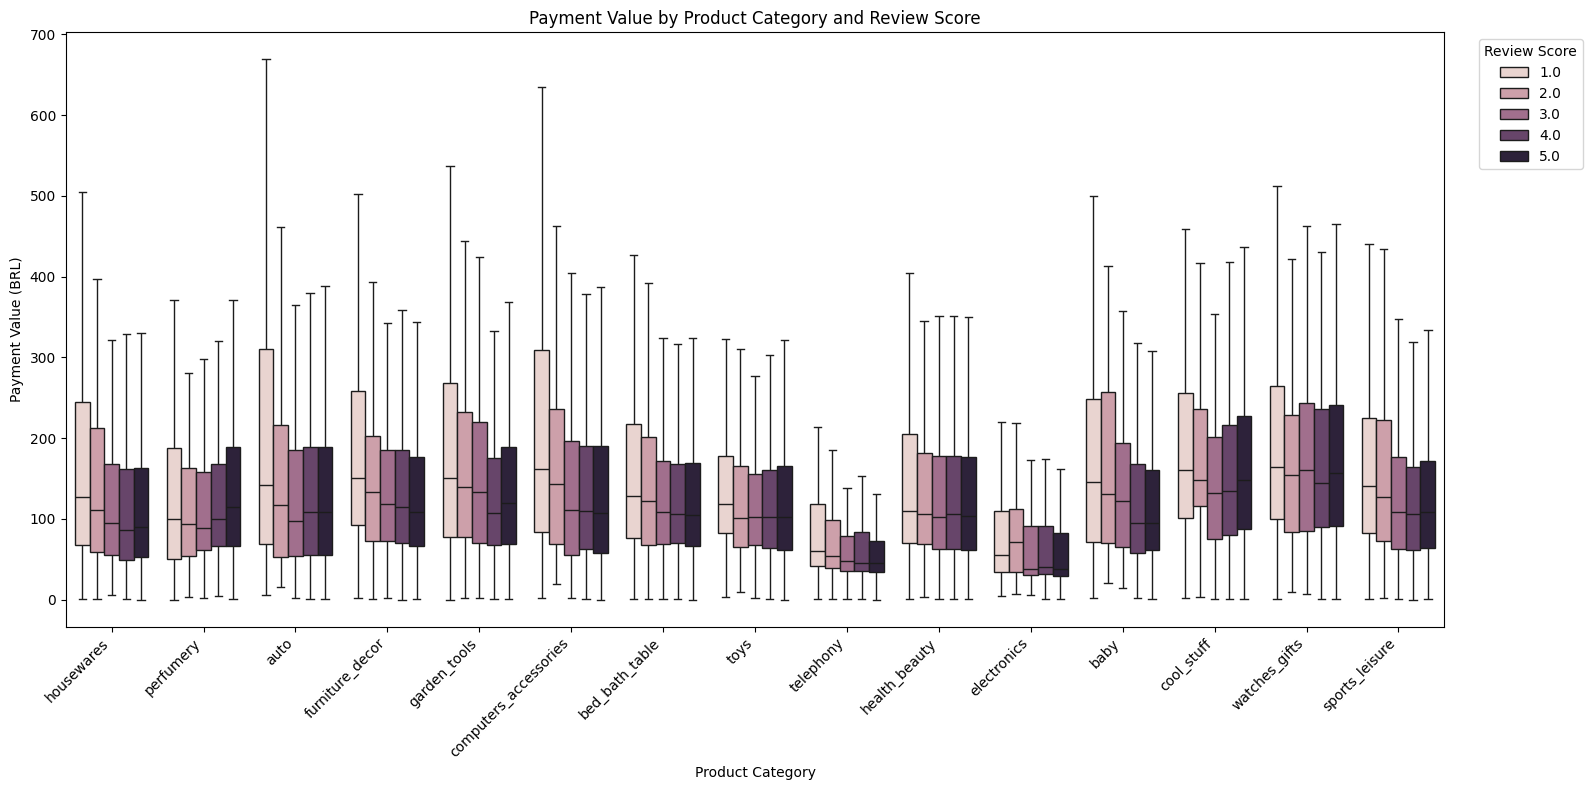

In [447]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=category_payment_review_top,
    x="product_category_name_english",
    y="payment_value",
    hue="review_score",
    showfliers=False
)

plt.xlabel("Product Category")
plt.ylabel("Payment Value (BRL)")
plt.title("Payment Value by Product Category and Review Score")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Review Score",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../images/product_category_payment_value_review_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

The box plot compares payment value across the top 15 product categories,
with customer review score represented by different colors.

The visualization shows how spending levels vary across both product
categories and customer satisfaction levels.

Several categories show higher payment-value distributions for lower review
scores, while higher review scores are often associated with relatively
lower or moderate payment values.

However, this pattern is not consistent across every category, indicating
that the relationship between payment value and customer satisfaction
depends on the product category.

## Observation

- **Computers & Accessories**, **Auto**, **Garden Tools**, and **Watches &
  Gifts** show relatively high payment-value distributions compared with
  several other categories.

- **Telephony** has the lowest payment-value distribution among the
  categories shown.

- **Computers & Accessories** has one of the widest payment-value
  distributions, with lower review scores showing particularly high
  payment values and greater variability.

- **Garden Tools** and **Auto** also show relatively high payment values
  for lower review scores.

- In several categories, the distributions for **1-star and 2-star
  reviews** extend to higher payment values than the distributions for
  4-star and 5-star reviews.

- **Health & Beauty**, **Housewares**, and **Furniture & Decor** show
  relatively broad payment-value distributions across different review
  scores.

- **Watches & Gifts** has relatively high payment values across several
  review-score groups, making it an important category to examine further.

- The presence of large upper whiskers in several categories indicates
  that some customers make unusually high-value purchases.

- Overall, the chart suggests that **higher spending does not necessarily
  correspond to higher customer satisfaction**.

## Business Insights

- High-value purchases receiving low review scores should be investigated
  because dissatisfaction associated with expensive purchases may represent
  a greater customer-retention risk.

- **Computers & Accessories**, **Auto**, **Garden Tools**, and **Watches &
  Gifts** deserve closer attention because they combine relatively high
  payment values with substantial variation in customer satisfaction.

- Categories with lower payment values but consistently strong review
  scores may represent reliable customer experiences and could provide
  useful practices for other categories.

- Product categories with high payment values and lower review scores may
  require investigation into product quality, seller performance,
  delivery experience, product expectations, or after-sales service.

- Businesses should not assume that expensive purchases automatically
  produce higher customer satisfaction. The relationship appears to vary
  across product categories.

- High-value transactions with poor reviews can be prioritized for
  customer-service analysis because improving these experiences may have a
  greater impact on customer retention.

## Conclusion

The analysis indicates that payment value and customer satisfaction are
not uniformly related across product categories.

Several high-value categories contain relatively large payment values
associated with lower review scores, suggesting potential customer
satisfaction issues in expensive purchases.

Therefore, businesses should analyze **product category, transaction
value, and customer satisfaction together** rather than evaluating
payment value or review score independently.

## 7.14 Overall EDA Findings / Summary

The Exploratory Data Analysis (EDA) provided an overall understanding of
customer behavior, sales patterns, payment behavior, product performance,
delivery performance, seller activity, and customer satisfaction in the
Brazilian E-Commerce dataset.

The major findings from the analysis are summarized below.

### 1. Sales and Payment Behavior

- The analysis showed substantial variation in payment values across
  transactions.
- Payment values are right-skewed, with a relatively small number of
  high-value transactions.
- Credit card is the dominant payment method in the dataset.
- Most credit-card transactions are completed using a relatively small
  number of installments, particularly one installment.
- Higher installment counts are less frequently used and are generally
  associated with a smaller number of transactions.
- Payment value varies considerably across different installment counts
  and payment methods.

### 2. Customer Satisfaction

- Review scores are concentrated toward the higher end of the rating
  scale, indicating that many customers reported satisfactory experiences.
- However, a meaningful proportion of orders received lower review scores.
- Customer satisfaction varies across payment methods, seller states,
  product categories, and delivery performance.
- High-value purchases do not necessarily result in higher customer
  satisfaction.

### 3. Delivery Performance

- Delivery time varies considerably across seller states.
- Some seller states show relatively shorter median delivery times,
  whereas others have longer delivery times.
- Delivery-time distributions contain large variations and extreme
  observations.
- The analysis of delivery time and review score suggests that delivery
  performance can be an important factor associated with customer
  satisfaction.
- However, delivery time alone does not completely explain differences in
  review scores.

### 4. Seller State Analysis

- Seller activity is concentrated in a limited number of Brazilian states.
- São Paulo (SP) represents the largest seller base and order volume among
  the states analyzed.
- Seller states differ in both order volume and customer satisfaction.
- Some states with relatively high order volumes maintain strong average
  review scores, while others show opportunities for improvement.
- The relationship between seller location, delivery time, and review score
  is not uniform across states.

### 5. Product Category Analysis

- Order volume is concentrated among certain product categories.
- Payment values vary substantially across product categories.
- Some categories have relatively high-value transactions and wider
  payment-value distributions.
- Several categories show high-value purchases associated with lower review
  scores.
- This indicates that higher customer spending does not automatically
  translate into higher customer satisfaction.
- Categories combining high spending with lower satisfaction may represent
  important areas for further investigation.

### 6. Product and Customer Satisfaction

The analysis of product category, payment value, and review score revealed
that customer satisfaction differs across product categories.

Some categories show relatively high payment values while also containing
lower review scores.

This suggests that businesses should pay particular attention to
high-value purchases that result in poor customer experiences, as these
customers may represent important retention opportunities.

### 7. Key Relationships Identified

The EDA identified several important relationships:

- **Payment Value ↔ Installments:** Higher-value transactions can involve
  more installments, although high installment counts are relatively
  uncommon.

- **Payment Type ↔ Installments:** Credit cards are strongly associated
  with installment-based payments, while other payment methods generally
  use fewer or no installments.

- **Delivery Time ↔ Review Score:** Delivery performance shows an
  association with customer satisfaction, although it is not the only
  factor influencing reviews.

- **Product Category ↔ Payment Value:** Spending levels vary considerably
  across product categories.

- **Product Category ↔ Review Score:** Customer satisfaction varies across
  product categories.

- **Payment Value ↔ Review Score:** Higher spending does not consistently
  lead to higher customer satisfaction.

### 8. Overall Business Insights

The EDA suggests that customer experience in the Brazilian e-commerce
market is influenced by multiple factors rather than a single variable.

The most important areas identified for business attention are:

1. **Delivery Performance**  
   Longer and highly variable delivery times may negatively affect customer
   experience.

2. **High-Value Dissatisfied Customers**  
   High-value transactions receiving poor reviews represent potentially
   valuable customer-retention opportunities.

3. **Product Category Performance**  
   Categories with high spending but lower satisfaction should be examined
   for product quality, seller performance, delivery issues, or unmet
   customer expectations.

4. **Payment Behavior**  
   Credit cards and installment payments play an important role in
   transaction behavior, particularly for higher-value purchases.

5. **Seller Performance by State**  
   Differences between seller states indicate opportunities to investigate
   regional differences in delivery performance and customer satisfaction.

6. **Customer Experience Monitoring**  
   Businesses should evaluate payment value, delivery performance,
   product category, seller location, and review scores together rather
   than analyzing them independently.

### 9. Overall Conclusion

The Exploratory Data Analysis demonstrates that the Brazilian E-Commerce
dataset contains substantial variation in customer spending, payment
behavior, product categories, delivery performance, seller activity, and
customer satisfaction.

The analysis highlights that:

**Higher sales or higher transaction values do not necessarily indicate
better customer experiences.**

Delivery performance, product category, seller location, payment behavior,
and transaction value should therefore be considered together when
evaluating e-commerce performance.

These findings provide a foundation for further statistical analysis,
hypothesis testing, correlation analysis, and predictive modeling.

#### Transition to Statistical Analysis

The EDA identified several potentially meaningful relationships between
business variables. The next stage is to statistically test these
relationships to determine whether the observed patterns are statistically
significant or could have occurred by chance.

The statistical analysis will focus on relationships involving customer
satisfaction, delivery performance, payment behavior, transaction value,
and product characteristics.

# 8. Statistical Analysis

After completing the **Exploratory Data Analysis (EDA)**, the next step is to move from descriptive observations to **statistical hypothesis testing**.

The objective is to determine whether the patterns observed during EDA are statistically significant or could have occurred due to random variation.

## 8.1 Statistical Analysis Objectives

The following business questions will be investigated:

1. **Is delivery time significantly associated with customer review scores?**
2. **Is there a significant difference in payment value between different payment types?**
3. **Is payment value significantly related to the number of installments?**
4. **Do different product categories have significantly different payment values?**


## 8.2 Hypothesis Testing Framework

For each statistical test, the following hypothesis testing framework will be used:

- **Null Hypothesis ($H_0$):** There is no significant difference or relationship between the variables.
- **Alternative Hypothesis ($H_1$):** There is a significant difference or relationship between the variables.
- **Significance Level ($\alpha$):** 0.05

### Decision Rule

- If `p-value < 0.05` → **Reject $H_0$**
- If `p-value >= 0.05` → **Fail to reject $H_0$**

```python
alpha = 0.05
```

## 8.3 Statistical Tests Used

| Business Question | Variables | Statistical Test |
|---|---|---|
| Is delivery time significantly associated with review score? | `delivery_days`, `review_score` | Spearman Correlation |
| Does payment value differ by payment type? | `payment_value`, `payment_type` | Kruskal-Wallis Test |
| Is payment value related to installment count? | `payment_value`, `payment_installments` | Spearman Correlation |
| Does payment value differ across product categories? | `payment_value`, `product_category_name_english` | Kruskal-Wallis Test |

Why Spearman Correlation?

- Spearman correlation is appropriate when variables are ordinal, non-normally distributed, or when the relationship may not be strictly linear. It is therefore suitable for analysing relationships such as delivery time vs. review score and payment value vs. installment count.

Why Kruskal-Wallis Test?

- The Kruskal-Wallis test is a non-parametric alternative to one-way ANOVA. It is appropriate for comparing payment values across multiple independent groups, particularly when the data are not normally distributed or contain outliers.


## 8.4 — Code Setup


In [ ]:
from scipy.stats import spearmanr, kruskal

## 8.5 Delivery Time vs Review Score — Spearman Correlation

In [454]:
delivery_review = final_dataset.dropna(
    subset=["delivery_days", "review_score"]
)[["delivery_days", "review_score"]]

correlation, p_value = spearmanr(
    delivery_review["delivery_days"],
    delivery_review["review_score"]
)

alpha = 0.05

print("Spearman Correlation:", round(correlation, 3))

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p_value, 4))

if p_value < alpha:
    print("Result: Reject H0")
    print("There is a statistically significant relationship between delivery time and review score.")
else:
    print("Result: Fail to reject H0")
    print("There is no statistically significant relationship between delivery time and review score.")

Spearman Correlation: -0.22
P-value: < 0.001
Result: Reject H0
There is a statistically significant relationship between delivery time and review score.


### Interpretation

The Spearman correlation coefficient between delivery time and review score is **-0.220** with a **p-value < 0.001**.

The negative correlation indicates that longer delivery times tend to be associated with lower customer review scores. However, the correlation is relatively weak, suggesting that delivery time alone has a limited association with review scores.

Since the p-value is less than the significance level of 0.05, the null hypothesis ($H_0$) is rejected.

Therefore, there is a **statistically significant but weak negative relationship between delivery time and customer review score**.

## 8.6 Payment Value vs Payment Type — Kruskal-Wallis Test

In [456]:
payment_type_data = final_dataset[
    (final_dataset["payment_type"] != "not_defined")
].dropna(
    subset=["payment_value", "payment_type"]
)[["payment_value", "payment_type"]]

payment_groups = [
    group["payment_value"].values
    for _, group in payment_type_data.groupby("payment_type")
]

statistic, p_value = kruskal(*payment_groups)

print("Kruskal-Wallis Statistic:", statistic)

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p_value, 4))

if p_value < alpha:
    print("Result: Reject H0")
    print("Payment values differ significantly across payment types.")
else:
    print("Result: Fail to reject H0")
    print("There is no statistically significant difference in payment values across payment types.")

Kruskal-Wallis Statistic: 6335.052693367837
P-value: < 0.001
Result: Reject H0
Payment values differ significantly across payment types.


### Interpretation

The Kruskal-Wallis test was conducted to determine whether payment values differ significantly across different payment types.

- **Kruskal-Wallis statistic:** 6335.053
- **P-value:** < 0.001
- **Significance level ($\alpha$):** 0.05

Since the p-value is less than 0.05, the null hypothesis ($H_0$) is rejected.

Therefore, there is a **statistically significant difference in payment values across payment types**.

The Kruskal-Wallis test indicates that at least one payment type differs significantly from another. However, the test does not identify which specific payment-type pairs are significantly different. Therefore, a **Dunn's post-hoc test** can be performed to identify the specific group differences.

### 8.6.1 Dunn's Post-Hoc Test

Since the Kruskal-Wallis test showed a statistically significant difference in payment values across payment types ($p < 0.001$), a **Dunn's post-hoc test** was performed to identify which specific payment-type groups differ significantly from each other.

The Dunn's test performs pairwise comparisons between the payment-type groups.

A **Bonferroni correction** was applied to adjust the p-values for multiple comparisons and reduce the risk of false-positive results.

- **Significance Level ($\alpha$):** 0.05
- **Adjusted p-value < 0.05:** Statistically significant difference
- **Adjusted p-value >= 0.05:** No statistically significant difference

In [458]:
%pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [463]:
import scikit_posthocs as sp

dunn_results = sp.posthoc_dunn(
    payment_type_data,
    val_col="payment_value",
    group_col="payment_type",
    p_adjust="bonferroni"
)

def format_pvalue(p):
    if p < 0.001:
        return "< 0.001"
    return f"{p:.4f}"

dunn_formatted = dunn_results.map(format_pvalue)

print("Dunn's Post-Hoc Test Results:")
print(dunn_formatted)



Dunn's Post-Hoc Test Results:
              boleto credit_card debit_card  voucher
boleto        1.0000     < 0.001    < 0.001  < 0.001
credit_card  < 0.001      1.0000    < 0.001  < 0.001
debit_card   < 0.001     < 0.001     1.0000  < 0.001
voucher      < 0.001     < 0.001    < 0.001   1.0000


#### Interpretation

The Dunn's post-hoc test with Bonferroni correction was performed following the significant Kruskal-Wallis test to identify which payment-type groups differ in payment value.

The results show that **all pairwise comparisons between payment types have adjusted p-values below 0.001**.

Therefore, the following payment-type pairs differ significantly in payment value:

- `boleto` vs `credit_card`
- `boleto` vs `debit_card`
- `boleto` vs `voucher`
- `credit_card` vs `debit_card`
- `credit_card` vs `voucher`
- `debit_card` vs `voucher`

Since all adjusted p-values are below the significance level of 0.05, the null hypothesis is rejected for every pairwise comparison.

Therefore, payment value differs significantly across **all payment-type pairs** in the dataset.

## 8.7 Payment Value vs Installment Count — Spearman Correlation

The Spearman correlation test is used to determine whether there is a statistically significant relationship between payment value and the number of payment installments.

Hypotheses:

- **Null Hypothesis ($H_0$):** There is no significant relationship between payment value and installment count.
- **Alternative Hypothesis ($H_1$):** There is a significant relationship between payment value and installment count.

Significance Level:

The significance level is set at $\alpha = 0.05$.

Decision Rule:

- If `p-value < 0.05` → **Reject $H_0$**
- If `p-value >= 0.05` → **Fail to reject $H_0$**

In [464]:
installment_data = final_dataset.dropna(
    subset=["payment_value", "payment_installments"]
)[["payment_value", "payment_installments"]]

correlation, p_value = spearmanr(
    installment_data["payment_value"],
    installment_data["payment_installments"]
)

print("Spearman Correlation:", round(correlation, 3))

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p_value, 4))

if p_value < alpha:
    print("Result: Reject H0")
    print("There is a statistically significant relationship between payment value and installment count.")
else:
    print("Result: Fail to reject H0")
    print("There is no statistically significant relationship between payment value and installment count.")

Spearman Correlation: 0.395
P-value: < 0.001
Result: Reject H0
There is a statistically significant relationship between payment value and installment count.


### Why Spearman Correlation?

Spearman correlation is appropriate because the analysis examines the relationship between two variables where the data may not satisfy the assumptions required for Pearson correlation.

It measures the **direction and strength of a monotonic relationship** between payment value and installment count.

A positive correlation indicates that higher payment values tend to be associated with higher installment counts, while a negative correlation indicates that higher payment values tend to be associated with lower installment counts.

### Interpretation

The Spearman correlation coefficient between payment value and installment count is **0.395**, with a **p-value < 0.001**.

The positive correlation indicates that higher payment values tend to be associated with higher installment counts. The correlation coefficient of 0.395 indicates a **moderate positive relationship** between the two variables.

Since the p-value is less than the significance level of 0.05, the null hypothesis ($H_0$) is rejected.

Therefore, there is a **statistically significant positive relationship between payment value and installment count**.

However, correlation does not imply causation. The result indicates an association between the variables rather than confirming that installment count causes payment value to increase.

## 8.8 Payment Value vs Product Category — Kruskal-Wallis Test

The Kruskal-Wallis test is used to determine whether payment values differ significantly across different product categories.

Hypotheses:

- **Null Hypothesis ($H_0$):** There is no significant difference in payment values across product categories.
- **Alternative Hypothesis ($H_1$):** Payment values differ significantly across product categories.

Significance Level:

The significance level is set at $\alpha = 0.05$.

Decision Rule:

- If `p-value < 0.05` → **Reject $H_0$**
- If `p-value >= 0.05` → **Fail to reject $H_0$**

Since payment values may be non-normally distributed and contain outliers, the **Kruskal-Wallis test**, a non-parametric alternative to one-way ANOVA, is used.

In [465]:
category_payment = final_dataset[
    (final_dataset["product_category_name_english"] != "Unknown")
].dropna(
    subset=["payment_value", "product_category_name_english"]
)[["payment_value", "product_category_name_english"]]


category_groups = [
    group["payment_value"].values
    for _, group in category_payment.groupby(
        "product_category_name_english"
    )
]


statistic, p_value = kruskal(*category_groups)


print("Kruskal-Wallis Statistic:", statistic)

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p_value, 4))


if p_value < alpha:
    print("Result: Reject H0")
    print("Payment values differ significantly across product categories.")
else:
    print("Result: Fail to reject H0")
    print("There is no statistically significant difference in payment values across product categories.")

Kruskal-Wallis Statistic: 10876.523275143052
P-value: < 0.001
Result: Reject H0
Payment values differ significantly across product categories.


### Interpretation

The Kruskal-Wallis test was conducted to determine whether payment values differ significantly across product categories.

- **Kruskal-Wallis statistic:** 10876.523
- **P-value:** < 0.001
- **Significance level ($\alpha$):** 0.05

Since the p-value is less than 0.05, the null hypothesis ($H_0$) is rejected.

Therefore, there is a **statistically significant difference in payment values across product categories**.

The Kruskal-Wallis test indicates that at least one product category differs significantly from another. However, the test does not identify which specific product-category pairs are significantly different.

Therefore, a **Dunn's post-hoc test with Bonferroni correction** will be performed to identify the specific pairwise differences.

### 8.8.1 Dunn's Post-Hoc Test

In [487]:
dunn_category_results = sp.posthoc_dunn(
    category_payment,
    val_col="payment_value",
    group_col="product_category_name_english",
    p_adjust="bonferroni"
)

print("Dunn's Post-Hoc Test Results:")
print(dunn_category_results)

Dunn's Post-Hoc Test Results:
                            agro_industry_and_commerce  air_conditioning  \
agro_industry_and_commerce                1.000000e+00      1.000000e+00   
air_conditioning                          1.000000e+00      1.000000e+00   
art                                       2.786013e-04      4.691600e-12   
arts_and_craftmanship                     3.751246e-01      3.332752e-03   
audio                                     1.670629e-05      1.338470e-15   
...                                                ...               ...   
stationery                                2.146019e-09      3.184547e-26   
tablets_printing_image                    9.640987e-02      5.696339e-06   
telephony                                 7.928771e-59     1.514879e-101   
toys                                      1.541828e-05      6.789877e-20   
watches_gifts                             1.000000e+00      1.000000e+00   

                                     art  arts_and_craftm

In [ ]:
alpha = 0.05

significant_pairs = []

categories = dunn_category_results.index

for i in range(len(categories)):
    for j in range(i + 1, len(categories)):

        group1 = categories[i]
        group2 = categories[j]
        p_value = dunn_category_results.iloc[i, j]

        if p_value < alpha:
            significant_pairs.append({
                "Category 1": group1,
                "Category 2": group2,
                "Adjusted P-value": p_value
            })

significant_pairs_df = pd.DataFrame(significant_pairs)

print(
    "Number of significant pairwise comparisons:",
    len(significant_pairs_df)
)

significant_pairs_df.head(20)

Number of significant pairwise comparisons: 1212


,Category 1,Category 2,Adjusted P-value
0,agro_industry_and_commerce,art,2.786013e-04
1,agro_industry_and_commerce,audio,1.670629e-05
2,agro_industry_and_commerce,auto,1.732223e-03
3,agro_industry_and_commerce,baby,7.410711e-05
4,agro_industry_and_commerce,bed_bath_table,5.295505e-04
5,agro_industry_and_commerce,books_general_interest,3.289095e-18
6,agro_industry_and_commerce,books_imported,2.617874e-02
7,agro_industry_and_commerce,books_technical,9.040825e-19
8,agro_industry_and_commerce,christmas_supplies,1.303569e-10
9,agro_industry_and_commerce,computers,2.121973e-38


In [488]:
def format_pvalue(p):
    if p < 0.001:
        return "< 0.001"
    return f"{p:.4f}"

significant_pairs_df = significant_pairs_df.sort_values(
    by="Adjusted P-value"
)

significant_pairs_display = significant_pairs_df.copy()

significant_pairs_display["Adjusted P-value"] = (
    significant_pairs_display["Adjusted P-value"]
    .apply(format_pvalue)
)

significant_pairs_display.head(20)

,Category 1,Category 2,Adjusted P-value
1210,telephony,watches_gifts,< 0.001
1203,sports_leisure,telephony,< 0.001
603,cool_stuff,electronics,< 0.001
1109,housewares,office_furniture,< 0.001
627,cool_stuff,telephony,< 0.001
474,computers_accessories,telephony,< 0.001
1026,health_beauty,telephony,< 0.001
1176,office_furniture,telephony,< 0.001
450,computers_accessories,electronics,< 0.001
781,fashion_bags_accessories,office_furniture,< 0.001


In [489]:
total_possible_pairs = len(categories) * (len(categories) - 1) // 2

significant_count = len(significant_pairs_df)

percentage_significant = (
    significant_count / total_possible_pairs
) * 100

print("Total possible pairwise comparisons:", total_possible_pairs)
print("Significant pairwise comparisons:", significant_count)
print(
    "Percentage of significant comparisons:",
    round(percentage_significant, 2),
    "%"
)

Total possible pairwise comparisons: 2628
Significant pairwise comparisons: 1212
Percentage of significant comparisons: 46.12 %


### Interpretation

The Dunn's post-hoc test was conducted following the significant Kruskal-Wallis test to identify which specific product category pairs differ significantly in payment values.

The test used **Bonferroni correction** to adjust the p-values for multiple pairwise comparisons. A significance level of **α = 0.05** was used.

Out of the 2,628 possible pairwise comparisons among the 73 product categories, **1,212 comparisons were statistically significant** after Bonferroni adjustment.

For example, the comparison between **telephony** and **watches_gifts** has an adjusted p-value of **< 0.001**, indicating a statistically significant difference in payment values between these categories. Similarly, several comparisons involving categories such as **electronics, office_furniture, sports_leisure, and computers_accessories** also show adjusted p-values below 0.001.

Therefore, the significant Kruskal-Wallis result is not caused by only one or two category differences. Instead, payment values differ significantly across a substantial number of product-category pairs.

However, the Dunn's test only identifies whether the distributions differ significantly; it does not indicate which category has the higher payment values. The direction and magnitude of these differences should therefore be examined using descriptive statistics such as median payment value by product category.

**Result:**

- 1,212 significant pairwise comparisons is worth mentioning because there are 73 product categories:

```formula
    (73×72)/2​ =2,628
```
So:

- Total pairwise comparisons = 2,628
- Significant comparisons = 1,212
- Non-significant comparisons = 1,416
- Significant proportion ≈ 46.1%

Approximately **46.1% of all possible product-category pairs** showed statistically significant differences in payment values after Bonferroni adjustment.

## 8.9 Statistical Analysis Summary / Overall Findings

The statistical analysis was conducted to identify significant relationships and differences among key variables in the Brazilian E-Commerce dataset. Both correlation-based and non-parametric hypothesis tests were used because the variables did not necessarily satisfy the assumptions required for parametric statistical tests.

### 1. Delivery Time vs Review Score

Spearman's rank correlation was used to examine the relationship between delivery time and customer review score.

- Spearman correlation coefficient: **-0.22**
- P-value: **< 0.001**
- Significance level (α): **0.05**
- Decision: **Reject H₀**

The results indicate a **statistically significant negative relationship** between delivery time and review score. This means that longer delivery times tend to be associated with lower customer review scores. However, the correlation coefficient of -0.22 indicates that the relationship is **weak in strength**.

### 2. Payment Value vs Number of Installments

Spearman's rank correlation was also used to examine the relationship between payment value and the number of installments.

- Spearman correlation coefficient: **0.395**
- P-value: **< 0.001**
- Significance level (α): **0.05**
- Decision: **Reject H₀**

The results show a **statistically significant positive relationship** between payment value and the number of installments. Higher payment values tend to be associated with a higher number of installments. The correlation strength is **moderate**.

### 3. Payment Value vs Payment Type

The Kruskal-Wallis H test was used to determine whether payment values differ across different payment types.

- Kruskal-Wallis statistic: **6335.05**
- P-value: **< 0.001**
- Decision: **Reject H₀**

The results indicate that payment values **differ significantly across payment types**. Therefore, payment type is associated with differences in the distribution of payment values.

A Dunn's post-hoc test with Bonferroni correction was subsequently performed to identify which payment-type pairs differed significantly. The results showed statistically significant differences between the payment types.

### 4. Payment Value vs Product Category

The Kruskal-Wallis H test was used to examine whether payment values differ across product categories.

- Kruskal-Wallis statistic: **10876.52**
- P-value: **< 0.001**
- Decision: **Reject H₀**

The results indicate that payment values **differ significantly across product categories**.

Since the Kruskal-Wallis test identified an overall significant difference, Dunn's post-hoc test with Bonferroni correction was performed to determine which specific product-category pairs differed significantly.

The post-hoc analysis identified **1,212 statistically significant pairwise comparisons** among product categories.

### Overall Findings

The statistical analysis provides evidence that:

1. **Delivery time is significantly associated with customer satisfaction**, with longer delivery times generally corresponding to lower review scores.
2. **Payment value and installment count have a significant positive relationship**, indicating that higher-value purchases tend to involve more installments.
3. **Payment values vary significantly across payment types**, indicating that payment method is associated with differences in transaction value.
4. **Payment values also vary significantly across product categories**, showing that product category is an important factor associated with transaction value.
5. The large number of significant pairwise differences in the Dunn's post-hoc analysis confirms that payment-value distributions vary substantially across many product categories.

Overall, the statistical analysis demonstrates that **delivery performance, payment characteristics, and product category are significantly associated with important aspects of customer purchasing behavior and satisfaction in the Brazilian E-Commerce dataset.**

***Note:** Statistical significance indicates that the observed relationships or differences are unlikely to have occurred by chance under the null hypothesis. It does not necessarily imply that the effect is large or practically important.*

# 9. Business Recommendations

The statistical analysis provides several insights that can be translated into practical business recommendations. These recommendations focus on improving **customer satisfaction, delivery performance, shipping efficiency, seller performance, and revenue growth**.


## 9.1 Improve Delivery Performance

### Finding

The analysis found a **statistically significant negative relationship between delivery time and customer review scores**.

Longer delivery times are associated with lower review scores, although the relationship is relatively weak.

### Recommendation

Improve logistics and fulfillment processes, particularly for orders with longer delivery times. Monitor sellers, regions, and delivery routes where delays occur frequently.

### Business Impact

Reducing delivery delays may help improve customer satisfaction and reduce the likelihood of negative reviews.


## 9.2 Monitor Customer Order Value

### Finding

The analysis examined **payment value across different payment methods, installment levels, and product categories**.

The results indicate that payment value varies across these groups.

### Recommendation

Identify high-value orders and customer segments and consider strategies such as:

- Personalized offers
- Cross-selling
- Product recommendations
- Loyalty programs

### Business Impact

Understanding customer spending patterns can help the business develop targeted strategies to increase repeat purchases and overall revenue.


## 9.3 Optimize Freight Costs

### Finding

Freight costs vary across orders, sellers, product categories, and geographic regions.

### Recommendation

Analyze freight costs across:

- States
- Sellers
- Product categories
- Delivery distances

Identify regions and sellers with unusually high shipping costs and investigate opportunities to optimize logistics.

### Business Impact

Reducing unnecessary shipping costs can improve operational efficiency and potentially make products more attractive to customers.


## 9.4 Improve Underperforming Product Categories

### Finding

The statistical analysis found **significant differences in payment values across product categories**.

Customer review scores and sales performance also provide additional indicators for identifying underperforming categories.

### Recommendation

Identify product categories with:

- Low sales
- Low review scores
- High delivery times
- High freight costs

Investigate product quality, pricing, seller performance, and customer complaints in these categories.

### Business Impact

Improving underperforming categories can increase customer satisfaction and strengthen overall category performance.


## 9.5 Focus on High-Performing Regions

### Finding

Sales and order volumes vary across Brazilian states and regions.

### Recommendation

Focus marketing campaigns, seller acquisition, and logistics improvements on regions with strong demand.

At the same time, investigate regions with relatively low sales to identify potential barriers such as:

- Limited seller availability
- High freight costs
- Longer delivery times

### Business Impact

Regional strategies can help improve market penetration and allocate resources more effectively.


## 9.6 Monitor Seller Performance

### Finding

Seller performance can vary in terms of delivery time, order volume, revenue, and customer reviews.

### Recommendation

Develop a seller-performance monitoring framework based on:

- Average review score
- Average delivery time
- Order volume
- Revenue generated
- Delivery delays

### Business Impact

Identifying consistently underperforming sellers can help improve marketplace quality and customer experience.


## 9.7 Maintain Flexible Payment Options

### Finding

The analysis found a **statistically significant relationship between payment value and the number of installments**.

It also found **significant differences in payment values across payment types**.

### Recommendation

Continue supporting popular payment methods and maintain flexible payment options, particularly installment payments where they are widely used.

### Business Impact

Flexible payment options may reduce purchase barriers and support higher-value purchases. However, the statistical analysis identifies an association rather than proving that installment options cause customers to spend more.


## 9.8 Overall Business Recommendations

Based on the combined findings from **Exploratory Data Analysis, Descriptive Statistics, and Hypothesis Testing**, the business should focus on:

1. **Improving delivery efficiency**
2. **Monitoring customer satisfaction**
3. **Optimizing freight costs**
4. **Improving underperforming product categories**
5. **Targeting high-potential regions**
6. **Monitoring seller performance**
7. **Maintaining flexible payment options**

These recommendations translate the statistical findings into practical actions that can support improvements in **logistics, customer satisfaction, seller performance, shipping efficiency, and revenue growth**.

### Key Takeaway

**Statistical analysis should not stop at identifying patterns. The findings should be translated into actionable strategies that help improve business performance and support data-driven decision-making.**

In [503]:
business_recommendations = pd.DataFrame({
    "Area": [
        "Delivery Performance",
        "Customer Order Value",
        "Freight Costs",
        "Product Categories",
        "Regional Performance",
        "Seller Performance",
        "Payment Methods"
    ],
    
    "Key Metric": [
        "Delivery Time & Review Score",
        "Payment Value",
        "Freight Value",
        "Sales & Review Score",
        "Orders & Revenue by State",
        "Reviews & Delivery Time",
        "Payment Value & Payment Type"
    ],
    
    "Recommended Action": [
        "Improve logistics and reduce delivery delays",
        "Identify high-value orders and target customers with personalized offers",
        "Identify and optimize high-cost shipping regions",
        "Investigate low-performing categories",
        "Focus resources on high-potential regions",
        "Monitor sellers using performance metrics",
        "Maintain popular and flexible payment options"
    ]
})

business_recommendations

,Area,Key Metric,Recommended Action
0,Delivery Performance,Delivery Time & Review Score,Improve logistics and reduce delivery delays
1,Customer Order Value,Payment Value,Identify high-value orders and target customer...
2,Freight Costs,Freight Value,Identify and optimize high-cost shipping regions
3,Product Categories,Sales & Review Score,Investigate low-performing categories
4,Regional Performance,Orders & Revenue by State,Focus resources on high-potential regions
5,Seller Performance,Reviews & Delivery Time,Monitor sellers using performance metrics
6,Payment Methods,Payment Value & Payment Type,Maintain popular and flexible payment options


# 10. Final Project Conclusion

## 10.1 Project Summary

This project analyzed the **Brazilian E-Commerce dataset** to understand customer behavior, sales performance, payment patterns, delivery performance, product categories, seller performance, and customer satisfaction.

The analysis followed a structured data analytics process including:

- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Descriptive Statistics
- Statistical Analysis
- Hypothesis Testing
- Business Recommendations


## 10.2 Key Findings

The analysis produced several important findings.

### Customer Spending and Payment Behavior

The analysis examined payment value in relation to:

- Number of installments
- Payment type
- Product category

A **statistically significant positive relationship** was identified between payment value and the number of installments.

The analysis also found **statistically significant differences in payment values across payment types and product categories**.

These findings indicate that customer spending behavior varies depending on payment characteristics and product categories.


### Delivery Performance and Customer Satisfaction

The analysis found a **statistically significant negative relationship between delivery time and review score**.

This indicates that longer delivery times tend to be associated with lower customer review scores.

However, the relationship was relatively weak, suggesting that delivery time is only one of several factors that may affect customer satisfaction.


### Product Categories

The analysis identified **statistically significant differences in payment values across product categories**.

The post-hoc analysis further showed that many category pairs differed significantly in their payment-value distributions.

This indicates substantial variation in customer spending across product categories.


### Payment Methods

The analysis found **statistically significant differences in payment values across payment types**.

Post-hoc analysis was used to identify which payment-type groups differed from one another.

This provides useful insight into differences in customer spending behavior across payment methods.


### Statistical Findings

Hypothesis testing was used to determine whether the observed relationships and differences in the dataset were statistically significant.

The major statistical findings included:

- **Delivery Time and Review Score:** Significant negative association
- **Payment Value and Number of Installments:** Significant positive association
- **Payment Value and Payment Type:** Significant differences across groups
- **Payment Value and Product Category:** Significant differences across groups

These results provide statistical evidence that the observed patterns are unlikely to be explained by random variation alone.


## 10.3 Business Perspective

The analysis demonstrates how e-commerce data can be transformed into actionable business insights.

The key areas requiring continued attention are:

- Improving delivery efficiency
- Monitoring customer satisfaction
- Optimizing freight costs
- Improving underperforming product categories
- Monitoring seller performance
- Identifying high-potential regions
- Understanding customer payment behavior

The combination of **statistical evidence and business context** allows organizations to make more informed and data-driven decisions.


## 10.4 Final Conclusion

The Brazilian E-Commerce dataset provides valuable insights into **sales, customers, payments, logistics, products, sellers, and customer satisfaction**.

The analysis demonstrates that data analytics is not limited to creating visualizations or calculating averages. By combining **EDA, descriptive statistics, hypothesis testing, and business interpretation**, raw transactional data can be transformed into meaningful insights that support business decision-making.

The statistical analysis revealed statistically significant relationships and differences in several areas, particularly **delivery performance, payment behavior, and product categories**.

These findings were translated into practical recommendations related to **logistics optimization, customer satisfaction, freight costs, seller performance, regional performance, product categories, and payment methods**.

Overall, the project demonstrates a complete analytical workflow from **raw data → data cleaning → exploratory analysis → statistical testing → business insights → actionable recommendations**.

### Key Takeaway

> **Effective data analytics goes beyond identifying statistical patterns. The real value comes from translating those findings into meaningful business insights and actionable recommendations.**